In [1]:
import pandas as pd

df = pd.read_csv('cleaned_data.csv')
# df = pd.read_csv('cleaned_data.csv')

for col in df.columns:
    print(col) 
# print(len(df.columns))

Date of Surgery
Sex
Age
LLIF?
Case/Type of Surgery
Perc screws?
Open
Open Check V2
Standalone XLIF Check
 Retroperitoneal Approach (LLIF ± ALIF)
Anterior + Posterior Apporoach
Osteotomies (yes/no)
osteotomy level
T12-L1
L1-L2
L2-L3
L3-L4
L4-L5
L5-S1
ALIF Count
Lateral Count
ACR (y=1)
ACR level
Additional Procedures w/in surgery
Pre op Diagnosis (back pain, adjacent segment disease, spondy)
BMI
prior back surgeries? (y=1)
Average PI
VALIDATION COLUMN
PI-LL angle mismatch
ABS PI-LL angle mismatch
PI-LL Mismatch Category (1 = mismatch > +/- 9
PI-LL Mismatch Category (1 = mismatch > +/- 10
(1 = PI>50)
Post-op SS
Post-op SS Grouping
Roussouly Class
post PI
post PT
post LL
post SVA
post-op date
most recent PI
most recent PT
most recent LL
most recent SVA
most recent date
subsidence 
titanium v PEEK (T=0,P=1)
cage details
length of hospital stay (d)
post op complications? (Y/N)
infection 1=yes
DVT  1=yes
PE  1=yes
MI 1=yes
infection 
DVT
PE
MI
Hernia
Hematoma
femoral palsy (knee extension wea

In [2]:
clean_feature_cols = [

    # -----------------
    # Demographics
    # -----------------
    "Sex",
    "Age",
    "BMI",
    "prior back surgeries? (y=1)",

    # -----------------
    # Pre-op diagnosis flags (from Pre op Diagnosis text)
    # -----------------
    "dx_adjacent_segment",
    "dx_spondylolisthesis",
    "dx_spondylosis",
    "dx_stenosis",
    "dx_scoliosis",
    "dx_flat_back",
    "dx_sagittal_imbalance",
    "dx_post_laminectomy",
    "dx_deformity",
    "Case/Type of Surgery",

    # -----------------
    # Fusion levels (index constructs)
    # -----------------
    "T12-L1",
    "L1-L2",
    "L2-L3",
    "L3-L4",
    "L4-L5",
    "L5-S1",

    # Construct summary features you engineered
    "levels_fused_count",
    "construct_span_levels",
    "thoracolumbar_junction",
    "upper_lumbar",
    "lower_lumbar",
    "lumbosacral",

    # -----------------
    # Surgical approach / technique
    # -----------------
    "LLIF?",                # whether lateral/LLIF was done at all
    "Perc screws?",
    "Open",
    "Open Check V2",
    "Standalone XLIF Check",
    "Retroperitoneal Approach (LLIF ± ALIF)",
    "Anterior + Posterior Apporoach",
    "Osteotomies (yes/no)",
    "osteotomy level",
    "ALIF Count",
    "Lateral Count",
    "ACR (y=1)",
    "ACR level",

    # Higher-level surgery flags
    "revision_surgery",
    "deformity_case_text",
    "llif_or_lateral_text",
    "xlif_text",
    "alif_text",

    # -----------------
    # Preoperative spinopelvic parameters
    # -----------------
    "Average PI",
    "PI-LL angle mismatch",
    "ABS PI-LL angle mismatch",
    "PI-LL Mismatch Category (1 = mismatch > +/- 9",
    "PI-LL Mismatch Category (1 = mismatch > +/- 10",
    "(1 = PI>50)",   # this matches your full column list

    # -----------------
    # Immediate postoperative alignment (non-leaky)
    # -----------------
    "Post-op SS",
    "post PI",
    "post PT",
    "post LL",
    "post SVA",

    # -----------------
    # Immediate postop complications (index hospitalization)
    # -----------------
    "infection 1=yes",
    "DVT  1=yes",
    "PE  1=yes",
    "MI 1=yes",
    "femoral palsy (knee extension weakness) 1=yes",
    "hip flexion weakness (iliopsoas weakness)  1=yes",
    "acute thigh paresthesia (immediate post op)",
    "psoas hematoma",

    # -----------------
    # Hospital course
    # -----------------
    "length of hospital stay (d)",
]

In [3]:
import pandas as pd
import numpy as np
from sksurv.util import Surv
from sklearn.model_selection import train_test_split

time_col = "Time Until ASD Diagnosis (months)"


C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\341787359.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=series, order=order, ax=ax, palette="muted")
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\341787359.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=series, order=order, ax=ax, palette="muted")
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\341787359.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=series, order=order, ax=ax, palette="muted")


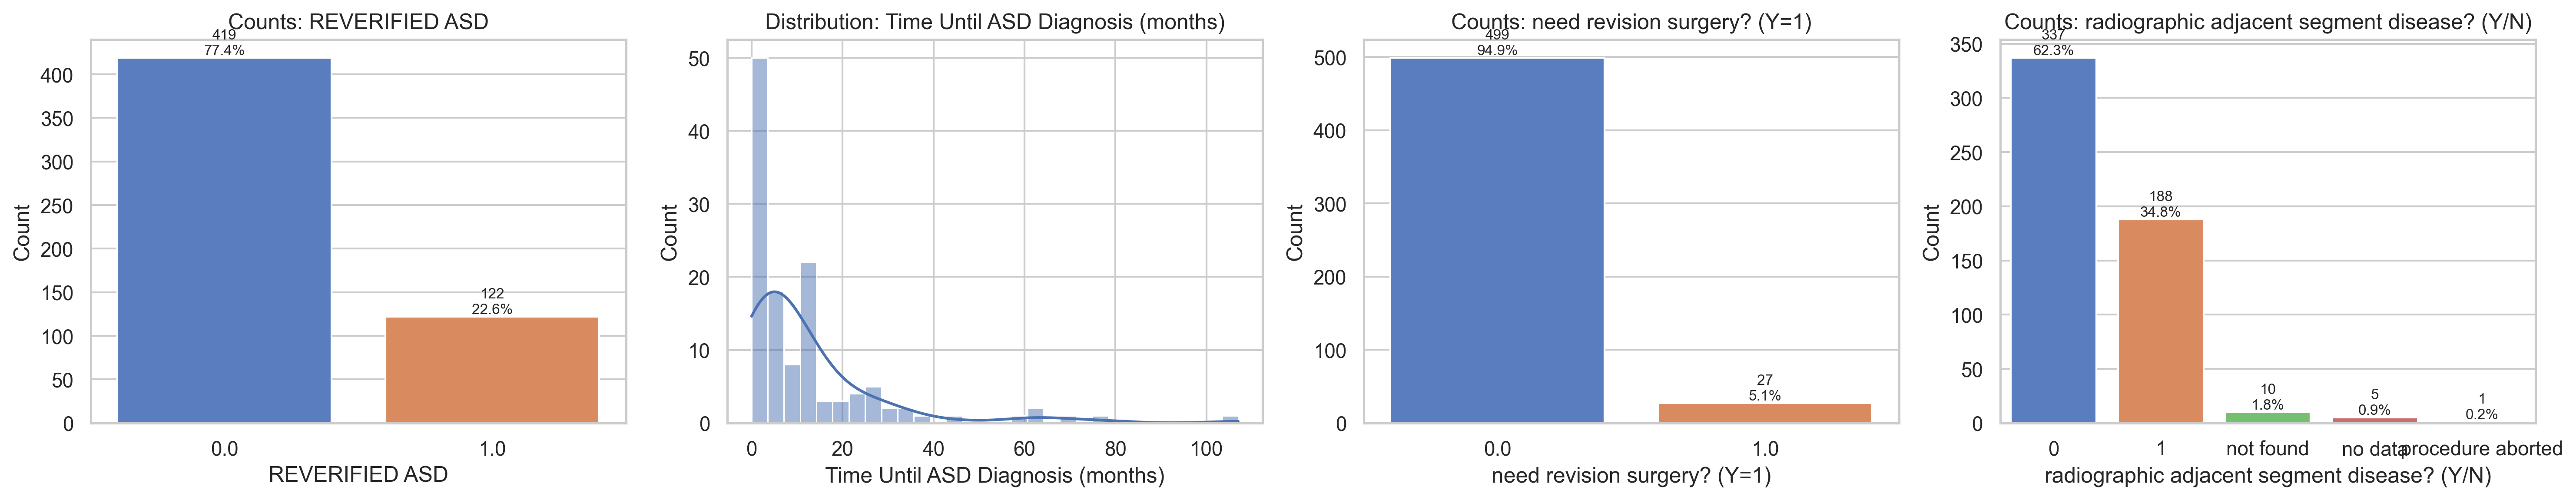

In [4]:
import seaborn as sns
from pandas.api import types as pd_types

import matplotlib.pyplot as plt

# helper to find column with case-insensitive / partial matching
def find_col(df, name):
    name_l = name.lower()
    # exact lower match
    for c in df.columns:
        if c.lower() == name_l:
            return c
    # substring match
    for c in df.columns:
        if name_l in c.lower() or c.lower() in name_l:
            return c
    return None

# desired columns (use existing notebook variables where available)
cols_wanted = [
    "REVERIFIED ASD",                    # user: 'Reverified ASD'
    time_col,                            # 'Time Until ASD Diagnosis (months)' (variable from notebook)
    "need revision surgery? (Y=1)",      # user-provided name
    "radiographic adjacent segment disease? (Y/N)"
]

# resolve to actual df columns, skip missing
cols = []
for nm in cols_wanted:
    c = find_col(df, nm)
    if c is None:
        print(f"Column not found (skipping): {nm}")
    else:
        cols.append(c)

if not cols:
    raise RuntimeError("No plotting columns found in df.")

sns.set(style="whitegrid")

n = len(cols)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), dpi=300, squeeze=False)
axes = axes.flatten()

for ax, col in zip(axes, cols):
    series = df[col].dropna()
    # decide continuous vs categorical/binary
    is_numeric = pd_types.is_numeric_dtype(series.dtype)
    unique_vals = series.nunique(dropna=True)
    if is_numeric and unique_vals > 10:
        # distribution for continuous
        sns.histplot(series.astype(float), kde=True, bins=30, ax=ax, color="C0")
        ax.set_title(f"Distribution: {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
    else:
        # histogram / countplot for categorical / binary
        order = series.value_counts(dropna=True).index
        sns.countplot(x=series, order=order, ax=ax, palette="muted")
        ax.set_title(f"Counts: {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        # annotate counts / percentages
        totals = len(series)
        for p in ax.patches:
            height = p.get_height()
            if height == 0:
                continue
            pct = 100 * height / totals
            ax.annotate(f"{int(height)}\n{pct:.1f}%", (p.get_x() + p.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd


# 2. Clean column names a bit
df.columns = (
    df.columns
      .str.strip()
      .str.replace("\n", " ", regex=False)
)

df.columns



Index(['Date of Surgery', 'Sex', 'Age', 'LLIF?', 'Case/Type of Surgery',
       'Perc screws?', 'Open', 'Open Check V2', 'Standalone XLIF Check',
       'Retroperitoneal Approach (LLIF ± ALIF)',
       ...
       'alif_text', 'dx_adjacent_segment', 'dx_spondylolisthesis',
       'dx_spondylosis', 'dx_stenosis', 'dx_scoliosis', 'dx_flat_back',
       'dx_sagittal_imbalance', 'dx_post_laminectomy', 'dx_deformity'],
      dtype='object', length=116)

In [6]:
target = "Time Until ASD Diagnosis (months)"

# Keep only rows where the target is known (patients who actually developed ASD)
asd_df = df[df[target].notna()].copy()
asd_df.shape


(125, 116)

In [7]:
import pandas as pd
import numpy as np

from sksurv.util import Surv
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from numpy.linalg import LinAlgError

import torch
import torchtuples as tt
from pycox.models import CoxPH as CoxPH_NN

# ---------------------------
# 1. Define columns & labels
# ---------------------------

event_col = "REVERIFIED ASD"
time_asd_col = "Time Until ASD Diagnosis (months)"
time_no_asd_col = "Time Without_ASD (months)"   # used ONLY for label, not as feature

# df is assumed to be your cleaned dataframe (e.g. df_lace or df_clean)

df_surv = df.copy()

# event: 1 if ASD, else 0
df_surv[event_col] = df_surv[event_col].fillna(0).astype(int)

# time: ASD time if event==1, otherwise Time Without_ASD
df_surv["time_surv"] = np.where(
    df_surv[event_col] == 1,
    df_surv[time_asd_col],
    df_surv[time_no_asd_col],
)

# Drop rows with missing survival time
df_surv = df_surv.dropna(subset=["time_surv"])

print("Full cohort survival rows:", df_surv.shape[0])
print("Events (ASD):", int(df_surv[event_col].sum()))
print("Non-events:", int((df_surv[event_col] == 0).sum()))

# ---------------------------------
# 2. Feature preprocessing
# ---------------------------------

X = df_surv[clean_feature_cols].copy()

# 2a. Coerce numeric-like columns
numeric_like_cols = [
    "BMI",
    "ALIF Count",
    "Lateral Count",
    "Average PI",
    "PI-LL angle mismatch",
    "ABS PI-LL angle mismatch",
    "Post-op SS",
    "post PI",
    "post PT",
    "post LL",
    "post SVA",
    "length of hospital stay (d)",
]

for col in numeric_like_cols:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

# 2b. One-hot encode categorical columns
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
print("Categorical feature columns:", cat_cols)

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Simple imputation: fill remaining NaNs
X_encoded = X_encoded.fillna(0)

# Targets
durations_all = df_surv["time_surv"].astype(float).values
events_all = df_surv[event_col].astype(bool).values

print("Final feature matrix shape:", X_encoded.shape)

# ---------------------------------
# 3. Cross-validated classical survival models
# ---------------------------------

# Define models (we'll re-instantiate them inside each fold)
def build_models():
    return {
        "coxph": CoxPHSurvivalAnalysis(alpha=1.0),
        "rsf": RandomSurvivalForest(
            n_estimators=300,
            min_samples_split=10,
            min_samples_leaf=10,
            n_jobs=-1,
            random_state=42,
        ),
        "gbsa": GradientBoostingSurvivalAnalysis(
            learning_rate=0.05,
            max_depth=3,
            n_estimators=300,
            random_state=42,
        ),
    }

n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

cv_results = {name: [] for name in build_models().keys()}
cv_results_deepsurv = []

X_values = X_encoded.values

fold_idx = 1

for train_idx, test_idx in skf.split(X_values, events_all):
    print(f"\n===== Fold {fold_idx}/{n_splits} =====")
    fold_idx += 1

    X_train = X_values[train_idx]
    X_test = X_values[test_idx]
    durations_train = durations_all[train_idx]
    durations_test = durations_all[test_idx]
    events_train = events_all[train_idx]
    events_test = events_all[test_idx]

    # Build sksurv Surv objects
    y_train = Surv.from_arrays(event=events_train, time=durations_train)
    y_test = Surv.from_arrays(event=events_test, time=durations_test)

    # ------------------
    # Classical models
    # ------------------
    models = build_models()

    for name, model in models.items():
        try:
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            ci = concordance_index_censored(
                events_test,
                durations_test,
                pred
            )[0]
            cv_results[name].append(ci)
            print(f"{name} C-index (fold): {ci:.3f}")
        except LinAlgError:
            print(f"Skipping {name} in this fold: singular matrix.")
            cv_results[name].append(np.nan)


# ---------------------------------
# 4. Summarize CV results
# ---------------------------------

print("\n===== Cross-validated C-index (mean ± SD) =====")
for name, scores in cv_results.items():
    scores_arr = np.array(scores, dtype=float)
    mean_ci = np.nanmean(scores_arr)
    std_ci = np.nanstd(scores_arr)
    print(f"{name}: {mean_ci:.3f} ± {std_ci:.3f} over {n_splits} folds")



Full cohort survival rows: 546
Events (ASD): 122
Non-events: 424
Categorical feature columns: ['Case/Type of Surgery', 'osteotomy level', 'ACR level']
Final feature matrix shape: (546, 389)

===== Fold 1/10 =====
coxph C-index (fold): 0.461
rsf C-index (fold): 0.434
gbsa C-index (fold): 0.466

===== Fold 2/10 =====
coxph C-index (fold): 0.435
rsf C-index (fold): 0.489
gbsa C-index (fold): 0.511

===== Fold 3/10 =====
coxph C-index (fold): 0.515
rsf C-index (fold): 0.615
gbsa C-index (fold): 0.542

===== Fold 4/10 =====
coxph C-index (fold): 0.520
rsf C-index (fold): 0.666
gbsa C-index (fold): 0.602

===== Fold 5/10 =====
coxph C-index (fold): 0.564
rsf C-index (fold): 0.607
gbsa C-index (fold): 0.552

===== Fold 6/10 =====
coxph C-index (fold): 0.454
rsf C-index (fold): 0.584
gbsa C-index (fold): 0.541

===== Fold 7/10 =====
coxph C-index (fold): 0.614
rsf C-index (fold): 0.518
gbsa C-index (fold): 0.505

===== Fold 8/10 =====
coxph C-index (fold): 0.790
rsf C-index (fold): 0.846
gbsa 

In [8]:
df

,Date of Surgery,Sex,Age,LLIF?,Case/Type of Surgery,Perc screws?,Open,Open Check V2,Standalone XLIF Check,Retroperitoneal Approach (LLIF ± ALIF),...,alif_text,dx_adjacent_segment,dx_spondylolisthesis,dx_spondylosis,dx_stenosis,dx_scoliosis,dx_flat_back,dx_sagittal_imbalance,dx_post_laminectomy,dx_deformity
0,1/28/2014,0,63,1.0,llif l4-l5 w/ perc screws,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,1/28/2014,0,55,1.0,llif l2-l5,0,0,0,1,1,...,0,0,0,1,0,0,0,0,0,0
2,1/29/2014,1,74,1.0,llif l2-l3,0,0,0,1,1,...,0,1,0,0,0,0,0,0,0,0
3,2/10/2014,1,55,1.0,llif l3-l5,0,0,0,1,1,...,0,0,0,1,0,1,0,0,0,1
4,2/24/2014,1,67,1.0,llif l4-l5,0,0,0,1,1,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,7/27/2022,1,31,NaN,l3-4 llif,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
542,8/22/2022,0,60,NaN,l2-5 llif,0,1,1,0,0,...,0,0,0,0,0,1,0,0,0,1
543,8/23/2022,1,66,NaN,l2-4 llif,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
544,8/31/2022,1,62,NaN,l2-4 llif,0,0,0,1,1,...,0,0,0,0,1,1,1,0,0,1


In [9]:
import matplotlib.pyplot as plt
df_surv['time_surv']

0      23.0
1      21.0
2      66.0
3      13.0
4       6.0
       ... 
541     0.0
542     6.0
543     5.0
544     9.0
545     6.0
Name: time_surv, Length: 546, dtype: float64

# Chosen model RSF 

Cohort rows: 546 Events: 122
Categorical feature columns: ['Case/Type of Surgery', 'osteotomy level', 'ACR level']
Initial feature matrix shape: (546, 389)
Dropping 319 ultra-rare binary cols.
Shape after dropping ultra-rare columns: (546, 70)
Numeric-like columns for PCA: ['BMI', 'ALIF Count', 'Lateral Count', 'Average PI', 'PI-LL angle mismatch', 'ABS PI-LL angle mismatch', 'Post-op SS', 'post PI', 'post PT', 'post LL', 'post SVA', 'length of hospital stay (d)']
Replaced 12 numeric cols with 3 PCA components.
Final feature matrix shape (X_reduced): (546, 61)
Time grid: [ 0.   2.   3.   6.   8.  12.  18.  28.  53.5]
Calibration horizons: [ 3.  8. 23.]

--- Fold 1 ---
 Fold C-index: 0.5317073170731708
 IBS error: time must be smaller than largest observed time point: 107.0
 Fold IBS: nan

--- Fold 2 ---


c:\Users\shrin\Downloads\neurosynthetic\spine-usf-data\.venv\Lib\site-packages\sksurv\metrics.py:498: RuntimeWarning: invalid value encountered in divide
  true_pos = cumsum_tp / cumsum_tp[-1]


 Fold C-index: 0.5611510791366906
 Fold IBS: 0.1908815961448991

--- Fold 3 ---
 Fold C-index: 0.6636363636363637
 Fold IBS: 0.19666349575586958

--- Fold 4 ---


c:\Users\shrin\Downloads\neurosynthetic\spine-usf-data\.venv\Lib\site-packages\sksurv\metrics.py:498: RuntimeWarning: invalid value encountered in divide
  true_pos = cumsum_tp / cumsum_tp[-1]


 Fold C-index: 0.6788511749347258
 Fold IBS: 0.16934821039084316

--- Fold 5 ---


...

c:\Users\shrin\Downloads\neurosynthetic\spine-usf-data\.venv\Lib\site-packages\sksurv\metrics.py:498: RuntimeWarning: invalid value encountered in divide
  true_pos = cumsum_tp / cumsum_tp[-1]


 Fold C-index: 0.49834983498349833
 Fold IBS: 0.1698125759577747

--- Fold 8 ---


c:\Users\shrin\Downloads\neurosynthetic\spine-usf-data\.venv\Lib\site-packages\sksurv\metrics.py:498: RuntimeWarning: invalid value encountered in divide
  true_pos = cumsum_tp / cumsum_tp[-1]


 Fold C-index: 0.800531914893617
 Fold IBS: 0.19759223310280255

--- Fold 9 ---
 Fold C-index: 0.6199376947040498
 Fold IBS: 0.18562271413981887

--- Fold 10 ---
 Fold C-index: 0.46439628482972134
 Fold IBS: 0.21582385507061053

=== CV SUMMARY ===
Per-fold C-index: [0.5317 0.5612 0.6636 0.6789 0.6453 0.5378 0.4983 0.8005 0.6199 0.4644]
Mean C-index: 0.6001698647328821
Per-fold IBS : [    nan 0.19088 0.19666 0.16935 0.20717 0.21819 0.16981 0.19759 0.18562
 0.21582]
Mean IBS: 0.19456721183710146
No valid time-AUC results to plot.

Calibration (ECE) results:
 Horizon 3.0 mo -> ECE = 0.0452


c:\Users\shrin\Downloads\neurosynthetic\spine-usf-data\.venv\Lib\site-packages\sksurv\metrics.py:498: RuntimeWarning: invalid value encountered in divide
  true_pos = cumsum_tp / cumsum_tp[-1]


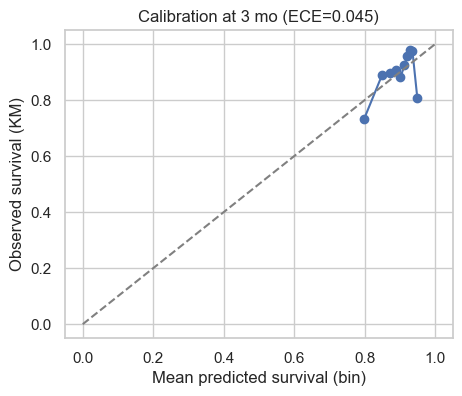

 Horizon 8.0 mo -> ECE = 0.0415


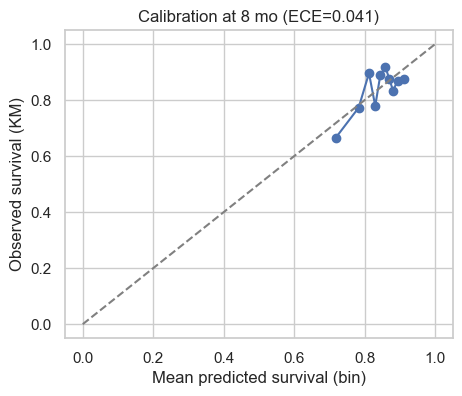

 Horizon 23.0 mo -> ECE = 0.0518


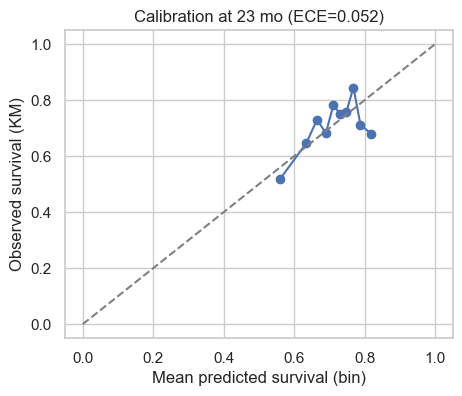


Saved final RSF model to: models/rsf_final_best.pkl


In [13]:
# -----------------------------
# Final pipeline: feature prep -> PCA -> RSF (fixed best params) -> metrics + save + unit test
# -----------------------------
import os
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold

from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored, integrated_brier_score, cumulative_dynamic_auc
from lifelines import KaplanMeierFitter

# -----------------------------
# 0. CONFIG: best RSF params 
# -----------------------------
BEST_RSFPARAMS = {
    "n_estimators": 200,
    "min_samples_split": 4,
    "min_samples_leaf": 12,
    "max_features": "sqrt",
    "n_jobs": -1,
    "random_state": 42,
}

# -----------------------------
# 1. Survival labels & basic checks (assumes df available)
# -----------------------------
event_col = "REVERIFIED ASD"
time_asd_col = "Time Until ASD Diagnosis (months)"
time_no_asd_col = "Time Without_ASD (months)"

df_surv = df.copy()
df_surv[event_col] = df_surv.get(event_col, 0).fillna(0).astype(int)
df_surv["time_surv"] = np.where(
    df_surv[event_col] == 1,
    df_surv.get(time_asd_col),
    df_surv.get(time_no_asd_col),
)
df_surv = df_surv.dropna(subset=["time_surv"])
df_surv["time_surv"] = df_surv["time_surv"].astype(float)

print("Cohort rows:", df_surv.shape[0], "Events:", int(df_surv[event_col].sum()))

# -----------------------------
# 2. Feature construction 
# -----------------------------
# clean_feature_cols must exist (list of features you'd like to start from)
X = df_surv[clean_feature_cols].copy()

numeric_like_cols = [
    "BMI",
    "ALIF Count",
    "Lateral Count",
    "Average PI",
    "PI-LL angle mismatch",
    "ABS PI-LL angle mismatch",
    "Post-op SS",
    "post PI",
    "post PT",
    "post LL",
    "post SVA",
    "length of hospital stay (d)",
]

# coerce numeric-like
for col in numeric_like_cols:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

# one-hot encode categoricals
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
print("Categorical feature columns:", cat_cols)
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# simple imputation
X_encoded = X_encoded.fillna(0.0)

# targets
durations_all = df_surv["time_surv"].astype(float).values
events_all = df_surv[event_col].astype(bool).values

print("Initial feature matrix shape:", X_encoded.shape)

# -----------------------------
# 3. Remove ultra-rare binary features (occurence < 5)
# -----------------------------
binary_like_cols = [c for c in X_encoded.columns if set(np.unique(X_encoded[c])) <= {0,1}]
rare_cols = [c for c in binary_like_cols if X_encoded[c].sum() < 5]
print(f"Dropping {len(rare_cols)} ultra-rare binary cols.")
X_reduced = X_encoded.drop(columns=rare_cols)
print("Shape after dropping ultra-rare columns:", X_reduced.shape)

# -----------------------------
# 4. PCA compression 
# -----------------------------
numeric_present = [c for c in numeric_like_cols if c in X_reduced.columns]
print("Numeric-like columns for PCA:", numeric_present)

if len(numeric_present) >= 2:
    scaler_for_pca = StandardScaler()
    numeric_data = scaler_for_pca.fit_transform(X_reduced[numeric_present].values)
    n_pca = min(3, numeric_data.shape[1])
    pca = PCA(n_components=n_pca, random_state=42)
    pcs = pca.fit_transform(numeric_data)
    pca_cols = [f"pca_num_{i+1}" for i in range(n_pca)]
    df_pcs = pd.DataFrame(pcs, columns=pca_cols, index=X_reduced.index)
    X_reduced = pd.concat([X_reduced.drop(columns=numeric_present), df_pcs], axis=1)
    print(f"Replaced {len(numeric_present)} numeric cols with {n_pca} PCA components.")
else:
    print("Skipping PCA (not enough numeric-like columns).")

print("Final feature matrix shape (X_reduced):", X_reduced.shape)

# -----------------------------
# 5. Prepare CV and time grid
# -----------------------------
X_vals = X_reduced.values
events = events_all
times = durations_all

n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# time grid for IBS and time-AUC (use quantiles)
time_grid = np.percentile(times, np.linspace(10, 90, 9))  # e.g. 9 points
calib_times = list(np.percentile(times, [25, 50, 75]))    # calibration horizons

print("Time grid:", np.round(time_grid,2))
print("Calibration horizons:", np.round(calib_times,2))

# -----------------------------
# 6. CV: Fit RSF with fixed params, compute metrics per fold
# -----------------------------
rsf_fold_cis = []
rsf_fold_ibs = []
time_auc_folds = []
fold_predictions = []   # for calibration: store (test_idx, S_test_at_calib_times, t_te, e_te)

fold_id = 1
for train_idx, test_idx in skf.split(X_vals, events.astype(int)):
    print(f"\n--- Fold {fold_id} ---")
    X_tr, X_te = X_vals[train_idx], X_vals[test_idx]
    e_tr, e_te = events[train_idx], events[test_idx]
    t_tr, t_te = times[train_idx], times[test_idx]

    # skip fold if test has no events
    if int(e_te.sum()) == 0:
        print(" Skipping fold (no events in test).")
        rsf_fold_cis.append(np.nan)
        rsf_fold_ibs.append(np.nan)
        time_auc_folds.append((np.nan, np.nan))
        fold_predictions.append((None, None, (t_te, e_te)))
        fold_id += 1
        continue

    # structured arrays
    y_tr_struct = Surv.from_arrays(event=e_tr, time=t_tr)
    y_te_struct = Surv.from_arrays(event=e_te, time=t_te)

    # train RSF with best params
    rsf = RandomSurvivalForest(**BEST_RSFPARAMS)
    rsf.fit(X_tr, y_tr_struct)

    # risk predictions (for C-index and time-AUC)
    preds_risk = rsf.predict(X_te)
    try:
        ci = concordance_index_censored(e_te, t_te, preds_risk)[0]
    except Exception:
        ci = np.nan
    rsf_fold_cis.append(ci)
    print(" Fold C-index:", ci)

    # survival functions on test (list of step funcs) -> evaluate to array at time_grid
    surv_funcs_test = rsf.predict_survival_function(X_te, return_array=False)
    def eval_surv(surv_funcs, times_eval):
        arr = np.zeros((len(surv_funcs), len(times_eval)))
        for i, fn in enumerate(surv_funcs):
            xs = np.asarray(fn.x)
            ys = np.asarray(fn.y)
            arr[i,:] = np.interp(times_eval, xs, ys, left=1.0, right=ys[-1])
        return arr

    S_te = eval_surv(surv_funcs_test, time_grid)

    # IBS (integrated brier score) using sklearn-survival helper
    try:
        ibs = integrated_brier_score(y_tr_struct, y_te_struct, S_te, times=time_grid)
    except Exception as ex:
        print(" IBS error:", ex)
        ibs = np.nan
    rsf_fold_ibs.append(ibs)
    print(" Fold IBS:", ibs)

    # time-dependent AUC (cumulative_dynamic_auc) using risk scores
    try:
        times_auc, aucs = cumulative_dynamic_auc(y_tr_struct, y_te_struct, preds_risk, time_grid)
        time_auc_folds.append((times_auc, aucs))
    except Exception as ex:
        print(" time-AUC error:", ex)
        time_auc_folds.append((np.nan, np.nan))

    # store survival predictions at calibration horizons for calibration pooling
    S_test_calib = eval_surv(surv_funcs_test, calib_times)  # shape (n_test, n_calib_times)
    fold_predictions.append((test_idx, S_test_calib, (t_te, e_te)))

    fold_id += 1

# -----------------------------
# 7. Summarize CV metrics
# -----------------------------
print("\n=== CV SUMMARY ===")
print("Per-fold C-index:", np.round(rsf_fold_cis,4))
print("Mean C-index:", np.nanmean(rsf_fold_cis))
print("Per-fold IBS :", np.round(rsf_fold_ibs,5))
print("Mean IBS:", np.nanmean(rsf_fold_ibs))

# plot aggregated time-dependent AUC (mean ± std)
valid = [f for f in time_auc_folds if isinstance(f[1], (np.ndarray, list))]
if len(valid)>0:
    auc_stack = np.vstack([f[1] for f in valid])
    mean_auc = np.nanmean(auc_stack, axis=0)
    std_auc = np.nanstd(auc_stack, axis=0)
    plt.figure(figsize=(7,4))
    plt.plot(time_grid, mean_auc, lw=2, label="Mean time-dependent AUC")
    plt.fill_between(time_grid, np.maximum(0, mean_auc-std_auc), np.minimum(1, mean_auc+std_auc), alpha=0.2)
    plt.xlabel("Time (months)")
    plt.ylabel("AUC")
    plt.title("Time-dependent AUC (mean ± std) across CV folds")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("No valid time-AUC results to plot.")

# -----------------------------
# 8. Calibration (ECE) at chosen horizons
# -----------------------------
def compute_ece_pooled(fold_preds, horizon_idx, n_bins=10):
    # pool predictions across folds
    rows = []
    for test_idx, S_test_calib, (t_te, e_te) in fold_preds:
        if S_test_calib is None:
            continue
        preds = S_test_calib[:, horizon_idx]
        rows.append(pd.DataFrame({"pred": preds, "time": t_te, "event": e_te}))
    if len(rows)==0:
        return None
    dfp = pd.concat(rows, ignore_index=True)
    # create bins by predicted survival probability
    dfp["bin"] = pd.qcut(dfp["pred"].rank(method="first"), q=n_bins, labels=False, duplicates="drop")
    bin_stats = []
    for b in sorted(dfp["bin"].dropna().unique()):
        sub = dfp[dfp["bin"]==b]
        if len(sub)==0:
            continue
        km = KaplanMeierFitter()
        try:
            km.fit(sub["time"], event_observed=sub["event"])
            obs = km.predict(calib_times[horizon_idx])
        except Exception:
            obs = np.nan
        pred_mean = sub["pred"].mean()
        bin_stats.append({"bin":b, "pred_mean": pred_mean, "obs": obs, "n": len(sub)})
    if len(bin_stats)==0:
        return None
    stats_df = pd.DataFrame(bin_stats)
    counts = stats_df["n"].values.astype(float)
    preds_arr = stats_df["pred_mean"].values.astype(float)
    obs_arr = stats_df["obs"].values.astype(float)
    ece = np.nansum((counts/np.sum(counts)) * np.abs(preds_arr - obs_arr))
    return {"ece": float(ece), "df": stats_df}

print("\nCalibration (ECE) results:")
calib_results = {}
for i, ct in enumerate(calib_times):
    res = compute_ece_pooled(fold_predictions, i, n_bins=10)
    calib_results[ct] = res
    if res is None:
        print(f" Horizon {ct:.1f}: insufficient data")
        continue
    print(f" Horizon {ct:.1f} mo -> ECE = {res['ece']:.4f}")
    # plot calibration
    dfplot = res["df"]
    plt.figure(figsize=(5,4))
    plt.plot(dfplot["pred_mean"], dfplot["obs"], marker="o", linestyle="-")
    plt.plot([0,1],[0,1], linestyle="--", color="gray")
    plt.xlabel("Mean predicted survival (bin)")
    plt.ylabel("Observed survival (KM)")
    plt.title(f"Calibration at {ct:.0f} mo (ECE={res['ece']:.3f})")
    plt.grid(True)
    plt.show()

# -----------------------------
# 9. Fit final RSF on full dataset and save model bundle
# -----------------------------
y_full = Surv.from_arrays(event=events, time=times)
rsf_final = RandomSurvivalForest(**BEST_RSFPARAMS)
rsf_final.fit(X_vals, y_full)

os.makedirs("models", exist_ok=True)
model_path = "models/rsf_final_best.pkl"
with open(model_path, "wb") as f:
    pickle.dump({"model": rsf_final, "feature_columns": X_reduced.columns.tolist(), "params": BEST_RSFPARAMS}, f)
print("\nSaved final RSF model to:", model_path)

In [14]:
# Robust unit test for RSF survival predictions (replacement for failing assertion)
import pickle
import numpy as np
import pandas as pd
import os

model_path = "models/rsf_final_best.pkl"
assert os.path.exists(model_path), f"Model file not found: {model_path}"

with open(model_path, "rb") as f:
    bundle = pickle.load(f)

model = bundle["model"]
cols = bundle["feature_columns"]

# Build synthetic sample (median of training features if available)
FEATURE_MATRIX = globals().get('X_reduced', globals().get('X_encoded', None))
if FEATURE_MATRIX is not None:
    try:
        x0 = FEATURE_MATRIX.median(axis=0).to_numpy().reshape(1, -1)
        # If one-hot encoded columns are fractional due to median, round the categorical ones:
        # set any column whose unique values are only 0/1 in training to nearest {0,1}
        for i, colname in enumerate(FEATURE_MATRIX.columns):
            unique_vals = FEATURE_MATRIX[colname].dropna().unique()
            if set(np.unique(unique_vals)).issubset({0,1}):
                x0[0, i] = 1.0 if x0[0, i] >= 0.5 else 0.0
    except Exception:
        x0 = np.zeros((1, len(cols)))
else:
    # fallback: zeros, but must match number of model columns
    x0 = np.zeros((1, len(cols)))

# Try both return array and return functions
surv_out = None
# Preferred: ask for array
try:
    surv_arr = model.predict_survival_function(x0, return_array=True)
    # model may return a 2D array or list; normalize to numpy array
    if isinstance(surv_arr, (list, tuple)):
        surv_arr = np.asarray(surv_arr)
    surv_out = np.array(surv_arr)  # shape (n_samples, n_times)
    times_grid = None
    # If shape is (n_samples, n_times), we'll create a default candidate time grid 0..max training time (approx)
except TypeError:
    # some implementations don't accept return_array arg or expect different signature
    try:
        funcs = model.predict_survival_function(x0, return_array=False)
        # funcs might be a single function or list of functions
        if not isinstance(funcs, (list, tuple)):
            funcs = [funcs]
        # build a time-grid by unioning xs from functions
        xs_union = np.unique(np.concatenate([np.asarray(f.x) for f in funcs]))
        times_grid = np.sort(xs_union)
        surv_out = np.zeros((len(funcs), len(times_grid)))
        for i, f in enumerate(funcs):
            surv_out[i, :] = np.interp(times_grid, np.asarray(f.x), np.asarray(f.y), left=1.0, right=f.y[-1])
    except Exception as ex:
        raise AssertionError(f"predict_survival_function failed entirely: {ex}")

# Now surv_out should be a numpy array shape (n_samples, n_times)
if surv_out is None:
    raise AssertionError("Could not obtain survival array from model.")

# Basic shape checks
n_samples, n_times = surv_out.shape
assert n_samples == 1, f"Expected single sample, got {n_samples}"

# Evaluate monotonicity (non-increasing) and bounds for the single sample
vals = surv_out[0, :]

# Monotonic non-increasing check (allow tiny numerical tolerance)
if not np.all(np.diff(vals) <= 1e-6):
    # print first few violations for debugging
    diffs = np.diff(vals)
    viol = np.where(diffs > 1e-6)[0]
    raise AssertionError(f"Survival function not non-increasing: first violation index {viol[0]} (diff={diffs[viol[0]]})")

# Bound check
if np.any(vals < -1e-6) or np.any(vals > 1.0 + 1e-6):
    raise AssertionError("Survival probabilities out of [0,1] bounds")

# Risk score check (must be finite)
risk = model.predict(x0)
if not np.all(np.isfinite(risk)):
    raise AssertionError("Risk score contains non-finite values")

print("Unit test PASSED.")
print("Risk score:", risk)
# Print a small summary of the survival function
if 'times_grid' in locals() and times_grid is not None:
    print("Survival evaluated at times (first 6):", list(zip(times_grid[:6], vals[:6])))
else:
    print("Survival values (first 6):", vals[:6])


Unit test PASSED.
Risk score: [10.43896567]
Survival values (first 6): [0.99425712 0.97209351 0.945513   0.90968729 0.90248449 0.8912969 ]


### GBSA with Dimensionality Reduction (slightly better C-index but worse in IBS and ECE analysis)

GBSA grid size: 18
Cohort rows: 546 Events: 122
Categorical feature columns: ['Case/Type of Surgery', 'osteotomy level', 'ACR level']
Initial feature matrix shape: (546, 389)
Dropping 319 ultra-rare binary cols.
Shape after dropping ultra-rare columns: (546, 70)
Numeric-like columns for PCA: ['BMI', 'ALIF Count', 'Lateral Count', 'Average PI', 'PI-LL angle mismatch', 'ABS PI-LL angle mismatch', 'Post-op SS', 'post PI', 'post PT', 'post LL', 'post SVA', 'length of hospital stay (d)']
Replaced 12 numeric cols with 3 PCA components.
Final feature matrix shape (X_reduced): (546, 61)
Time grid: [ 0.   2.   3.   6.   8.  12.  18.  28.  53.5]
Calibration horizons: [ 3.  8. 23.]

[1/18] Evaluating {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 100} ...
 -> mean CI = 0.5912 ± 0.0836, mean IBS = 0.1975

[2/18] Evaluating {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 300} ...
 -> mean CI = 0.5917 ± 0.0978, mean IBS = 0.1970

[3/18] Evaluating {'learning_rate': 0.01, 'max_depth'

,learning_rate,n_estimators,max_depth,mean_ci,std_ci,mean_ibs
0,0.10,100,4,0.604836,0.108709,0.200137
1,0.10,300,2,0.604758,0.111798,0.192806
2,0.10,300,3,0.602789,0.115149,0.206855
3,0.10,300,4,0.602001,0.111698,0.210859
4,0.05,300,3,0.597068,0.109049,0.199406



Selected best GBSA config: {'learning_rate': 0.1, 'n_estimators': 100, 'max_depth': 4}  mean CI=0.6048 ± 0.1087

Per-fold C-index (best config): [0.5439 0.5036 0.6273 0.7389 0.6485 0.4514 0.6271 0.8032 0.6386 0.4659]
Mean CI: 0.6048359059278021 Std CI: 0.10870876793020536
Per-fold IBS: [    nan 0.20064 0.19948 0.14648 0.19385 0.25979 0.14741 0.17624 0.20032
 0.27703]
Mean IBS: 0.2001371853997348
No valid fold AUCs to plot for best config.

Calibration (ECE) for best GBSA config:
 Horizon 3.0 months -> ECE = 0.0374


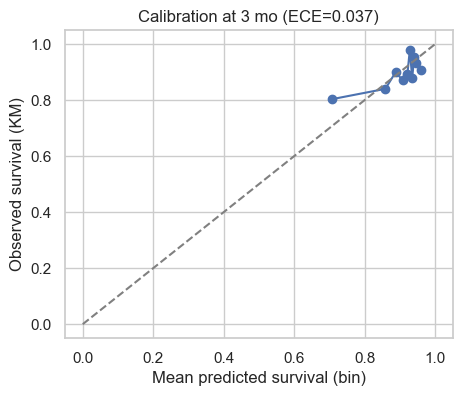

 Horizon 8.0 months -> ECE = 0.0530


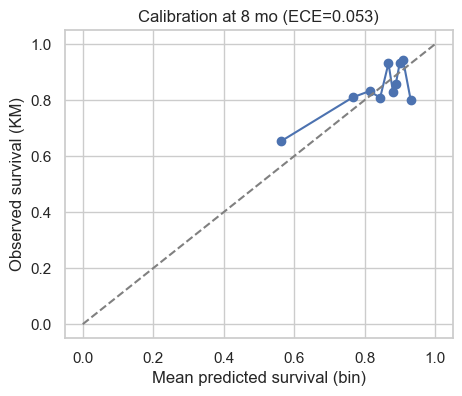

 Horizon 23.0 months -> ECE = 0.0845


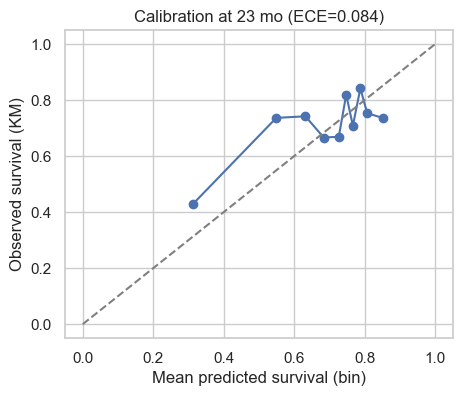


Training final GBSA on full dataset (best config)...
Saved final GBSA model to: models/gbsa_final_best.pkl
Wrote unit test -> tests/test_gbsa_model_smoke.py
Run with: pytest -q tests/test_gbsa_model_smoke.py


In [15]:
# -----------------------------
# GBSA pipeline: feature prep -> PCA -> GBSA (grid search) -> metrics + save + unit test
# -----------------------------
import os
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, ParameterGrid

from sksurv.util import Surv
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored, integrated_brier_score, cumulative_dynamic_auc
from lifelines import KaplanMeierFitter

# -----------------------------
# 0. Grid for GBSA (small/modest grid; adjust if you want wider search)
# -----------------------------
param_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 300],
    "max_depth": [2, 3, 4],
    # subsample not supported in some GBSA impls — comment out if error
    # "subsample": [1.0, 0.8],
}
grid = list(ParameterGrid(param_grid))
print("GBSA grid size:", len(grid))

# -----------------------------
# 1. Survival labels & basic checks (assumes df available)
# -----------------------------
event_col = "REVERIFIED ASD"
time_asd_col = "Time Until ASD Diagnosis (months)"
time_no_asd_col = "Time Without_ASD (months)"

df_surv = df.copy()
df_surv[event_col] = df_surv.get(event_col, 0).fillna(0).astype(int)
df_surv["time_surv"] = np.where(
    df_surv[event_col] == 1,
    df_surv.get(time_asd_col),
    df_surv.get(time_no_asd_col),
)
df_surv = df_surv.dropna(subset=["time_surv"])
df_surv["time_surv"] = df_surv["time_surv"].astype(float)

print("Cohort rows:", df_surv.shape[0], "Events:", int(df_surv[event_col].sum()))

# -----------------------------
# 2. Feature construction (same as before)
# -----------------------------
X = df_surv[clean_feature_cols].copy()

numeric_like_cols = [
    "BMI",
    "ALIF Count",
    "Lateral Count",
    "Average PI",
    "PI-LL angle mismatch",
    "ABS PI-LL angle mismatch",
    "Post-op SS",
    "post PI",
    "post PT",
    "post LL",
    "post SVA",
    "length of hospital stay (d)",
]

# coerce numeric-like
for col in numeric_like_cols:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

# one-hot encode categoricals
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
print("Categorical feature columns:", cat_cols)
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# simple imputation
X_encoded = X_encoded.fillna(0.0)

# targets
durations_all = df_surv["time_surv"].astype(float).values
events_all = df_surv[event_col].astype(bool).values

print("Initial feature matrix shape:", X_encoded.shape)

# -----------------------------
# 3. Remove ultra-rare binary features (occurence < 5)
# -----------------------------
binary_like_cols = [c for c in X_encoded.columns if set(np.unique(X_encoded[c])) <= {0,1}]
rare_cols = [c for c in binary_like_cols if X_encoded[c].sum() < 5]
print(f"Dropping {len(rare_cols)} ultra-rare binary cols.")
X_reduced = X_encoded.drop(columns=rare_cols)
print("Shape after dropping ultra-rare columns:", X_reduced.shape)

# -----------------------------
# 4. PCA compression 
# -----------------------------
numeric_present = [c for c in numeric_like_cols if c in X_reduced.columns]
print("Numeric-like columns for PCA:", numeric_present)

if len(numeric_present) >= 2:
    scaler_for_pca = StandardScaler()
    numeric_data = scaler_for_pca.fit_transform(X_reduced[numeric_present].values)
    n_pca = min(3, numeric_data.shape[1])
    pca = PCA(n_components=n_pca, random_state=42)
    pcs = pca.fit_transform(numeric_data)
    pca_cols = [f"pca_num_{i+1}" for i in range(n_pca)]
    df_pcs = pd.DataFrame(pcs, columns=pca_cols, index=X_reduced.index)
    X_reduced = pd.concat([X_reduced.drop(columns=numeric_present), df_pcs], axis=1)
    print(f"Replaced {len(numeric_present)} numeric cols with {n_pca} PCA components.")
else:
    print("Skipping PCA (not enough numeric-like columns).")

print("Final feature matrix shape (X_reduced):", X_reduced.shape)

# -----------------------------
# 5. CV settings & time grid
# -----------------------------
X_vals = X_reduced.values
events = events_all
times = durations_all

n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

time_grid = np.percentile(times, np.linspace(10, 90, 9))
calib_times = list(np.percentile(times, [25, 50, 75]))
print("Time grid:", np.round(time_grid,2))
print("Calibration horizons:", np.round(calib_times,2))

# -----------------------------
# 6. Grid search (manual) using CV — evaluate by mean CV C-index
# -----------------------------
def eval_config_on_cv(cfg):
    fold_cis = []
    fold_ibs = []
    fold_time_aucs = []   # store arrays
    fold_surv_preds_for_calib = []
    for train_idx, test_idx in skf.split(X_vals, events.astype(int)):
        X_tr, X_te = X_vals[train_idx], X_vals[test_idx]
        e_tr, e_te = events[train_idx], events[test_idx]
        t_tr, t_te = times[train_idx], times[test_idx]

        # skip fold if no events in test (can't compute CI)
        if int(e_te.sum()) == 0:
            fold_cis.append(np.nan)
            fold_ibs.append(np.nan)
            fold_time_aucs.append((np.nan, np.nan))
            fold_surv_preds_for_calib.append((None, None, (t_te, e_te)))
            continue

        y_tr_struct = Surv.from_arrays(event=e_tr, time=t_tr)
        y_te_struct = Surv.from_arrays(event=e_te, time=t_te)

        # instantiate GBSA with cfg
        gbsa = GradientBoostingSurvivalAnalysis(
            learning_rate=cfg["learning_rate"],
            n_estimators=int(cfg["n_estimators"]),
            max_depth=int(cfg["max_depth"]),
            random_state=42
        )

        try:
            gbsa.fit(X_tr, y_tr_struct)
        except Exception as ex:
            # if a config fails to fit, return NaNs for this fold
            fold_cis.append(np.nan)
            fold_ibs.append(np.nan)
            fold_time_aucs.append((np.nan, np.nan))
            fold_surv_preds_for_calib.append((None, None, (t_te, e_te)))
            continue

        # risk predictions
        try:
            preds_risk = gbsa.predict(X_te)
            ci = concordance_index_censored(e_te, t_te, preds_risk)[0]
        except Exception:
            ci = np.nan
        fold_cis.append(ci)

        # survival functions on test -> evaluate at time_grid
        # handle various possible outputs robustly
        try:
            surv_funcs_test = gbsa.predict_survival_function(X_te, return_array=False)
        except TypeError:
            surv_funcs_test = gbsa.predict_survival_function(X_te)

        def eval_surv(surv_funcs, times_eval):
            arr = np.zeros((len(surv_funcs), len(times_eval)))
            for i, fn in enumerate(surv_funcs):
                xs = np.asarray(fn.x)
                ys = np.asarray(fn.y)
                arr[i,:] = np.interp(times_eval, xs, ys, left=1.0, right=ys[-1])
            return arr

        try:
            S_te = eval_surv(surv_funcs_test, time_grid)
        except Exception:
            S_te = np.full((len(X_te), len(time_grid)), np.nan)

        # IBS
        try:
            ibs = integrated_brier_score(y_tr_struct, y_te_struct, S_te, times=time_grid)
        except Exception:
            ibs = np.nan
        fold_ibs.append(ibs)

        # time-dependent AUC
        try:
            times_auc, aucs = cumulative_dynamic_auc(y_tr_struct, y_te_struct, preds_risk, time_grid)
            fold_time_aucs.append((times_auc, aucs))
        except Exception:
            fold_time_aucs.append((np.nan, np.nan))

        # save calib preds at calib_times
        try:
            S_test_calib = eval_surv(surv_funcs_test, calib_times)
        except Exception:
            S_test_calib = None
        fold_surv_preds_for_calib.append((test_idx, S_test_calib, (t_te, e_te)))

    # summarize
    mean_ci = np.nanmean(fold_cis)
    std_ci = np.nanstd(fold_cis)
    mean_ibs = np.nanmean(fold_ibs)
    return {
        "cfg": cfg,
        "mean_ci": mean_ci,
        "std_ci": std_ci,
        "mean_ibs": mean_ibs,
        "fold_cis": fold_cis,
        "fold_ibs": fold_ibs,
        "fold_time_aucs": fold_time_aucs,
        "fold_calib_preds": fold_surv_preds_for_calib
    }

# iterate grid and evaluate (this can be slow; pick smaller grid if needed)
results = []
t_start = time.time()
for i, cfg in enumerate(grid, 1):
    print(f"\n[{i}/{len(grid)}] Evaluating {cfg} ...")
    res = eval_config_on_cv(cfg)
    results.append(res)
    print(f" -> mean CI = {res['mean_ci']:.4f} ± {res['std_ci']:.4f}, mean IBS = {res['mean_ibs']:.4f}")

t_total = time.time() - t_start
print(f"\nGrid evaluation done in {t_total:.1f}s")

# -----------------------------
# 7. Select best config (by mean CV C-index)
# -----------------------------
results_df = pd.DataFrame([{
    "learning_rate": r["cfg"]["learning_rate"],
    "n_estimators": int(r["cfg"]["n_estimators"]),
    "max_depth": int(r["cfg"]["max_depth"]),
    "mean_ci": r["mean_ci"],
    "std_ci": r["std_ci"],
    "mean_ibs": r["mean_ibs"]
} for r in results]).sort_values("mean_ci", ascending=False).reset_index(drop=True)

print("\nTop GBSA configs by mean CV C-index:")
display(results_df.head(5))

best_row = results_df.iloc[0].to_dict()
best_cfg = {"learning_rate": best_row["learning_rate"], "n_estimators": int(best_row["n_estimators"]), "max_depth": int(best_row["max_depth"])}
print("\nSelected best GBSA config:", best_cfg, f" mean CI={best_row['mean_ci']:.4f} ± {best_row['std_ci']:.4f}")

# find corresponding result object for detailed folds (to reuse calib preds)
best_res = results[[i for i,r in enumerate(results) if r["cfg"]==best_cfg][0]]

# -----------------------------
# 8. Display per-fold metrics for best config
# -----------------------------
print("\nPer-fold C-index (best config):", np.round(best_res["fold_cis"],4))
print("Mean CI:", best_res["mean_ci"], "Std CI:", best_res["std_ci"])
print("Per-fold IBS:", np.round(best_res["fold_ibs"],5))
print("Mean IBS:", best_res["mean_ibs"])

# aggregate time-AUC across folds (if available)
valid_aucs = [f[1] for f in best_res["fold_time_aucs"] if isinstance(f[1], (np.ndarray, list))]
if len(valid_aucs)>0:
    auc_stack = np.vstack(valid_aucs)
    mean_auc = np.nanmean(auc_stack, axis=0)
    std_auc = np.nanstd(auc_stack, axis=0)
    plt.figure(figsize=(7,4))
    plt.plot(time_grid, mean_auc, lw=2, label="GBSA mean time-AUC")
    plt.fill_between(time_grid, np.maximum(0, mean_auc-std_auc), np.minimum(1, mean_auc+std_auc), alpha=0.2)
    plt.xlabel("Time (months)")
    plt.ylabel("AUC")
    plt.title("GBSA time-dependent AUC (mean ± std) - best config")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("No valid fold AUCs to plot for best config.")

# -----------------------------
# 9. Calibration (ECE) pooling best_res["fold_calib_preds"]
# -----------------------------
def compute_ece_from_fold_preds(fold_preds, horizon_idx, n_bins=10):
    rows = []
    for test_idx, S_test_calib, (t_te, e_te) in fold_preds:
        if S_test_calib is None:
            continue
        preds = S_test_calib[:, horizon_idx]
        rows.append(pd.DataFrame({"pred": preds, "time": t_te, "event": e_te}))
    if len(rows)==0:
        return None
    dfp = pd.concat(rows, ignore_index=True)
    dfp["bin"] = pd.qcut(dfp["pred"].rank(method="first"), q=n_bins, labels=False, duplicates="drop")
    stats = []
    for b in sorted(dfp["bin"].dropna().unique()):
        sub = dfp[dfp["bin"]==b]
        if sub.shape[0]==0: continue
        km = KaplanMeierFitter()
        try:
            km.fit(sub["time"], event_observed=sub["event"])
            obs = km.predict(calib_times[horizon_idx])
        except Exception:
            obs = np.nan
        stats.append({"bin":b, "pred_mean": sub["pred"].mean(), "obs": obs, "n": len(sub)})
    if len(stats)==0:
        return None
    stats_df = pd.DataFrame(stats)
    counts = stats_df["n"].values.astype(float); preds_arr = stats_df["pred_mean"].values; obs_arr = stats_df["obs"].values
    ece = np.nansum((counts/np.sum(counts)) * np.abs(preds_arr - obs_arr))
    return {"ece": float(ece), "df": stats_df}

print("\nCalibration (ECE) for best GBSA config:")
for hi, ct in enumerate(calib_times):
    cres = compute_ece_from_fold_preds(best_res["fold_calib_preds"], hi, n_bins=10)
    if cres is None:
        print(f" Horizon {ct:.1f}: insufficient data")
        continue
    print(f" Horizon {ct:.1f} months -> ECE = {cres['ece']:.4f}")
    dfplot = cres["df"]
    plt.figure(figsize=(5,4))
    plt.plot(dfplot["pred_mean"], dfplot["obs"], marker="o")
    plt.plot([0,1],[0,1], linestyle="--", color="gray")
    plt.xlabel("Mean predicted survival (bin)")
    plt.ylabel("Observed survival (KM)")
    plt.title(f"Calibration at {int(ct)} mo (ECE={cres['ece']:.3f})")
    plt.grid(True)
    plt.show()

# -----------------------------
# 10. Train final GBSA on full dataset with best config and save
# -----------------------------
print("\nTraining final GBSA on full dataset (best config)...")
gbsa_final = GradientBoostingSurvivalAnalysis(
    learning_rate=best_cfg["learning_rate"],
    n_estimators=best_cfg["n_estimators"],
    max_depth=best_cfg["max_depth"],
    random_state=42
)
y_full = Surv.from_arrays(event=events, time=times)
gbsa_final.fit(X_vals, y_full)

os.makedirs("models", exist_ok=True)
model_path = "models/gbsa_final_best.pkl"
with open(model_path, "wb") as f:
    pickle.dump({"model": gbsa_final, "feature_columns": X_reduced.columns.tolist(), "best_cfg": best_cfg, "cv_results_df": results_df}, f)
print("Saved final GBSA model to:", model_path)

# -----------------------------
# 11. Unit test smoke script for GBSA (pytest)
# -----------------------------
os.makedirs("tests", exist_ok=True)
test_code = r'''
import pickle, os, numpy as np
model_path = "models/gbsa_final_best.pkl"
assert os.path.exists(model_path), "Model file missing"
with open(model_path,"rb") as f:
    bundle = pickle.load(f)
model = bundle["model"]
cols = bundle["feature_columns"]

# create median sample if FEATURE_MATRIX exists else zeros
try:
    import pandas as pd
    FEATURE_MATRIX = globals().get("X_reduced", globals().get("X_encoded"))
    if FEATURE_MATRIX is not None:
        x0 = FEATURE_MATRIX.median(axis=0).to_numpy().reshape(1,-1)
    else:
        x0 = np.zeros((1,len(cols)))
except Exception:
    x0 = np.zeros((1,len(cols)))

# get survival output robustly
try:
    arr = model.predict_survival_function(x0, return_array=True)
    arr = np.asarray(arr)
except TypeError:
    funcs = model.predict_survival_function(x0)
    if not isinstance(funcs,(list,tuple)):
        funcs = [funcs]
    xs = np.unique(np.concatenate([np.asarray(f.x) for f in funcs]))
    arr = np.zeros((len(funcs), len(xs)))
    for i,f in enumerate(funcs):
        arr[i,:] = np.interp(xs, np.asarray(f.x), np.asarray(f.y), left=1.0, right=f.y[-1])

assert arr.shape[0]==1
vals = arr[0,:]
assert np.all(np.diff(vals) <= 1e-6)
assert np.all(vals >= -1e-6) and np.all(vals <= 1.0+1e-6)
risk = model.predict(x0)
assert np.isfinite(risk).all()
print("GBSA smoke test passed. risk:", risk)
'''
with open("tests/test_gbsa_model_smoke.py","w") as f:
    f.write(test_code)
print("Wrote unit test -> tests/test_gbsa_model_smoke.py")
print("Run with: pytest -q tests/test_gbsa_model_smoke.py")


## Different other methods used

In [16]:
import pandas as pd
import numpy as np

from sksurv.util import Surv
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from numpy.linalg import LinAlgError

# ---------------------------
# 1. Define columns & labels
# ---------------------------
event_col = "REVERIFIED ASD"
time_asd_col = "Time Until ASD Diagnosis (months)"
time_no_asd_col = "Time Without_ASD (months)"   # used ONLY for label, not as feature

df_surv = df.copy()

# event: 1 if ASD, else 0
df_surv[event_col] = df_surv[event_col].fillna(0).astype(int)

# time: ASD time if event==1, otherwise Time Without_ASD
df_surv["time_surv"] = np.where(
    df_surv[event_col] == 1,
    df_surv[time_asd_col],
    df_surv[time_no_asd_col],
)

# Drop rows with missing survival time
df_surv = df_surv.dropna(subset=["time_surv"])

print("Full cohort survival rows:", df_surv.shape[0])
print("Events (ASD):", int(df_surv[event_col].sum()))
print("Non-events:", int((df_surv[event_col] == 0).sum()))

# ---------------------------------
# 2. Feature preprocessing (same as before)
# ---------------------------------
X = df_surv[clean_feature_cols].copy()

# 2a. Coerce numeric-like columns
numeric_like_cols = [
    "BMI",
    "ALIF Count",
    "Lateral Count",
    "Average PI",
    "PI-LL angle mismatch",
    "ABS PI-LL angle mismatch",
    "Post-op SS",
    "post PI",
    "post PT",
    "post LL",
    "post SVA",
    "length of hospital stay (d)",
]

for col in numeric_like_cols:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

# 2b. One-hot encode categorical columns
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
print("Categorical feature columns:", cat_cols)

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Simple imputation: fill remaining NaNs
X_encoded = X_encoded.fillna(0)

# Targets
durations_all = df_surv["time_surv"].astype(float).values
events_all = df_surv[event_col].astype(bool).values

print("Initial feature matrix shape:", X_encoded.shape)

# ---------------------------------
# 3. Remove ultra-rare binary features (occurence < 5)
# ---------------------------------
# Candidate binary columns: those with only 0/1 values (or small unique set)
binary_like_cols = [c for c in X_encoded.columns if set(X_encoded[c].unique()) <= {0,1}]
rare_cols = [c for c in binary_like_cols if X_encoded[c].sum() < 5]
print(f"Found {len(rare_cols)} ultra-rare binary cols (sum < 5). Dropping them.")
X_reduced = X_encoded.drop(columns=rare_cols)
print("Shape after dropping ultra-rare columns:", X_reduced.shape)

# ---------------------------------
# 4. PCA compression of correlated numeric-like radiographic/measured features
#    (replace the numeric_like_cols present with a small number of PCs)
# ---------------------------------
numeric_present = [c for c in numeric_like_cols if c in X_reduced.columns]
print("Numeric-like columns present for PCA:", numeric_present)

if len(numeric_present) >= 2:
    # Standardize those numeric columns
    scaler_for_pca = StandardScaler()
    numeric_data = scaler_for_pca.fit_transform(X_reduced[numeric_present].values)
    # Choose n_components = min(3, number of numeric cols)
    n_pca = min(3, numeric_data.shape[1])
    pca = PCA(n_components=n_pca, random_state=42)
    pcs = pca.fit_transform(numeric_data)
    # Make dataframe of PCs and replace original numeric columns
    pca_cols = [f"pca_num_{i+1}" for i in range(n_pca)]
    df_pcs = pd.DataFrame(pcs, columns=pca_cols, index=X_reduced.index)
    X_reduced = pd.concat([X_reduced.drop(columns=numeric_present), df_pcs], axis=1)
    print(f"Replaced {len(numeric_present)} numeric cols with {n_pca} PCA components.")
    print("Shape after PCA:", X_reduced.shape)
else:
    print("Not enough numeric-like columns present for PCA. Skipping PCA step.")

# ---------------------------------
# 5. Fit a baseline RSF on cleaned matrix and compute permutation importance (concordance drop)
# ---------------------------------
print("\nFitting baseline RSF for permutation importance...")
rsf_baseline = RandomSurvivalForest(
    n_estimators=300,
    min_samples_split=10,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42,
)

# prepare structured survival array for fit
y_struct_all = np.zeros(len(events_all), dtype=[('event', bool), ('time', float)])
y_struct_all['event'] = events_all
y_struct_all['time'] = durations_all

rsf_baseline.fit(X_reduced.values, y_struct_all)
# baseline predictions and baseline c-index on full cleaned set
baseline_pred = rsf_baseline.predict(X_reduced.values)
baseline_ci = concordance_index_censored(events_all, durations_all, baseline_pred)[0]
print(f"Baseline RSF C-index on cleaned matrix: {baseline_ci:.4f}")

# # permutation importance by concordance-drop (custom)
# def permutation_importance_rsf(estimator, X_df, durations, events, n_repeats=5, random_state=42):
#     rng = np.random.RandomState(random_state)
#     baseline_scores = []
#     base_pred = estimator.predict(X_df.values)
#     base_ci = concordance_index_censored(events, durations, base_pred)[0]
#     importances = []
#     cols = list(X_df.columns)
#     for col in cols:
#         scores = []
#         X_shuffled = X_df.copy()
#         for _ in range(n_repeats):
#             # shuffle column
#             X_shuffled[col] = rng.permutation(X_shuffled[col].values)
#             pred_shuf = estimator.predict(X_shuffled.values)
#             ci_shuf = concordance_index_censored(events, durations, pred_shuf)[0]
#             scores.append(base_ci - ci_shuf)  # drop in CI
#         importances.append(np.mean(scores))
#     imp_df = pd.DataFrame({"feature": cols, "importance": importances})
#     imp_df = imp_df.sort_values("importance", ascending=False).reset_index(drop=True)
#     return imp_df, base_ci

# print("Computing permutation importance (this may take some time)...")
# imp_df, base_ci = permutation_importance_rsf(rsf_baseline, X_reduced, durations_all, events_all, n_repeats=5)
# print("Top 10 important features by concordance drop:")
# print(imp_df.head(10))

# # ---------------------------------
# # 6. Select top-K features (keep top 60% by importance)
# # ---------------------------------
# keep_frac = 0.9
# n_keep = max(10, int(len(imp_df) * keep_frac))  # keep at least 10 features
# top_features = imp_df.head(n_keep)["feature"].tolist()
# print(f"\nKeeping top {n_keep} features ({keep_frac*100:.0f}%): new feature matrix will have shape ...")
# X_final = X_reduced[top_features].copy()
# print("Final feature matrix shape:", X_final.shape)

# # save selected features for reproducibility
# pd.Series(top_features).to_csv("selected_features.csv", index=False)
# print("Saved selected feature list to selected_features.csv")

# # ---------------------------------
# # 7. Cross-validated classical survival models on reduced set
# # ---------------------------------
# def build_models():
#     return {
#         "coxph": CoxPHSurvivalAnalysis(alpha=1.0),
#         "rsf": RandomSurvivalForest(
#             n_estimators=500,          # larger to stabilize
#             min_samples_split=5,
#             min_samples_leaf=5,
#             max_features="sqrt",
#             n_jobs=-1,
#             random_state=42,
#         ),
#         "gbsa": GradientBoostingSurvivalAnalysis(
#             learning_rate=0.05,
#             max_depth=3,
#             n_estimators=300,
#             random_state=42,
#         ),
#     }

# n_splits = 10
# skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# cv_results = {name: [] for name in build_models().keys()}

# X_values = X_final.values

# fold_idx = 1
# for train_idx, test_idx in skf.split(X_values, events_all):
#     print(f"\n===== Fold {fold_idx}/{n_splits} =====")
#     fold_idx += 1

#     X_train = X_values[train_idx]
#     X_test = X_values[test_idx]
#     durations_train = durations_all[train_idx]
#     durations_test = durations_all[test_idx]
#     events_train = events_all[train_idx]
#     events_test = events_all[test_idx]

#     # Build sksurv Surv objects
#     y_train = Surv.from_arrays(event=events_train, time=durations_train)
#     y_test = Surv.from_arrays(event=events_test, time=durations_test)

#     # ------------------
#     # Classical models
#     # ------------------
#     models = build_models()

#     for name, model in models.items():
#         try:
#             model.fit(X_train, y_train)
#             pred = model.predict(X_test)
#             ci = concordance_index_censored(
#                 events_test,
#                 durations_test,
#                 pred
#             )[0]
#             cv_results[name].append(ci)
#             print(f"{name} C-index (fold): {ci:.3f}")
#         except LinAlgError:
#             print(f"Skipping {name} in this fold: singular matrix.")
#             cv_results[name].append(np.nan)

# # ---------------------------------
# # 8. Summarize CV results
# # ---------------------------------
# print("\n===== Cross-validated C-index (mean ± SD) on reduced feature set =====")
# for name, scores in cv_results.items():
#     scores_arr = np.array(scores, dtype=float)
#     mean_ci = np.nanmean(scores_arr)
#     std_ci = np.nanstd(scores_arr)
#     print(f"{name}: {mean_ci:.3f} ± {std_ci:.3f} over {n_splits} folds")

# # Print baseline info
# print(f"\nBaseline RSF (before feature selection) C-index on cleaned matrix: {baseline_ci:.4f}")


Full cohort survival rows: 546
Events (ASD): 122
Non-events: 424
Categorical feature columns: ['Case/Type of Surgery', 'osteotomy level', 'ACR level']
Initial feature matrix shape: (546, 389)
Found 319 ultra-rare binary cols (sum < 5). Dropping them.
Shape after dropping ultra-rare columns: (546, 70)
Numeric-like columns present for PCA: ['BMI', 'ALIF Count', 'Lateral Count', 'Average PI', 'PI-LL angle mismatch', 'ABS PI-LL angle mismatch', 'Post-op SS', 'post PI', 'post PT', 'post LL', 'post SVA', 'length of hospital stay (d)']
Replaced 12 numeric cols with 3 PCA components.
Shape after PCA: (546, 61)

Fitting baseline RSF for permutation importance...
Baseline RSF C-index on cleaned matrix: 0.8078


In [17]:
# ---------------------------
# Grid-search CV for RSF (replace baseline CV block with this)
# ---------------------------

from sklearn.model_selection import ParameterGrid, StratifiedKFold
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored
import numpy as np
import pandas as pd
import time

# Ensure X_vals, events, times and skf_cv exist
if 'X_reduced' in globals():
    X_vals = X_reduced.values
else:
    # fall back to X_encoded if you used that earlier
    X_vals = X_encoded.values

events = globals().get('events', globals().get('events_all'))
times = globals().get('times', globals().get('durations_all'))

if events is None or times is None:
    raise RuntimeError("events / times arrays not found. Ensure events_all and durations_all are defined.")

# CV splitter
n_splits_cv = globals().get('n_splits_cv', 10)
skf_cv = StratifiedKFold(n_splits=n_splits_cv, shuffle=True, random_state=42)

# Parameter grid (you can adjust to taste / compute budget)
param_grid = {
    'n_estimators': [200, 400, 800],
    'min_samples_split': [4, 8, 12],
    'min_samples_leaf': [3, 7, 12],
    'max_features': ['sqrt', 0.5, None],
}

grid = list(ParameterGrid(param_grid))
print(f"Searching {len(grid)} RSF configurations with {n_splits_cv}-fold CV...")

results = []
start_all = time.time()
for i, cfg in enumerate(grid, 1):
    t0 = time.time()
    fold_scores = []
    # iterate CV folds
    for fold, (train_idx, test_idx) in enumerate(skf_cv.split(X_vals, events), 1):
        X_tr = X_vals[train_idx]
        X_te = X_vals[test_idx]
        e_tr = events[train_idx].astype(int)
        e_te = events[test_idx].astype(int)
        t_tr = times[train_idx].astype(float)
        t_te = times[test_idx].astype(float)

        # Build structured y for training
        y_tr = np.zeros(len(e_tr), dtype=[('event', bool), ('time', float)])
        y_tr['event'] = e_tr.astype(bool)
        y_tr['time'] = t_tr

        # instantiate model with cfg
        rsf = RandomSurvivalForest(
            n_estimators=int(cfg.get('n_estimators', 100)),
            min_samples_split=int(cfg.get('min_samples_split', 10)),
            min_samples_leaf=int(cfg.get('min_samples_leaf', 5)),
            max_features=cfg.get('max_features', 'sqrt'),
            n_jobs=-1,
            random_state=42
        )
        try:
            rsf.fit(X_tr, y_tr)
            preds = rsf.predict(X_te)     # risk scores
            ci = concordance_index_censored(e_te.astype(bool), t_te, preds)[0]
        except Exception as e:
            print(f"  Config {i}/{len(grid)} fold {fold} failed with error: {e}")
            ci = np.nan
        fold_scores.append(ci)

    mean_ci = np.nanmean(fold_scores)
    std_ci = np.nanstd(fold_scores)
    elapsed = time.time() - t0
    results.append({
        **cfg,
        'mean_cindex': mean_ci,
        'std_cindex': std_ci,
        'per_fold': fold_scores,
        'time_s': elapsed
    })

    print(f"[{i}/{len(grid)}] cfg={cfg} -> mean_cindex={mean_ci:.4f} ± {std_ci:.4f} (time {elapsed:.1f}s)")

total_elapsed = time.time() - start_all
print(f"\nGrid search finished in {total_elapsed:.1f}s.")

# Summary DataFrame
results_df = pd.DataFrame([{
    k: v for k, v in r.items() if k not in ('per_fold',)
} for r in results]).sort_values('mean_cindex', ascending=False).reset_index(drop=True)

results_df.to_csv("rsf_gridsearch_results.csv", index=False)
print("Saved RSF grid search results to rsf_gridsearch_results.csv")

# Best config
best_row = results_df.iloc[0].to_dict()
best_cfg = {k: best_row[k] for k in param_grid.keys()}
print("\nBest configuration (by mean CV C-index):")
print(best_cfg)
print(f"Mean C-index: {best_row['mean_cindex']:.4f} ± {best_row['std_cindex']:.4f}")

# Re-run final CV with best config and report per-fold scores
print("\nRe-running CV with best RSF hyperparameters to show per-fold C-index:")
best_fold_scores = []
for fold, (train_idx, test_idx) in enumerate(skf_cv.split(X_vals, events), 1):
    X_tr = X_vals[train_idx]; X_te = X_vals[test_idx]
    e_tr = events[train_idx].astype(int); e_te = events[test_idx].astype(int)
    t_tr = times[train_idx].astype(float); t_te = times[test_idx].astype(float)

    y_tr = np.zeros(len(e_tr), dtype=[('event', bool), ('time', float)])
    y_tr['event'] = e_tr.astype(bool)
    y_tr['time'] = t_tr

    rsf_best = RandomSurvivalForest(
        n_estimators=int(best_cfg.get('n_estimators', 300)),
        min_samples_split=int(best_cfg.get('min_samples_split', 10)),
        min_samples_leaf=int(best_cfg.get('min_samples_leaf', 10)),
        max_features=best_cfg.get('max_features', 'sqrt'),
        n_jobs=-1,
        random_state=42
    )
    rsf_best.fit(X_tr, y_tr)
    preds = rsf_best.predict(X_te)
    ci = concordance_index_censored(e_te.astype(bool), t_te, preds)[0]
    best_fold_scores.append(ci)
    print(f" Fold {fold} C-index: {ci:.4f}")

best_fold_scores = np.array(best_fold_scores, dtype=float)
print("\n===== Best-RSF CV results =====")
print("Per-fold C-index:", np.round(best_fold_scores, 4).tolist())
print("Mean C-index:", np.nanmean(best_fold_scores))
print("Std C-index: ", np.nanstd(best_fold_scores))


Searching 81 RSF configurations with 10-fold CV...
[1/81] cfg={'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 200} -> mean_cindex=0.5783 ± 0.1090 (time 2.7s)
[2/81] cfg={'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 400} -> mean_cindex=0.5685 ± 0.1082 (time 4.8s)
[3/81] cfg={'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 800} -> mean_cindex=0.5670 ± 0.1014 (time 14.4s)
[4/81] cfg={'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 200} -> mean_cindex=0.5679 ± 0.1164 (time 5.2s)
[5/81] cfg={'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 400} -> mean_cindex=0.5586 ± 0.1075 (time 10.8s)
[6/81] cfg={'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 800} -> mean_cindex=0.5687 ± 0.0991 (time 21.2s)
[7/81] cfg={'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_

In [18]:
from sklearn.model_selection import StratifiedKFold
from sksurv.metrics import concordance_index_censored

# -------------------------
# 10-fold CV for baseline RSF
# -------------------------
n_splits_cv = 10
skf_cv = StratifiedKFold(n_splits=n_splits_cv, shuffle=True, random_state=42)

rsf_cv_scores = []
fold_num = 1

# Ensure we use the same RSF params as baseline
rsf_params = {
    "n_estimators": 300,
    "min_samples_split": 10,
    "min_samples_leaf": 10,
    "n_jobs": -1,
    "random_state": 42,
}

X_vals = X_reduced.values
events = events_all
times = durations_all

for train_idx, test_idx in skf_cv.split(X_vals, events):
    print(f"\nRunning CV fold {fold_num}/{n_splits_cv} ...")
    X_tr = X_vals[train_idx]
    X_te = X_vals[test_idx]
    e_tr = events[train_idx]
    e_te = events[test_idx]
    t_tr = times[train_idx]
    t_te = times[test_idx]

    # Build structured survival array for training fold
    y_tr = np.zeros(len(e_tr), dtype=[('event', bool), ('time', float)])
    y_tr['event'] = e_tr
    y_tr['time'] = t_tr

    # instantiate RSF with same params
    rsf_fold = RandomSurvivalForest(**rsf_params)
    rsf_fold.fit(X_tr, y_tr)

    # predict risk scores on test fold
    preds_fold = rsf_fold.predict(X_te)

    # compute concordance index for this fold
    ci_fold = concordance_index_censored(e_te, t_te, preds_fold)[0]
    rsf_cv_scores.append(ci_fold)
    print(f" Fold {fold_num} C-index: {ci_fold:.4f}")

    fold_num += 1

# Summary
rsf_cv_scores = np.array(rsf_cv_scores, dtype=float)
mean_cv_ci = np.nanmean(rsf_cv_scores)
std_cv_ci = np.nanstd(rsf_cv_scores)

print("\n===== Baseline RSF 10-fold CV results (using X_reduced) =====")
print(f"Mean C-index = {mean_cv_ci:.4f}")
print(f"Std  C-index = {std_cv_ci:.4f}")
print("Per-fold C-index scores:", np.round(rsf_cv_scores, 4).tolist())



Running CV fold 1/10 ...
 Fold 1 C-index: 0.5098

Running CV fold 2/10 ...
 Fold 2 C-index: 0.5360

Running CV fold 3/10 ...
 Fold 3 C-index: 0.6667

Running CV fold 4/10 ...
 Fold 4 C-index: 0.6397

Running CV fold 5/10 ...
 Fold 5 C-index: 0.6688

Running CV fold 6/10 ...
 Fold 6 C-index: 0.5568

Running CV fold 7/10 ...
 Fold 7 C-index: 0.4851

Running CV fold 8/10 ...
 Fold 8 C-index: 0.7899

Running CV fold 9/10 ...
 Fold 9 C-index: 0.6106

Running CV fold 10/10 ...
 Fold 10 C-index: 0.4892

===== Baseline RSF 10-fold CV results (using X_reduced) =====
Mean C-index = 0.5952
Std  C-index = 0.0929
Per-fold C-index scores: [0.5098, 0.536, 0.6667, 0.6397, 0.6688, 0.5568, 0.4851, 0.7899, 0.6106, 0.4892]


### Lasso and Ridge Regression based Objective 

In [19]:
import numpy as np
import pandas as pd
import pickle
from collections import defaultdict
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv
from numpy.linalg import LinAlgError

# -------------------------
# Hyperparameter grid
# -------------------------
l1_grid = [0.0, 0.25, 0.5, 0.75, 1.0]            # 0.0 = Ridge, 1.0 = Lasso
alpha_grid = np.logspace(-4, 2, 10)             # regularization strengths to try

# CV settings
outer_folds = 10
inner_folds = 5
outer_cv = StratifiedKFold(n_splits=outer_folds, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=inner_folds, shuffle=True, random_state=42)

# Use your variables
X_all = X_reduced.values          # features matrix (numpy)
events = events_all               # boolean array shape (n,)
times = durations_all             # float array shape (n,)

# Helper: structured survival array factory
def make_structured(event_arr, time_arr):
    y = np.zeros(len(event_arr), dtype=[('event', bool), ('time', float)])
    y['event'] = event_arr
    y['time'] = time_arr
    return y

# To collect results
outer_fold_scores = []
param_validation_scores = defaultdict(list)  # accumulate inner validation scores per (l1,alpha)

fold_idx = 1
print("Starting outer CV (%d folds) with inner tuning (%d folds)..." % (outer_folds, inner_folds))

for train_idx, test_idx in outer_cv.split(X_all, events):
    print(f"\n=== Outer fold {fold_idx}/{outer_folds} ===")
    X_tr, X_te = X_all[train_idx], X_all[test_idx]
    e_tr, e_te = events[train_idx], events[test_idx]
    t_tr, t_te = times[train_idx], times[test_idx]

    # scale features based on training fold only
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)

    # Inner CV to pick hyperparams
    best_inner_score = -np.inf
    best_params_for_fold = None

    for l1 in l1_grid:
        for alpha in alpha_grid:
            inner_scores = []
            # inner folds
            for i_tr, i_val in inner_cv.split(X_tr_scaled, e_tr):
                X_i_tr, X_i_val = X_tr_scaled[i_tr], X_tr_scaled[i_val]
                e_i_tr, e_i_val = e_tr[i_tr], e_tr[i_val]
                t_i_tr, t_i_val = t_tr[i_tr], t_tr[i_val]

                # structured arrays
                y_i_tr = make_structured(e_i_tr, t_i_tr)
                y_i_val = make_structured(e_i_val, t_i_val)

                try:
                    model = CoxnetSurvivalAnalysis(l1_ratio=l1, alphas=[alpha], max_iter=10000)
                    model.fit(X_i_tr, y_i_tr)
                    # predict risk scores on validation fold
                    preds_val = model.predict(X_i_val)
                    ci_val = concordance_index_censored(e_i_val, t_i_val, preds_val)[0]
                    inner_scores.append(ci_val)
                except LinAlgError:
                    inner_scores.append(np.nan)
                except Exception:
                    inner_scores.append(np.nan)

            # average inner score (ignore nan)
            if len(inner_scores) > 0:
                mean_inner = np.nanmean(inner_scores)
            else:
                mean_inner = np.nan

            param_validation_scores[(l1, alpha)].append(mean_inner)

            # track best in this outer fold
            if not np.isnan(mean_inner) and mean_inner > best_inner_score:
                best_inner_score = mean_inner
                best_params_for_fold = (l1, alpha)

    if best_params_for_fold is None:
        # fallback to a default
        best_params_for_fold = (0.5, 1.0)
        print("Warning: no good inner param found, falling back to", best_params_for_fold)

    print("Best inner params for this fold:", best_params_for_fold, "with inner CV score:", best_inner_score)

    # Fit Coxnet on full training fold with chosen params and evaluate on test fold
    l1_best, alpha_best = best_params_for_fold
    y_tr_struct = make_structured(e_tr, t_tr)

    try:
        final_model_fold = CoxnetSurvivalAnalysis(l1_ratio=l1_best, alphas=[alpha_best], max_iter=10000)
        final_model_fold.fit(X_tr_scaled, y_tr_struct)
        preds_test = final_model_fold.predict(X_te_scaled)
        ci_test = concordance_index_censored(e_te, t_te, preds_test)[0]
    except LinAlgError:
        ci_test = np.nan
        print("LinAlgError when fitting final model on this fold.")
    except Exception as ex:
        ci_test = np.nan
        print("Exception fitting final model on this fold:", ex)

    print(" Outer-fold test C-index:", ci_test)
    outer_fold_scores.append(ci_test)
    fold_idx += 1

# Summarize outer CV
outer_scores = np.array(outer_fold_scores, dtype=float)
mean_outer = np.nanmean(outer_scores)
std_outer = np.nanstd(outer_scores)
print("\n=== Coxnet (nested) CV results ===")
print(f"Mean C-index (outer 10-fold) = {mean_outer:.4f}")
print(f"Std  C-index (outer 10-fold) = {std_outer:.4f}")
print("Per-fold outer C-index:", np.round(outer_scores, 4).tolist())

# Choose best hyperparams overall from param_validation_scores (average across recorded inner results)
avg_param_scores = {k: np.nanmean(v) for k, v in param_validation_scores.items()}
best_overall_params = max(avg_param_scores.items(), key=lambda kv: (np.nan_to_num(kv[1], -np.inf), kv[0]))[0]
print("\nBest hyperparameters by averaged inner CV score across folds:", best_overall_params)
print("Their average inner CV score:", avg_param_scores[best_overall_params])

# -------------------------
# Train final Coxnet on full data with best params and save
# -------------------------
best_l1, best_alpha = best_overall_params

# scale full X using a scaler fit to the whole data (for final model)
scaler_final = StandardScaler()
X_all_scaled = scaler_final.fit_transform(X_all)
y_all_struct = make_structured(events, times)

coxnet_final = CoxnetSurvivalAnalysis(l1_ratio=best_l1, alphas=[best_alpha], max_iter=10000)
coxnet_final.fit(X_all_scaled, y_all_struct)

# save model + scaler + feature names
bundle = {
    "model": coxnet_final,
    "scaler": scaler_final,
    "feature_names": X_reduced.columns.tolist(),
    "best_params": {"l1_ratio": best_l1, "alpha": best_alpha},
}
with open("coxnet_final.pkl", "wb") as f:
    pickle.dump(bundle, f)
print("\nSaved final Coxnet model bundle to coxnet_final.pkl")


Starting outer CV (10 folds) with inner tuning (5 folds)...

=== Outer fold 1/10 ===


C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:85: RuntimeWarning: Mean of empty slice
  mean_inner = np.nanmean(inner_scores)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:85: RuntimeWarning: Mean of empty slice
  mean_inner = np.nanmean(inner_scores)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:85: RuntimeWarning: Mean of empty slice
  mean_inner = np.nanmean(inner_scores)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:85: RuntimeWarning: Mean of empty slice
  mean_inner = np.nanmean(inner_scores)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:85: RuntimeWarning: Mean of empty slice
  mean_inner = np.nanmean(inner_scores)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:85: RuntimeWarning: Mean of empty slice
  mean_inner = np.nanmean(inner_scores)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:85: RuntimeWarning: Mean of empty slice
  mean_inner = np.nanmean(inner_

Best inner params for this fold: (0.75, 0.046415888336127774) with inner CV score: 0.5993790527241972
 Outer-fold test C-index: 0.45975609756097563

=== Outer fold 2/10 ===


C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:73: UserWarning: all coefficients are zero, consider decreasing alpha.
  model.fit(X_i_tr, y_i_tr)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:73: UserWarning: all coefficients are zero, consider decreasing alpha.
  model.fit(X_i_tr, y_i_tr)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:73: UserWarning: all coefficients are zero, consider decreasing alpha.
  model.fit(X_i_tr, y_i_tr)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:73: UserWarning: all coefficients are zero, consider decreasing alpha.
  model.fit(X_i_tr, y_i_tr)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:73: UserWarning: all coefficients are zero, consider decreasing alpha.
  model.fit(X_i_tr, y_i_tr)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:73: UserWarning: all coefficients are zero, consider decreasing alpha.
  model.fit(X_i_tr, y_i_tr)
C:\Users\shrin\AppData

Best inner params for this fold: (0.25, 0.21544346900318823) with inner CV score: 0.6125429953247812
 Outer-fold test C-index: 0.48741007194244607

=== Outer fold 3/10 ===


...

C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:73: UserWarning: all coefficients are zero, consider decreasing alpha.
  model.fit(X_i_tr, y_i_tr)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:73: UserWarning: all coefficients are zero, consider decreasing alpha.
  model.fit(X_i_tr, y_i_tr)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:73: UserWarning: all coefficients are zero, consider decreasing alpha.
  model.fit(X_i_tr, y_i_tr)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:73: UserWarning: all coefficients are zero, consider decreasing alpha.
  model.fit(X_i_tr, y_i_tr)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:73: UserWarning: all coefficients are zero, consider decreasing alpha.
  model.fit(X_i_tr, y_i_tr)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:73: UserWarning: all coefficients are zero, consider decreasing alpha.
  model.fit(X_i_tr, y_i_tr)
C:\Users\shrin\AppData

Best inner params for this fold: (1.0, 0.046415888336127774) with inner CV score: 0.6067293599108162
 Outer-fold test C-index: 0.573208722741433

=== Outer fold 10/10 ===


C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:73: ConvergenceWarning: Optimization terminated early, you might want to increase the number of iterations (max_iter=10000).
  model.fit(X_i_tr, y_i_tr)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:73: UserWarning: all coefficients are zero, consider decreasing alpha.
  model.fit(X_i_tr, y_i_tr)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:73: UserWarning: all coefficients are zero, consider decreasing alpha.
  model.fit(X_i_tr, y_i_tr)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:73: UserWarning: all coefficients are zero, consider decreasing alpha.
  model.fit(X_i_tr, y_i_tr)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:73: UserWarning: all coefficients are zero, consider decreasing alpha.
  model.fit(X_i_tr, y_i_tr)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:73: UserWarning: all coefficients are zero, consider decreasing alp

Best inner params for this fold: (0.25, 0.21544346900318823) with inner CV score: 0.5881519929501803
 Outer-fold test C-index: 0.6099071207430341

=== Coxnet (nested) CV results ===
Mean C-index (outer 10-fold) = 0.5832
Std  C-index (outer 10-fold) = 0.0819
Per-fold outer C-index: [0.4598, 0.4874, 0.6439, 0.5614, 0.6795, 0.5459, 0.5314, 0.7394, 0.5732, 0.6099]

Best hyperparameters by averaged inner CV score across folds: (1.0, 0.046415888336127774)
Their average inner CV score: 0.5834464459870954

Saved final Coxnet model bundle to coxnet_final.pkl


C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:73: ConvergenceWarning: Optimization terminated early, you might want to increase the number of iterations (max_iter=10000).
  model.fit(X_i_tr, y_i_tr)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:73: UserWarning: all coefficients are zero, consider decreasing alpha.
  model.fit(X_i_tr, y_i_tr)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:73: UserWarning: all coefficients are zero, consider decreasing alpha.
  model.fit(X_i_tr, y_i_tr)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:73: UserWarning: all coefficients are zero, consider decreasing alpha.
  model.fit(X_i_tr, y_i_tr)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:73: UserWarning: all coefficients are zero, consider decreasing alpha.
  model.fit(X_i_tr, y_i_tr)
C:\Users\shrin\AppData\Local\Temp\ipykernel_37088\1065523682.py:73: UserWarning: all coefficients are zero, consider decreasing alp

### (Group high-cardinality categories) Feature Engineered + Hyperparameter Tuning 

In [20]:
# ====== RSF hyperparameter tuning on grouped features (full replacement cell) ======
import re
import time
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, ParameterGrid
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

# ---- Safety checks: required variables ----
required_vars = ['df_surv', 'clean_feature_cols', 'events_all', 'durations_all']
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"Required variable '{v}' not found in the notebook environment. Please define it and re-run.")

# local aliases (change here if your names differ)
df = df_surv.copy()
clean_cols = clean_feature_cols
events = np.array(events_all).astype(int)
times = np.array(durations_all).astype(float)

# Column names to map (update if your dataset uses other names)
col_surgery = "Case/Type of Surgery"
col_decomp = "Decompression"
col_approach = "Approach"

# mapping helper (substring matching)
def map_to_group(val, patterns_to_group, default="other"):
    if pd.isna(val):
        return "missing"
    s = str(val).lower()
    for group_name, patterns in patterns_to_group.items():
        for pat in patterns:
            if pat in s:
                return group_name
    return default

# grouping patterns (tweak if text differs)
surgery_patterns = {
    "posterior_decompression": ["lamin", "hemilam", "foraminotomy", "laminoplast", "decompress"],
    "alif": ["alif"],
    "t_p_lif": ["tlif", "plif", "transforaminal", "posterior lumbar interbody"],
    "posterior_fusion": ["posterior fusion", "psf", "pedicle", "screw fixation"],
    "lateral": ["llif", "xlif", "dlif", "lateral"],
    "anterior": ["anterior", "alif", "acdf"],
    "osteotomy": ["osteotomy", "psa", "pso", "three column"],
}

decomp_patterns = {
    "posterior_decompression": ["lamin", "hemilam", "foraminotomy", "laminoplast", "decompress"],
    "facet_release": ["facet", "foraminal"],
    "none": ["none", "no decompression", "no decompr"],
}

approach_patterns = {
    "anterior": ["anterior", "alif", "acdf"],
    "posterior": ["posterior", "posterolateral", "posterior approach"],
    "lateral": ["lateral", "llif", "xlif", "dlif"],
    "minimally_invasive": ["mis", "minimally", "percutaneous"],
    "combined": ["combined", "anterior-posterior", "ant/post"],
}

# ---- 1) Create grouped columns on df copy ----
df_grouped = df.copy()
if col_surgery in df_grouped.columns:
    df_grouped["surgery_group"] = df_grouped[col_surgery].apply(lambda v: map_to_group(v, surgery_patterns, default="other_surgery"))
else:
    df_grouped["surgery_group"] = "missing"

if col_decomp in df_grouped.columns:
    df_grouped["decompression_group"] = df_grouped[col_decomp].apply(lambda v: map_to_group(v, decomp_patterns, default="other_decomp"))
else:
    df_grouped["decompression_group"] = "missing"

if col_approach in df_grouped.columns:
    df_grouped["approach_group"] = df_grouped[col_approach].apply(lambda v: map_to_group(v, approach_patterns, default="other_approach"))
else:
    df_grouped["approach_group"] = "missing"

print("Grouping done. Unique surgery_group:", np.unique(df_grouped["surgery_group"].values)[:20])
print("Unique decompression_group:", np.unique(df_grouped["decompression_group"].values)[:20])
print("Unique approach_group:", np.unique(df_grouped["approach_group"].values)[:20])

# ---- 2) Prepare feature list: replace original high-cardinality cols with grouped names ----
new_feature_cols = []
for col in clean_cols:
    if col == col_surgery:
        new_feature_cols.append("surgery_group")
    elif col == col_decomp:
        new_feature_cols.append("decompression_group")
    elif col == col_approach:
        new_feature_cols.append("approach_group")
    else:
        new_feature_cols.append(col)
# drop duplicates, keep order
new_feature_cols = [c for i,c in enumerate(new_feature_cols) if c not in new_feature_cols[:i]]

# Ensure the columns exist on df_grouped
available_cols = [c for c in new_feature_cols if c in df_grouped.columns]
missing_cols = [c for c in new_feature_cols if c not in df_grouped.columns]
if missing_cols:
    print(f"Note: some requested features not found and will be skipped: {missing_cols[:12]}")

# Build X
X = df_grouped[available_cols].copy()

# ---- 3) Coerce numeric-like columns (use your list or fallback default) ----
try:
    numeric_like_cols  # if previously defined
except NameError:
    numeric_like_cols = [
        "BMI","ALIF Count","Lateral Count","Average PI","PI-LL angle mismatch",
        "ABS PI-LL angle mismatch","Post-op SS","post PI","post PT","post LL","post SVA",
        "length of hospital stay (d)"
    ]

for col in numeric_like_cols:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

# ---- 4) One-hot encode categorical columns (grouped included) ----
non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
for c in non_numeric:
    # convert object-like to string to avoid mixed-type issues
    X[c] = X[c].astype(str)

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
print("Categorical feature columns after grouping (sample):", cat_cols[:40])

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X_encoded = X_encoded.fillna(0)
print("Shape after grouping+one-hot:", X_encoded.shape)

# ---- 5) Drop ultra-rare binary features (occurrence < min_occ) ----
min_occ = 5
binary_like = [c for c in X_encoded.columns if set(np.unique(X_encoded[c])) <= {0,1}]
rare_cols = [c for c in binary_like if X_encoded[c].sum() < min_occ]
if rare_cols:
    print(f"Dropping {len(rare_cols)} binary columns with <{min_occ} occurrences.")
X_reduced = X_encoded.drop(columns=rare_cols, errors='ignore')
print("Shape after dropping rare cols:", X_reduced.shape)

# ---- 6) Optional PCA on numeric-like columns (replace them with pcs) ----
numeric_present = [c for c in numeric_like_cols if c in X_reduced.columns]
print("Numeric-like columns present for PCA:", numeric_present)
if len(numeric_present) >= 2:
    scaler = StandardScaler()
    numeric_data = scaler.fit_transform(X_reduced[numeric_present].values)
    n_pca = min(3, numeric_data.shape[1])
    pca = PCA(n_components=n_pca, random_state=42)
    pcs = pca.fit_transform(numeric_data)
    pca_cols = [f"pca_num_{i+1}" for i in range(n_pca)]
    df_pcs = pd.DataFrame(pcs, columns=pca_cols, index=X_reduced.index)
    X_reduced = pd.concat([X_reduced.drop(columns=numeric_present, errors='ignore'), df_pcs], axis=1)
    print(f"Replaced {len(numeric_present)} numeric cols with {n_pca} PCA components.")
    print("Shape after PCA:", X_reduced.shape)
else:
    print("Skipping PCA (not enough numeric-like columns found).")

# ---- 7) Prepare arrays for CV ----
X_vals = X_reduced.values
if X_vals.shape[0] != len(times):
    raise RuntimeError("Row mismatch: X rows != length of durations array. Ensure df_surv rows and durations align.")

# CV splitter and grid
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

param_grid = {
    'n_estimators': [200, 400, 800],
    'min_samples_split': [4, 8, 12],
    'min_samples_leaf': [3, 7, 12],
    'max_features': ['sqrt', 0.5, None],
}
grid = list(ParameterGrid(param_grid))
print(f"Grid size: {len(grid)} parameter combinations. Running {n_splits}-fold CV for each.")

# ---- 8) Grid-search loop (compute mean CV concordance index) ----
results = []
start_all = time.time()
for i, cfg in enumerate(grid, 1):
    t0 = time.time()
    fold_scores = []
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_vals, events), 1):
        X_tr, X_te = X_vals[train_idx], X_vals[test_idx]
        e_tr, e_te = events[train_idx].astype(int), events[test_idx].astype(int)
        t_tr, t_te = times[train_idx].astype(float), times[test_idx].astype(float)

        # structured y for training (sksurv uses structured arrays)
        y_tr = np.zeros(len(e_tr), dtype=[('event', bool), ('time', float)])
        y_tr['event'] = e_tr.astype(bool)
        y_tr['time'] = t_tr

        rsf = RandomSurvivalForest(
            n_estimators=int(cfg['n_estimators']),
            min_samples_split=int(cfg['min_samples_split']),
            min_samples_leaf=int(cfg['min_samples_leaf']),
            max_features=cfg.get('max_features', 'sqrt'),
            n_jobs=-1,
            random_state=42
        )
        try:
            rsf.fit(X_tr, y_tr)
            preds = rsf.predict(X_te)  # risk scores
            ci = concordance_index_censored(e_te.astype(bool), t_te, preds)[0]
        except Exception as e:
            print(f"  Config {i}/{len(grid)} fold {fold} failed: {e}")
            ci = np.nan
        fold_scores.append(ci)

    mean_ci = np.nanmean(fold_scores)
    std_ci = np.nanstd(fold_scores)
    elapsed = time.time() - t0
    results.append({**cfg, 'mean_cindex': mean_ci, 'std_cindex': std_ci, 'per_fold': fold_scores, 'time_s': elapsed})
    print(f"[{i}/{len(grid)}] {cfg} -> mean_cindex={mean_ci:.4f} ± {std_ci:.4f} (time {elapsed:.1f}s)")

total_elapsed = time.time() - start_all
print(f"\nGrid search completed in {total_elapsed:.1f}s.")

# ---- 9) Summarize results, pick best config ----
results_df = pd.DataFrame([ {k:v for k,v in r.items() if k!='per_fold'} for r in results ])
results_df = results_df.sort_values('mean_cindex', ascending=False).reset_index(drop=True)
results_df.to_csv("rsf_gridsearch_results_grouped.csv", index=False)
print("Saved grid results to rsf_gridsearch_results_grouped.csv")

best_row = results_df.iloc[0].to_dict()
best_cfg = {k: best_row[k] for k in param_grid.keys()}
print("\nBest config found:", best_cfg)
print("Best mean CV C-index: {:.4f} ± {:.4f}".format(best_row['mean_cindex'], best_row['std_cindex']))

# ---- 10) Re-run CV with best config and print per-fold scores ----
print("\nRe-running CV with best hyperparams to show per-fold scores...")
best_fold_scores = []
for fold, (train_idx, test_idx) in enumerate(skf.split(X_vals, events), 1):
    X_tr, X_te = X_vals[train_idx], X_vals[test_idx]
    e_tr, e_te = events[train_idx].astype(int), events[test_idx].astype(int)
    t_tr, t_te = times[train_idx].astype(float), times[test_idx].astype(float)

    y_tr = np.zeros(len(e_tr), dtype=[('event', bool), ('time', float)])
    y_tr['event'] = e_tr.astype(bool)
    y_tr['time'] = t_tr

    rsf_best = RandomSurvivalForest(
        n_estimators=int(best_cfg['n_estimators']),
        min_samples_split=int(best_cfg['min_samples_split']),
        min_samples_leaf=int(best_cfg['min_samples_leaf']),
        max_features=best_cfg.get('max_features', 'sqrt'),
        n_jobs=-1,
        random_state=42
    )
    rsf_best.fit(X_tr, y_tr)
    preds = rsf_best.predict(X_te)
    ci = concordance_index_censored(e_te.astype(bool), t_te, preds)[0]
    best_fold_scores.append(ci)
    print(f" Fold {fold} C-index: {ci:.4f}")

best_fold_scores = np.array(best_fold_scores, dtype=float)
print("\nBest-config RSF CV summary:")
print(" Per-fold:", np.round(best_fold_scores, 4).tolist())
print(" Mean C-index:", np.nanmean(best_fold_scores))
print(" Std  C-index: ", np.nanstd(best_fold_scores))

# ---- 11) Fit final RSF on full dataset (best config) and show importances ----
print("\nTraining final RSF on full data with best hyperparams...")
y_full = np.zeros(len(events), dtype=[('event', bool), ('time', float)])
y_full['event'] = events.astype(bool)
y_full['time'] = times.astype(float)

rsf_final = RandomSurvivalForest(
    n_estimators=int(best_cfg['n_estimators']),
    min_samples_split=int(best_cfg['min_samples_split']),
    min_samples_leaf=int(best_cfg['min_samples_leaf']),
    max_features=best_cfg.get('max_features', 'sqrt'),
    n_jobs=-1,
    random_state=42
)
rsf_final.fit(X_vals, y_full)

# Feature importances (if available)
try:
    importances = pd.Series(rsf_final.feature_importances_, index=X_reduced.columns).sort_values(ascending=False)
    print("\nTop 20 feature importances (RSF):")
    display(importances.head(20))
except Exception as e:
    print("Could not compute feature importances:", e)

print("\nDone. Files saved: rsf_gridsearch_results_grouped.csv")


Grouping done. Unique surgery_group: ['alif' 'lateral' 'missing' 'other_surgery' 'posterior_decompression'
 'posterior_fusion' 't_p_lif']
Unique decompression_group: ['missing']
Unique approach_group: ['missing']
Categorical feature columns after grouping (sample): ['surgery_group', 'osteotomy level', 'ACR level']
Shape after grouping+one-hot: (546, 101)
Dropping 46 binary columns with <5 occurrences.
Shape after dropping rare cols: (546, 55)
Numeric-like columns present for PCA: ['BMI', 'ALIF Count', 'Lateral Count', 'Average PI', 'PI-LL angle mismatch', 'ABS PI-LL angle mismatch', 'Post-op SS', 'post PI', 'post PT', 'post LL', 'post SVA', 'length of hospital stay (d)']
Replaced 12 numeric cols with 3 PCA components.
Shape after PCA: (546, 46)
Grid size: 81 parameter combinations. Running 10-fold CV for each.
[1/81] {'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 200} -> mean_cindex=0.5603 ± 0.0983 (time 3.6s)
[2/81] {'max_features': 'sqrt', 'mi

### Balanced-bootstrap RSF CV + final model training 

In [21]:
# ===== Balanced-bootstrap RSF CV with hyperparameter tuning =====
import time
import numpy as np
import pandas as pd
import pickle
from sklearn.utils import resample
from sklearn.model_selection import StratifiedKFold, ParameterGrid
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

# ---------- balanced_bootstrap_indices helper (same as you had) ----------
def balanced_bootstrap_indices(events_arr, n_samples, event_multiplier=3, random_state=None):
    rng = np.random.RandomState(random_state)
    idx_events = np.where(events_arr == True)[0]
    idx_no_events = np.where(events_arr == False)[0]

    if len(idx_events) == 0:
        # fallback to basic bootstrap
        return rng.choice(np.arange(len(events_arr)), size=n_samples, replace=True)

    # how many event indices to include (with replacement)
    n_events_boost = event_multiplier * len(idx_events)
    # cap to keep at least one non-event
    n_events_boost = min(n_events_boost, max(1, n_samples - 1))
    n_no_events_sample = n_samples - n_events_boost

    idx_events_boost = resample(idx_events, replace=True, n_samples=n_events_boost, random_state=rng)
    if len(idx_no_events) > 0:
        idx_no_events_sample = resample(idx_no_events, replace=True, n_samples=n_no_events_sample, random_state=rng)
    else:
        # no non-events -> sample from events
        idx_no_events_sample = resample(idx_events, replace=True, n_samples=n_no_events_sample, random_state=rng)

    final_idx = np.concatenate([idx_events_boost, idx_no_events_sample])
    rng.shuffle(final_idx)
    return final_idx

# ---------- Safety: required variables ----------
for v in ['X_reduced', 'events_all', 'durations_all']:
    if v not in globals():
        raise RuntimeError(f"Required variable '{v}' not found. Define it and re-run this cell.")

X_vals = X_reduced.values
events = np.array(events_all).astype(bool)
times = np.array(durations_all).astype(float)

if X_vals.shape[0] != len(events) or len(events) != len(times):
    raise RuntimeError("Row mismatch: X rows, events, and times must have same length.")

# ---------- Grid definition (tune these ranges to taste / compute budget) ----------
param_grid = {
    'n_estimators': [200, 500],                 # try moderate sizes for speed; add 800 if you have time
    'min_samples_split': [10, 30],              # less aggressive -> more splits; higher -> more bias
    'min_samples_leaf': [5, 15],
    'max_features': ['sqrt', 0.3],              # 'sqrt' or fractional
    # include the balanced oversampling multiplier in tuning
    'event_multiplier': [2, 3],
}

grid = list(ParameterGrid(param_grid))
print(f"Will evaluate {len(grid)} configs using Stratified {10}-fold CV with balanced bootstrapping.")

# CV settings
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
random_seed_base = 1000  # base for reproducible bootstraps

# ---------- Grid search loop ----------
results = []
start_all = time.time()
for i, cfg in enumerate(grid, 1):
    t0 = time.time()
    fold_scores = []
    print(f"\n[{i}/{len(grid)}] Evaluating cfg: {cfg}")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_vals, events), 1):
        # create training/test splits
        X_tr_full, X_te = X_vals[train_idx], X_vals[test_idx]
        e_tr_full, e_te = events[train_idx].astype(bool), events[test_idx].astype(bool)
        t_tr_full, t_te = times[train_idx].astype(float), times[test_idx].astype(float)

        # balanced bootstrap indices relative to training fold
        seed = random_seed_base + i*100 + fold  # deterministic per cfg/fold
        boot_idx_rel = balanced_bootstrap_indices(e_tr_full, n_samples=len(e_tr_full), 
                                                 event_multiplier=int(cfg['event_multiplier']), random_state=seed)
        X_tr = X_tr_full[boot_idx_rel]
        # structured y for training
        y_tr = np.zeros(len(boot_idx_rel), dtype=[('event', bool), ('time', float)])
        y_tr['event'] = e_tr_full[boot_idx_rel]
        y_tr['time'] = t_tr_full[boot_idx_rel]

        # instantiate RSF with this cfg
        try:
            rsf = RandomSurvivalForest(
                n_estimators=int(cfg['n_estimators']),
                min_samples_split=int(cfg['min_samples_split']),
                min_samples_leaf=int(cfg['min_samples_leaf']),
                max_features=cfg.get('max_features', 'sqrt'),
                n_jobs=-1,
                random_state=42
            )
            rsf.fit(X_tr, y_tr)
            preds = rsf.predict(X_te)
            ci = concordance_index_censored(e_te, t_te, preds)[0]
        except Exception as e:
            print(f"  >> Fold {fold} error for cfg {cfg}: {e}")
            ci = np.nan

        fold_scores.append(ci)
        print(f"   fold {fold} CI = {ci:.4f}")

    mean_ci = np.nanmean(fold_scores)
    std_ci = np.nanstd(fold_scores)
    elapsed = time.time() - t0
    results.append({**cfg, 'mean_cindex': mean_ci, 'std_cindex': std_ci, 'per_fold': fold_scores, 'time_s': elapsed})
    print(f"  -> cfg mean CI = {mean_ci:.4f} ± {std_ci:.4f} (time {elapsed:.1f}s)")

total_elapsed = time.time() - start_all
print(f"\nGrid search finished in {total_elapsed:.1f}s.")

# ---------- Summarize & save ----------
results_df = pd.DataFrame([ {k:v for k,v in r.items() if k!='per_fold'} for r in results ])
results_df = results_df.sort_values('mean_cindex', ascending=False).reset_index(drop=True)
results_df.to_csv("rsf_balanced_grid_results.csv", index=False)
print("Saved grid-search results to rsf_balanced_grid_results.csv")
print("\nTop configs:")
display(results_df.head(10))

# ---------- Pick best config ----------
best_row = results_df.iloc[0].to_dict()
best_cfg = {k: best_row[k] for k in param_grid.keys()}
print("\nBest hyperparameter configuration found:")
print(best_cfg)
print("Best mean CV C-index: {:.4f} ± {:.4f}".format(best_row['mean_cindex'], best_row['std_cindex']))

# ---------- Re-run CV with best config (report per-fold) ----------
print("\nRe-running CV with best configuration to show per-fold scores...")
best_fold_scores = []
for fold, (train_idx, test_idx) in enumerate(skf.split(X_vals, events), 1):
    X_tr_full, X_te = X_vals[train_idx], X_vals[test_idx]
    e_tr_full, e_te = events[train_idx].astype(bool), events[test_idx].astype(bool)
    t_tr_full, t_te = times[train_idx].astype(float), times[test_idx].astype(float)

    seed = random_seed_base + 999 + fold
    boot_idx_rel = balanced_bootstrap_indices(e_tr_full, n_samples=len(e_tr_full), 
                                             event_multiplier=int(best_cfg['event_multiplier']), random_state=seed)
    X_tr = X_tr_full[boot_idx_rel]
    y_tr = np.zeros(len(boot_idx_rel), dtype=[('event', bool), ('time', float)])
    y_tr['event'] = e_tr_full[boot_idx_rel]
    y_tr['time'] = t_tr_full[boot_idx_rel]

    rsf_best = RandomSurvivalForest(
        n_estimators=int(best_cfg['n_estimators']),
        min_samples_split=int(best_cfg['min_samples_split']),
        min_samples_leaf=int(best_cfg['min_samples_leaf']),
        max_features=best_cfg.get('max_features', 'sqrt'),
        n_jobs=-1,
        random_state=42
    )
    rsf_best.fit(X_tr, y_tr)
    preds = rsf_best.predict(X_te)
    ci = concordance_index_censored(e_te, t_te, preds)[0]
    best_fold_scores.append(ci)
    print(f" Fold {fold} CI = {ci:.4f}")

best_fold_scores = np.array(best_fold_scores, dtype=float)
print("\nBest-config CV summary:")
print(" Per-fold:", np.round(best_fold_scores, 4).tolist())
print(" Mean CI:", np.nanmean(best_fold_scores))
print(" Std CI: ", np.nanstd(best_fold_scores))

# ---------- Train final RSF on full dataset using balanced bootstrap with best cfg ----------
print("\nTraining final RSF on full dataset using balanced bootstrap with best config...")
boot_idx_full = balanced_bootstrap_indices(events, n_samples=len(events), event_multiplier=int(best_cfg['event_multiplier']), random_state=12345)
y_struct_full = np.zeros(len(events), dtype=[('event', bool), ('time', float)])
y_struct_full['event'] = events
y_struct_full['time'] = times

X_full_bal = X_vals[boot_idx_full]
y_full_bal = y_struct_full[boot_idx_full]

rsf_final = RandomSurvivalForest(
    n_estimators=int(best_cfg['n_estimators']),
    min_samples_split=int(best_cfg['min_samples_split']),
    min_samples_leaf=int(best_cfg['min_samples_leaf']),
    max_features=best_cfg.get('max_features', 'sqrt'),
    n_jobs=-1,
    random_state=42
)
rsf_final.fit(X_full_bal, y_full_bal)
print("Trained final RSF on balanced bootstrap of full data.")

# save final model bundle
bundle = {
    "rsf_model": rsf_final,
    "feature_names": X_reduced.columns.tolist(),
    "best_cfg": best_cfg,
    "grid_results_df": results_df,
}
with open("rsf_final_balanced_tuned.pkl", "wb") as f:
    pickle.dump(bundle, f)

print("Saved final tuned RSF to rsf_final_balanced_tuned.pkl")


Will evaluate 32 configs using Stratified 10-fold CV with balanced bootstrapping.

[1/32] Evaluating cfg: {'event_multiplier': 2, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}
   fold 1 CI = 0.5220
   fold 2 CI = 0.5288
   fold 3 CI = 0.6939
   fold 4 CI = 0.5483
   fold 5 CI = 0.6389
   fold 6 CI = 0.4432
   fold 7 CI = 0.5545
   fold 8 CI = 0.7314
   fold 9 CI = 0.5732
   fold 10 CI = 0.4272
  -> cfg mean CI = 0.5661 ± 0.0934 (time 2.9s)

[2/32] Evaluating cfg: {'event_multiplier': 2, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 500}
   fold 1 CI = 0.4854
   fold 2 CI = 0.4424
   fold 3 CI = 0.6121
   fold 4 CI = 0.6449
   fold 5 CI = 0.6410
   fold 6 CI = 0.4865
   fold 7 CI = 0.5776
   fold 8 CI = 0.7394
   fold 9 CI = 0.5732
   fold 10 CI = 0.5015
  -> cfg mean CI = 0.5704 ± 0.0873 (time 6.3s)

[3/32] Evaluating cfg: {'event_multiplier': 2, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_

,event_multiplier,max_features,min_samples_leaf,min_samples_split,n_estimators,mean_cindex,std_cindex,time_s
0,2,0.3,15,30,200,0.602045,0.093527,4.042011
1,2,0.3,15,10,500,0.596885,0.083310,8.693374
2,3,sqrt,15,30,200,0.594454,0.091499,3.035770
3,2,sqrt,15,10,500,0.585647,0.111837,5.959758
4,2,0.3,15,10,200,0.583046,0.080653,2.653216
5,3,sqrt,15,30,500,0.580134,0.124664,8.294242
6,2,sqrt,15,30,500,0.576564,0.100118,6.405785
7,3,0.3,15,10,500,0.574720,0.088510,6.306457
8,2,0.3,5,30,200,0.573850,0.117784,2.592304
9,3,sqrt,5,30,200,0.570495,0.115647,3.114715



Best hyperparameter configuration found:
{'n_estimators': 200, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 0.3, 'event_multiplier': 2}
Best mean CV C-index: 0.6020 ± 0.0935

Re-running CV with best configuration to show per-fold scores...
 Fold 1 CI = 0.4878
 Fold 2 CI = 0.5647
 Fold 3 CI = 0.6242
 Fold 4 CI = 0.5979
 Fold 5 CI = 0.4765
 Fold 6 CI = 0.5108
 Fold 7 CI = 0.5215
 Fold 8 CI = 0.6995
 Fold 9 CI = 0.5607
 Fold 10 CI = 0.4985

Best-config CV summary:
 Per-fold: [0.4878, 0.5647, 0.6242, 0.5979, 0.4765, 0.5108, 0.5215, 0.6995, 0.5607, 0.4985]
 Mean CI: 0.5542133174446844
 Std CI:  0.06677028680192439

Training final RSF on full dataset using balanced bootstrap with best config...
Trained final RSF on balanced bootstrap of full data.
Saved final tuned RSF to rsf_final_balanced_tuned.pkl


### Attempt of Clinical Feature engineering + RSF 


In [22]:
# -------------------------
# Clinical feature engineering + RSF CV comparison
# -------------------------
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import resample
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

# ---------- Parameters ----------
rsf_params = {
    "n_estimators": 500,
    "min_samples_split": 10,
    "min_samples_leaf": 5,
    "max_features": "sqrt",
    "n_jobs": -1,
    "random_state": 42,
}
n_splits = 10
event_multiplier = 3                # used only if balanced bootstrap enabled
use_balanced_bootstrap = False      # set True to run balanced-bootstrapped CV (slower but robust)

# ---------- Helpers ----------
def safe_get(df, cols):
    """Return dictionary of col -> series if present in df."""
    out = {}
    for c in cols:
        out[c] = df[c] if c in df.columns else None
    return out

def balanced_bootstrap_indices(events_arr, n_samples, event_multiplier=3, random_state=None):
    rng = np.random.RandomState(random_state)
    idx_events = np.where(events_arr == True)[0]
    idx_no_events = np.where(events_arr == False)[0]
    if len(idx_events) == 0:
        return rng.choice(np.arange(len(events_arr)), size=n_samples, replace=True)
    n_events_boost = int(event_multiplier * len(idx_events))
    n_events_boost = min(n_events_boost, max(1, n_samples - 1))
    n_no_events = n_samples - n_events_boost
    ev_draw = resample(idx_events, replace=True, n_samples=n_events_boost, random_state=rng)
    if len(idx_no_events) > 0:
        no_ev_draw = resample(idx_no_events, replace=True, n_samples=n_no_events, random_state=rng)
    else:
        no_ev_draw = resample(idx_events, replace=True, n_samples=n_no_events, random_state=rng)
    final_idx = np.concatenate([ev_draw, no_ev_draw])
    rng.shuffle(final_idx)
    return final_idx

def run_rsf_cv(X_df, events, times, rsf_params, use_balanced_bootstrap=False, event_multiplier=3):
    X_vals = X_df.values
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_scores = []
    fold = 1
    print(f"\nRunning RSF CV (balanced={use_balanced_bootstrap}) on matrix shape {X_df.shape}")
    for train_idx, test_idx in skf.split(X_vals, events):
        X_tr, X_te = X_vals[train_idx], X_vals[test_idx]
        e_tr, e_te = events[train_idx], events[test_idx]
        t_tr, t_te = times[train_idx], times[test_idx]

        # skip if test has zero events (can't compute c-index)
        if int(e_te.sum()) == 0:
            print(f" Fold {fold}: skipping (0 events in test fold)")
            fold_scores.append(np.nan)
            fold += 1
            continue

        # structured y for training
        y_tr = np.zeros(len(e_tr), dtype=[('event', bool), ('time', float)])
        y_tr['event'] = e_tr
        y_tr['time'] = t_tr

        try:
            if use_balanced_bootstrap:
                bidx = balanced_bootstrap_indices(e_tr, n_samples=len(e_tr), event_multiplier=event_multiplier, random_state=42+fold)
                X_tr_bal = X_tr[bidx]
                y_tr_bal = y_tr[bidx]
                rsf = RandomSurvivalForest(**rsf_params)
                rsf.fit(X_tr_bal, y_tr_bal)
            else:
                rsf = RandomSurvivalForest(**rsf_params)
                rsf.fit(X_tr, y_tr)

            preds = rsf.predict(X_te)
            ci = concordance_index_censored(e_te, t_te, preds)[0]
            print(f" Fold {fold} C-index: {ci:.4f}")
            fold_scores.append(ci)
        except Exception as ex:
            print(f" Fold {fold} failed with error: {ex}")
            fold_scores.append(np.nan)
        fold += 1

    arr = np.array(fold_scores, dtype=float)
    mean_ci = np.nanmean(arr)
    std_ci = np.nanstd(arr)
    return arr, mean_ci, std_ci

# ---------- ENGINEERED FEATURES ----------
# We'll create features only if required source columns are present.
print("Starting feature engineering...")

# Work on a copy of X_reduced dataframe
X_engineered = X_reduced.copy()

# Common raw columns we attempt to use (may adapt to your exact column names)
candidates = [
    "PI-LL angle mismatch", "ABS PI-LL angle mismatch", "post LL", "post PI", "post PT",
    "post SVA", "Average PI", "ALIF Count", "Lateral Count", "length of hospital stay (d)",
    "pre LL", "pre PI", "pre SVA", "levels fused", "Fusion Length", "Number of levels fused"
]
# Map likely synonyms to attempt to find available columns
search_keys = {
    "pre_LL": ["pre LL", "pre_LL", "preop LL", "preop_LL", "preop LL"],
    "pre_PI": ["pre PI", "pre_PI", "preop PI"],
    "pre_SVA": ["pre SVA", "pre_SVA", "preop SVA"],
    "post_LL": ["post LL", "post_LL", "postop LL"],
    "post_PI": ["post PI", "post_PI", "postop PI"],
    "pi_ll": ["PI-LL angle mismatch", "PI-LL", "pi-ll", "pi_ll", "PI-LL"],
    "abs_pi_ll": ["ABS PI-LL angle mismatch", "ABS PI-LL", "abs_pi_ll"],
    "post_SVA": ["post SVA", "post_SVA", "postop SVA"],
    "alif_count": ["ALIF Count", "alif_count", "ALIF_Count"],
    "lateral_count": ["Lateral Count", "Lateral_Count"],
    "levels_fused": ["levels fused", "Fusion Length", "Number of levels fused", "levels_fused"],
}

# helper to find first matching column name present in X_engineered
def find_col_like(df, patterns):
    for p in patterns:
        if p in df.columns:
            return p
    return None

found = {}
for k, pats in search_keys.items():
    found[k] = find_col_like(X_engineered, pats)

print("Found candidate raw columns:")
for k, v in found.items():
    print(f" {k}: {v}")

# 1) Mismatch Severity Index: abs(PI-LL) * fused_levels (if both present)
if found["abs_pi_ll"] is not None:
    abs_pi_ll_col = found["abs_pi_ll"]
elif found["pi_ll"] is not None:
    abs_pi_ll_col = found["pi_ll"]
else:
    abs_pi_ll_col = None

levels_col = found["levels_fused"]

if abs_pi_ll_col is not None:
    if levels_col in X_engineered.columns:
        X_engineered["mismatch_severity_index"] = X_engineered[abs_pi_ll_col].astype(float).fillna(0.0) * X_engineered[levels_col].astype(float).fillna(1.0)
    else:
        X_engineered["mismatch_severity_index"] = X_engineered[abs_pi_ll_col].astype(float).fillna(0.0)
    print(" -> Created mismatch_severity_index")

# 2) Mechanical Load Score: (post SVA + post PT) / (post LL + small_eps)
post_SVA_col = found["post_SVA"]
post_PT_col = found["post_PI"]  # fallback - if no PT column, we will use post_PI
post_LL_col = found["post_LL"]

if post_SVA_col is not None or post_PT_col is not None:
    num = 0
    denom = 0
    if post_SVA_col is not None:
        num = X_engineered[post_SVA_col].astype(float).fillna(0.0)
    else:
        num = pd.Series(0, index=X_engineered.index)
    if "post PT" in X_engineered.columns:
        num = num + X_engineered["post PT"].astype(float).fillna(0.0)
    elif post_PT_col is not None and post_PT_col in X_engineered.columns:
        # caution: we used post_PI mapping earlier; only add if distinct
        if post_PT_col != post_SVA_col:
            num = num + X_engineered[post_PT_col].astype(float).fillna(0.0)
    if post_LL_col is not None:
        denom = X_engineered[post_LL_col].astype(float).fillna(0.0)
    else:
        denom = pd.Series(1.0, index=X_engineered.index)
    eps = 1e-3
    X_engineered["mechanical_load_score"] = (num + eps) / (denom + eps)
    print(" -> Created mechanical_load_score")

# 3) Global alignment deviation: if pre/post available (post_LL - pre_LL and post_SVA - pre_SVA)
pre_LL = find_col_like(X_engineered, search_keys["pre_LL"])
pre_SVA = find_col_like(X_engineered, search_keys["pre_SVA"])
if pre_LL is not None and post_LL_col is not None:
    X_engineered["delta_LL_post_minus_pre"] = X_engineered[post_LL_col].astype(float).fillna(0.0) - X_engineered[pre_LL].astype(float).fillna(0.0)
    print(" -> Created delta_LL_post_minus_pre")
if pre_SVA is not None and post_SVA_col is not None:
    X_engineered["delta_SVA_post_minus_pre"] = X_engineered[post_SVA_col].astype(float).fillna(0.0) - X_engineered[pre_SVA].astype(float).fillna(0.0)
    print(" -> Created delta_SVA_post_minus_pre")

# 4) Simple binary thresholds used clinically
# pi-ll mismatch >= 10 deg
if abs_pi_ll_col is not None:
    X_engineered["pi_ll_mismatch_ge_10"] = (X_engineered[abs_pi_ll_col].astype(float).fillna(0.0) >= 10).astype(int)
    print(" -> Created pi_ll_mismatch_ge_10")

# post SVA >= 50 mm
if post_SVA_col is not None:
    X_engineered["post_SVA_ge_50"] = (X_engineered[post_SVA_col].astype(float).fillna(0.0) >= 50).astype(int)
    print(" -> Created post_SVA_ge_50")

# fusion length >= 5 levels
if levels_col is not None:
    X_engineered["fusion_length_ge_5"] = (X_engineered[levels_col].astype(float).fillna(0.0) >= 5).astype(int)
    print(" -> Created fusion_length_ge_5")

# 5) ALIF present boolean
alif_col = find_col_like(X_engineered, search_keys["alif_count"])
if alif_col is not None:
    X_engineered["alif_present"] = (X_engineered[alif_col].astype(float).fillna(0.0) >= 1).astype(int)
    print(" -> Created alif_present")

# 6) Interaction terms that make clinical sense
# e.g., mismatch_severity_index * fusion_length_ge_5
if "mismatch_severity_index" in X_engineered.columns and "fusion_length_ge_5" in X_engineered.columns:
    X_engineered["mismatch_times_longfusion"] = X_engineered["mismatch_severity_index"] * X_engineered["fusion_length_ge_5"]
    print(" -> Created mismatch_times_longfusion")

# 7) Normalize continuous engineered features (z-score)
eng_continuous = [c for c in X_engineered.columns if c in [
    "mismatch_severity_index", "mechanical_load_score",
    "delta_LL_post_minus_pre", "delta_SVA_post_minus_pre"
]]
for c in eng_continuous:
    vals = X_engineered[c].astype(float).fillna(0.0)
    std = vals.std(ddof=0)
    if std == 0:
        X_engineered[c + "_z"] = 0.0
    else:
        X_engineered[c + "_z"] = (vals - vals.mean()) / std
    print(f" -> Normalized {c} -> {c + '_z'}")

# 8) Final cleanup: drop engineered raw duplicates if any (keep originals for comparison)
# (no drop here — we keep originals and engineered both)

print("\nEngineered feature set created. New columns added (last 30 shown):")
print(X_engineered.columns[-30:].tolist())

# ---------- Run RSF CV: baseline (original X_reduced) vs engineered (X_engineered) ----------
print("\n=== Baseline RSF CV on original X_reduced ===")
baseline_arr, baseline_mean, baseline_std = run_rsf_cv(X_reduced, events_all, durations_all, rsf_params, use_balanced_bootstrap=False)
print(" Baseline Mean C-index = {:.4f}, Std = {:.4f}".format(baseline_mean, baseline_std))

print("\n=== RSF CV on engineered feature matrix (X_engineered) ===")
eng_arr, eng_mean, eng_std = run_rsf_cv(X_engineered, events_all, durations_all, rsf_params, use_balanced_bootstrap=False)
print(" Engineered Mean C-index = {:.4f}, Std = {:.4f}".format(eng_mean, eng_std))

if use_balanced_bootstrap:
    print("\n=== Balanced-bootstrap RSF CV on engineered feature matrix ===")
    eng_bal_arr, eng_bal_mean, eng_bal_std = run_rsf_cv(X_engineered, events_all, durations_all, rsf_params, use_balanced_bootstrap=True, event_multiplier=event_multiplier)
    print(" Engineered (balanced) Mean C-index = {:.4f}, Std = {:.4f}".format(eng_bal_mean, eng_bal_std))

# Save engineered features list for reproducibility
pd.Series(list(X_engineered.columns)).to_csv("engineered_feature_list.csv", index=False)
print("\nSaved engineered_feature_list.csv")


Starting feature engineering...
Found candidate raw columns:
 pre_LL: None
 pre_PI: None
 pre_SVA: None
 post_LL: None
 post_PI: None
 pi_ll: None
 abs_pi_ll: None
 post_SVA: None
 alif_count: None
 lateral_count: None
 levels_fused: None

Engineered feature set created. New columns added (last 30 shown):
['Retroperitoneal Approach (LLIF ± ALIF)', 'Anterior + Posterior Apporoach', 'Osteotomies (yes/no)', 'ACR (y=1)', 'llif_or_lateral_text', 'xlif_text', 'alif_text', 'PI-LL Mismatch Category (1 = mismatch > +/- 9', 'PI-LL Mismatch Category (1 = mismatch > +/- 10', '(1 = PI>50)', 'infection 1=yes', 'DVT  1=yes', 'PE  1=yes', 'MI 1=yes', 'femoral palsy (knee extension weakness) 1=yes', 'hip flexion weakness (iliopsoas weakness)  1=yes', 'acute thigh paresthesia (immediate post op)', 'surgery_group_lateral', 'surgery_group_other_surgery', 'surgery_group_posterior_decompression', 'surgery_group_posterior_fusion', 'surgery_group_t_p_lif', 'osteotomy level_nan', 'ACR level_L3-4', 'ACR level_L

### Robust CoxPH fitting Block + ensembling with RSF

In [23]:
# --------------------
# Robust CoxPH fitting block
# --------------------
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sksurv.linear_model import CoxnetSurvivalAnalysis

def robust_cox_fit_predict(X_tr, X_te, y_tr_struct, e_te, t_te,
                           try_alphas=[1e-3, 1e-2, 1e-1, 1.0, 10.0],
                           pca_cond_thresh=1e8):
    """
    Returns (risk_cox_test, used_method, debug_info)
    - risk_cox_test: predictions on X_te (numpy array)
    - used_method: string describing which model was used ("coxph_alpha=..", "coxnet", or "failed")
    - debug_info: dict with details about any transforms applied
    """

    debug = {"removed_constant_cols": [], "imputed": False, "used_pca": False, "cond_number": None, "alpha_used": None}

    # 1) Standardize X_tr / X_te using StandardScaler (caller may have already scaled; keep consistent here)
    scaler_local = StandardScaler()
    X_tr_scaled = scaler_local.fit_transform(X_tr)
    X_te_scaled = scaler_local.transform(X_te)

    # 2) Replace inf with nan, then impute median
    X_tr_scaled = np.where(np.isfinite(X_tr_scaled), X_tr_scaled, np.nan)
    X_te_scaled = np.where(np.isfinite(X_te_scaled), X_te_scaled, np.nan)
    if np.isnan(X_tr_scaled).any() or np.isnan(X_te_scaled).any():
        debug["imputed"] = True
        imp = SimpleImputer(strategy="median")
        X_tr_scaled = imp.fit_transform(X_tr_scaled)
        X_te_scaled = imp.transform(X_te_scaled)

    # 3) Remove zero-variance / constant columns (VarianceThreshold)
    vt = VarianceThreshold(threshold=1e-8)  # tiny threshold
    try:
        X_tr_sel = vt.fit_transform(X_tr_scaled)
        X_te_sel = vt.transform(X_te_scaled)
        removed_idx = np.where(~vt.get_support())[0].tolist()
        if len(removed_idx) > 0:
            debug["removed_constant_cols"] = removed_idx
    except Exception:
        # fallback: don't drop anything
        X_tr_sel = X_tr_scaled
        X_te_sel = X_te_scaled

    # 4) Check condition number of X'X to detect multicollinearity
    try:
        gram = np.dot(X_tr_sel.T, X_tr_sel)
        cond = np.linalg.cond(gram)
    except Exception:
        cond = np.inf
    debug["cond_number"] = cond

    # 5) If condition number too large relative to threshold, apply PCA to reduce dims
    if cond > pca_cond_thresh:
        debug["used_pca"] = True
        # limit components to at most n_samples-2 to avoid degenerate fit
        n_comp = min(X_tr_sel.shape[1], max(1, X_tr_sel.shape[0] - 2))
        # but also cap to e.g. 30 to keep interpretability
        n_comp = min(n_comp, 30)
        pca_local = PCA(n_components=n_comp, random_state=42)
        X_tr_sel = pca_local.fit_transform(X_tr_sel)
        X_te_sel = pca_local.transform(X_te_sel)

    # 6) Try CoxPH with several ridge alphas to stabilize work (alpha = l2 penalty)
    for alpha_try in try_alphas:
        try:
            cox_try = CoxPHSurvivalAnalysis(alpha=alpha_try)
            cox_try.fit(X_tr_sel, y_tr_struct)
            preds_cox = cox_try.predict(X_te_sel)
            debug["alpha_used"] = alpha_try
            return preds_cox, f"coxph_alpha={alpha_try}", debug
        except Exception as ex:
            # try next alpha
            # store last exception for debug
            debug.setdefault("cox_exceptions", []).append((alpha_try, str(ex)))
            continue

    # 7) If CoxPH failed for all alphas, fallback to Coxnet (elastic-net) which tends to be more stable
    try:
        # try a small set of alphas inside Coxnet; l1_ratio=0.5 (elastic-net)
        cn = CoxnetSurvivalAnalysis(l1_ratio=0.5, alphas=[1e-2, 1e-1, 1.0], max_iter=10000)
        cn.fit(X_tr_sel, y_tr_struct)
        preds_cn = cn.predict(X_te_sel)
        debug["coxnet_alphas"] = cn.alphas_
        return preds_cn, "coxnet_l1=0.5", debug
    except Exception as ex2:
        debug["coxnet_exception"] = str(ex2)

    # 8) all attempts failed -> return NaNs and 'failed'
    return np.zeros(X_te.shape[0]) + np.nan, "failed", debug

# -------------------------
# Use this helper inside your CV fold where you had the original CoxPH fit
# Example usage (replace the prior CoxPH fit block with this):
# ---------------------------------
# scaler = StandardScaler()
# X_tr_scaled = scaler.fit_transform(X_tr)
# X_te_scaled = scaler.transform(X_te)
# cox = CoxPHSurvivalAnalysis()
# cox.fit(X_tr_scaled, y_tr)
# risk_cox_test = cox.predict(X_te_scaled)
#
# Replace above with:
#
# risk_cox_test, used_method, dbg = robust_cox_fit_predict(X_tr, X_te, y_tr, e_te, t_te)
# print("Cox method used:", used_method, "debug:", dbg)
#
# Then continue with ensemble blending using risk_cox_test
# -------------------------


In [24]:
# Complete pipeline: domain-driven feature engineering + RSF+Cox ensemble CV + final models saved
# Paste this into a notebook cell and run. Requires: pandas, numpy, scikit-learn, scikit-survival, pycox optional.

import pandas as pd
import numpy as np
import re
import pickle
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.utils import resample
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

# -------------------------
# 0. Helpers
# -------------------------
def make_structured(event_arr, time_arr):
    y = np.zeros(len(event_arr), dtype=[('event', bool), ('time', float)])
    y['event'] = event_arr.astype(bool)
    y['time'] = time_arr.astype(float)
    return y

def find_col_like(df, patterns):
    """Return first column name in df matching any pattern (case-insensitive substring)."""
    for p in patterns:
        for c in df.columns:
            if p.lower() in c.lower():
                return c
    return None

# Robust Cox helper (as discussed earlier)
def robust_cox_fit_predict(X_tr, X_te, y_tr_struct,
                           try_alphas=[1e-3, 1e-2, 1e-1, 1.0, 10.0],
                           pca_cond_thresh=1e8):
    debug = {"removed_constant_cols": [], "imputed": False, "used_pca": False, "cond_number": None, "alpha_used": None}
    scaler_local = StandardScaler()
    X_tr_scaled = scaler_local.fit_transform(X_tr)
    X_te_scaled = scaler_local.transform(X_te)
    # handle Inf/NaN
    X_tr_scaled = np.where(np.isfinite(X_tr_scaled), X_tr_scaled, np.nan)
    X_te_scaled = np.where(np.isfinite(X_te_scaled), X_te_scaled, np.nan)
    if np.isnan(X_tr_scaled).any() or np.isnan(X_te_scaled).any():
        debug["imputed"] = True
        imp = SimpleImputer(strategy="median")
        X_tr_scaled = imp.fit_transform(X_tr_scaled)
        X_te_scaled = imp.transform(X_te_scaled)
    # remove near-constant columns
    vt = VarianceThreshold(threshold=1e-8)
    try:
        X_tr_sel = vt.fit_transform(X_tr_scaled)
        X_te_sel = vt.transform(X_te_scaled)
        removed_idx = np.where(~vt.get_support())[0].tolist()
        if len(removed_idx) > 0:
            debug["removed_constant_cols"] = removed_idx
    except Exception:
        X_tr_sel = X_tr_scaled
        X_te_sel = X_te_scaled
    # condition number
    try:
        gram = np.dot(X_tr_sel.T, X_tr_sel)
        cond = np.linalg.cond(gram)
    except Exception:
        cond = np.inf
    debug["cond_number"] = cond
    # PCA if ill-conditioned
    if cond > pca_cond_thresh:
        debug["used_pca"] = True
        n_comp = min(X_tr_sel.shape[1], max(1, X_tr_sel.shape[0] - 2))
        n_comp = min(n_comp, 30)
        pca_local = PCA(n_components=n_comp, random_state=42)
        X_tr_sel = pca_local.fit_transform(X_tr_sel)
        X_te_sel = pca_local.transform(X_te_sel)
    # try CoxPH with ridge alphas
    for alpha_try in try_alphas:
        try:
            cox_try = CoxPHSurvivalAnalysis(alpha=alpha_try)
            cox_try.fit(X_tr_sel, y_tr_struct)
            preds = cox_try.predict(X_te_sel)
            debug["alpha_used"] = alpha_try
            return preds, f"coxph_alpha={alpha_try}", debug, cox_try
        except Exception as ex:
            debug.setdefault("cox_exceptions", []).append((alpha_try, str(ex)))
            continue
    # fallback to Coxnet
    try:
        cn = CoxnetSurvivalAnalysis(l1_ratio=0.5, alphas=[1e-2, 1e-1, 1.0], max_iter=10000)
        cn.fit(X_tr_sel, y_tr_struct)
        preds_cn = cn.predict(X_te_sel)
        debug["coxnet_alphas"] = cn.alphas_
        return preds_cn, "coxnet_l1=0.5", debug, cn
    except Exception as ex2:
        debug["coxnet_exception"] = str(ex2)
    return np.zeros(X_te.shape[0]) + np.nan, "failed", debug, None

# -------------------------
# 1. Load cleaned data
# -------------------------
df = pd.read_csv("cleaned_data.csv")
print("Loaded cleaned_data.csv with shape:", df.shape)

# -------------------------
# 2. Survival labels (as in your notebook)
# -------------------------
event_col = "REVERIFIED ASD"
time_asd_col = "Time Until ASD Diagnosis (months)"
time_no_asd_col = "Time Without_ASD (months)"

# safe column cleaning
df.columns = [c.strip().replace("\n", " ") for c in df.columns]

# Prepare df_surv
df_surv = df.copy()
df_surv[event_col] = df_surv.get(event_col, 0).fillna(0).astype(int)
df_surv["time_surv"] = np.where(df_surv[event_col] == 1,
                                df_surv.get(time_asd_col),
                                df_surv.get(time_no_asd_col))
df_surv = df_surv.dropna(subset=["time_surv"])
df_surv["time_surv"] = df_surv["time_surv"].astype(float)
print("After survival label prep: rows =", df_surv.shape[0], "events =", int(df_surv[event_col].sum()))

# -------------------------
# 3. Domain-driven feature engineering (functional forms)
# -------------------------
# We'll try to create these clinically meaningful features:
#  - mismatch_severity_index = ABS(PI - LL) * levels_fused (captures magnitude + extent)
#  - mechanical_load_score = (post_SVA + post_PT) / (post_LL + eps)
#  - delta_LL_post_minus_pre, delta_SVA_post_minus_pre (post - pre)
#  - binary flags: pi_ll_mismatch_ge_10, post_SVA_ge_50, fusion_length_ge_5, alif_present
#  - interactions: mismatch_severity_index * fusion_length_ge_5
#  - composite: age * (pi-ll mismatch) to capture older + mismatch risk
#
# The code below attempts many name variants for each raw column so it's robust.

# Make a working copy
df_fe = df_surv.copy()

# candidate column name patterns (common variants)
search_keys = {
    "pi_ll": ["PI-LL angle mismatch", "PI-LL", "PI-LL mismatch", "pi-ll", "pi_ll"],
    "abs_pi_ll": ["ABS PI-LL angle mismatch", "ABS PI-LL", "abs pi-ll", "abs_pi_ll", "abs PI-LL"],
    "pre_LL": ["pre LL", "pre_LL", "preop LL", "Pre-op LL", "Pre LL"],
    "post_LL": ["post LL", "post_LL", "postop LL", "Post-op LL", "Post LL"],
    "pre_SVA": ["pre SVA", "pre_SVA", "preop SVA"],
    "post_SVA": ["post SVA", "post_SVA", "postop SVA", "Post SVA"],
    "post_PT": ["post PT", "post_PT", "postop PT"],
    "post_PI": ["post PI", "post_PI", "postop PI"],
    "age": ["Age", "age"],
    "bmi": ["BMI", "bmi"],
    "levels_fused": ["levels fused", "number of levels fused", "Fusion Length", "Number of levels fused", "levels_fused"],
    "alif_count": ["ALIF Count", "ALIF_Count", "alif_count"],
    "lateral_count": ["Lateral Count", "Lateral_Count"],
    "length_hosp": ["length of hospital stay (d)", "length of hospital stay", "Length of stay", "LOS"],
}

found = {}
for key, pats in search_keys.items():
    found[key] = find_col_like(df_fe, pats)

print("Found raw columns (if any):")
for k, v in found.items():
    print(f"  {k}: {v}")

# Create mismatch value (prefer absolute if available)
if found["abs_pi_ll"] is not None:
    df_fe["abs_pi_ll"] = pd.to_numeric(df_fe[found["abs_pi_ll"]], errors="coerce")
elif found["pi_ll"] is not None:
    df_fe["abs_pi_ll"] = pd.to_numeric(df_fe[found["pi_ll"]], errors="coerce").abs()
else:
    df_fe["abs_pi_ll"] = np.nan

# levels fused -> numeric fallback
if found["levels_fused"] is not None:
    df_fe["levels_fused_num"] = pd.to_numeric(df_fe[found["levels_fused"]], errors="coerce")
else:
    # try to infer from strings like "1-level ALIF" (not guaranteed)
    df_fe["levels_fused_num"] = np.nan

# mismatch severity index: absolute mismatch * levels fused (or just absolute mismatch if levels missing)
df_fe["mismatch_severity_index"] = df_fe["abs_pi_ll"].fillna(0.0) * df_fe["levels_fused_num"].fillna(1.0)

# mechanical load score: (post SVA + post PT) / (post LL + eps)
post_sva_col = found["post_SVA"]
post_pt_col = found["post_PT"]
post_ll_col = found["post_LL"]

num = pd.Series(0.0, index=df_fe.index)
if post_sva_col is not None:
    num = num + pd.to_numeric(df_fe[post_sva_col], errors="coerce").fillna(0.0)
if post_pt_col is not None and post_pt_col in df_fe.columns:
    num = num + pd.to_numeric(df_fe[post_pt_col], errors="coerce").fillna(0.0)
den = pd.Series(1.0, index=df_fe.index)
if post_ll_col is not None:
    den = pd.to_numeric(df_fe[post_ll_col], errors="coerce").fillna(0.0)
eps = 1e-4
df_fe["mechanical_load_score"] = (num + eps) / (den + eps)

# delta features if pre/post present
pre_ll_col = found["pre_LL"]
pre_sva_col = found["pre_SVA"]
if pre_ll_col is not None and post_ll_col is not None:
    df_fe["delta_LL_post_minus_pre"] = pd.to_numeric(df_fe[post_ll_col], errors="coerce").fillna(0.0) - pd.to_numeric(df_fe[pre_ll_col], errors="coerce").fillna(0.0)
    # (if pre/post columns exist, create deltas)
if pre_sva_col is not None and post_sva_col is not None:
    df_fe["delta_SVA_post_minus_pre"] = pd.to_numeric(df_fe[post_sva_col], errors="coerce").fillna(0.0) - pd.to_numeric(df_fe[pre_sva_col], errors="coerce").fillna(0.0)

# binary clinical flags
df_fe["pi_ll_mismatch_ge_10"] = (df_fe["abs_pi_ll"].fillna(0.0) >= 10).astype(int)
if post_sva_col is not None:
    df_fe["post_SVA_ge_50"] = (pd.to_numeric(df_fe[post_sva_col], errors="coerce").fillna(0.0) >= 50).astype(int)
else:
    df_fe["post_SVA_ge_50"] = 0
if found["levels_fused"] is not None:
    df_fe["fusion_length_ge_5"] = (df_fe["levels_fused_num"].astype(float).fillna(0.0) >= 5).astype(int)
else:
    df_fe["fusion_length_ge_5"] = 0
if found["alif_count"] is not None:
    df_fe["alif_present"] = (pd.to_numeric(df_fe[found["alif_count"]], errors="coerce").fillna(0.0) >= 1).astype(int)
else:
    # also try string-based approach: if Case/Type of Surgery contains 'ALIF'
    surgery_col_candidates = ["Case/Type of Surgery", "Case Type of Surgery", "Case Type"]
    surg_col = None
    for s in surgery_col_candidates:
        if s in df_fe.columns:
            surg_col = s
            break
    if surg_col is not None:
        df_fe["alif_present"] = df_fe[surg_col].astype(str).str.contains("alif", case=False, na=False).astype(int)
    else:
        df_fe["alif_present"] = 0

# interaction terms
df_fe["mismatch_times_longfusion"] = df_fe["mismatch_severity_index"].fillna(0.0) * df_fe["fusion_length_ge_5"].astype(int)

# age * mismatch interaction (if age present)
age_col = find_col_like(df_fe, ["Age", "age", "Patient Age"])
if age_col is not None:
    df_fe["age_times_mismatch"] = pd.to_numeric(df_fe[age_col], errors="coerce").fillna(0.0) * df_fe["abs_pi_ll"].fillna(0.0)
else:
    df_fe["age_times_mismatch"] = 0

# NOTE: keep the original features as well. We will append engineered columns to downstream X.

# -------------------------
# 4. Group high-cardinality categories (surgery, decompression, approach)
# -------------------------
# Simple substring-based grouping — adjust the patterns if your dataset uses different words.
def map_to_group(val, patterns_to_group, default="other"):
    if pd.isna(val):
        return "missing"
    s = str(val).lower()
    for group_name, patterns in patterns_to_group.items():
        for pat in patterns:
            if pat in s:
                return group_name
    return default

surgery_patterns = {
    "posterior_decompression": ["lamin", "decompress", "foraminotomy", "laminoplast", "hemilam"],
    "alif": ["alif"],
    "tlif_plif": ["tlif", "plif", "transforaminal", "posterior lumbar interbody"],
    "posterior_fusion": ["posterior fusion", "psf", "pedicle", "screw fixation"],
    "lateral": ["llif", "xlif", "dlif", "lateral"],
    "osteotomy": ["osteotomy", "three column", "psa", "pso"],
}
decomp_patterns = {
    "none": ["none", "no decompression"],
    "posterior_decompression": ["lamin", "decompress", "foraminotomy", "laminoplast"],
    "facet_release": ["facet", "foraminal"],
}
approach_patterns = {
    "anterior": ["anterior", "alif", "acdf"],
    "posterior": ["posterior", "posterolateral"],
    "lateral": ["lateral", "llif", "xlif"],
    "minimally_invasive": ["minimally", "percutaneous", "mis"],
}

# attempt to find the columns
col_surgery = find_col_like(df_fe, ["Case/Type of Surgery", "Case Type"])
col_decomp = find_col_like(df_fe, ["Decompression", "Decompress"])
col_approach = find_col_like(df_fe, ["Approach", "Approach Category", "Surgical Approach"])

# create grouped columns
df_fe["surgery_group"] = df_fe[col_surgery].apply(lambda v: map_to_group(v, surgery_patterns, default="other_surgery")) if col_surgery else "missing"
df_fe["decompression_group"] = df_fe[col_decomp].apply(lambda v: map_to_group(v, decomp_patterns, default="other_decomp")) if col_decomp else "missing"
df_fe["approach_group"] = df_fe[col_approach].apply(lambda v: map_to_group(v, approach_patterns, default="other_approach")) if col_approach else "missing"

print("Created grouped categorical columns: surgery_group, decompression_group, approach_group")

# -------------------------
# 5. Build feature matrix (select features we want to feed models)
# -------------------------
# Start from a curated set: original clinical features + engineered ones
# You should (optionally) modify this list based on your cleaned_data.csv content.
base_candidates = [
    "Age", "BMI", "prior back surgeries? (y=1)", "length of hospital stay (d)",
    "pi_ll_mismatch_ge_10", "post_SVA_ge_50", "fusion_length_ge_5", "alif_present",
    "mismatch_severity_index", "mechanical_load_score", "mismatch_times_longfusion",
    "age_times_mismatch", "delta_LL_post_minus_pre", "delta_SVA_post_minus_pre",
    "surgery_group", "decompression_group", "approach_group"
]

# include any base candidate that actually exists in df_fe; also include numeric raw radiographic columns if present
selected_cols = []
for c in base_candidates:
    if c in df_fe.columns:
        selected_cols.append(c)

# also add raw numeric radiographic columns if present but not too many
extra_numeric = ["Average PI", "post LL", "post PI", "post PT", "post SVA", "PI-LL angle mismatch", "ABS PI-LL angle mismatch"]
for c in extra_numeric:
    if c in df_fe.columns and c not in selected_cols:
        selected_cols.append(c)

print("Selected columns for modeling (first 60 shown):", selected_cols[:60])

# Build X_raw (DataFrame)
X_raw = df_fe[selected_cols].copy()

# Coerce numerics and fill NaNs for those numeric columns
for col in X_raw.columns:
    if X_raw[col].dtype == object:
        # keep categorical encoded later
        continue
    else:
        # numeric-ish
        X_raw[col] = pd.to_numeric(X_raw[col], errors="coerce")

# Grab targets
durations_all = df_fe["time_surv"].astype(float).values
events_all = df_fe[event_col].astype(bool).values

# -------------------------
# 6. One-hot encode categorical grouped columns & simple imputation
# -------------------------
cat_cols = X_raw.select_dtypes(include=["object", "category"]).columns.tolist()
X_encoded = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)
X_encoded = X_encoded.fillna(0.0)  # safe imputation for any remaining NaNs

print("X_encoded shape after one-hot and impute:", X_encoded.shape)

# -------------------------
# 7. Remove ultra-rare binary columns (occurrence < 5)
# -------------------------
binary_like_cols = [c for c in X_encoded.columns if set(np.unique(X_encoded[c])) <= {0,1}]
rare_cols = [c for c in binary_like_cols if X_encoded[c].sum() < 10]
if rare_cols:
    print("Dropping ultra-rare binary columns:", rare_cols[:30])
    X_encoded = X_encoded.drop(columns=rare_cols)
print("Shape after dropping rare columns:", X_encoded.shape)

# -------------------------
# 8. PCA compression for correlated numeric radiographic features if too many present
# -------------------------
numeric_like_for_pca = [c for c in ["ABS PI-LL angle mismatch", "PI-LL angle mismatch", "post LL", "post PI", "post PT", "post SVA", "Average PI"] if c in X_encoded.columns]
if len(numeric_like_for_pca) >= 2:
    scaler_pca = StandardScaler()
    num_data = scaler_pca.fit_transform(X_encoded[numeric_like_for_pca])
    n_pca = min(3, num_data.shape[1])
    pca = PCA(n_components=n_pca, random_state=42)
    pcs = pca.fit_transform(num_data)
    pca_cols = [f"pca_radio_{i+1}" for i in range(n_pca)]
    df_pcs = pd.DataFrame(pcs, columns=pca_cols, index=X_encoded.index)
    X_encoded = pd.concat([X_encoded.drop(columns=numeric_like_for_pca), df_pcs], axis=1)
    print(f"Replaced {len(numeric_like_for_pca)} radiographic numerics with {n_pca} PCA comps. New shape:", X_encoded.shape)
else:
    print("Not enough radiographic numerics for PCA. Skipping.")

# Save engineered feature list
pd.Series(list(X_encoded.columns)).to_csv("engineered_feature_list.csv", index=False)
print("Saved engineered_feature_list.csv with", X_encoded.shape[1], "features.")

# -------------------------
# 9. CV: RSF + robust Cox + ensemble (print C-index after each iteration)
# -------------------------
X_vals = X_encoded.values
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

rsf_params = {
    "n_estimators": 300,
    "min_samples_split": 10,
    "min_samples_leaf": 5,
    "max_features": "sqrt",
    "n_jobs": -1,
    "random_state": 42,
}

rsf_fold_scores = []
cox_fold_scores = []
ensemble_fold_scores = []
best_weights = []
cox_debugs = []

print("\nRunning 10-fold CV for RSF + Cox + Ensemble ...")
fold = 1
for train_idx, test_idx in skf.split(X_vals, events_all):
    print(f"\n--- Fold {fold} ---")
    X_tr, X_te = X_vals[train_idx], X_vals[test_idx]
    e_tr, e_te = events_all[train_idx], events_all[test_idx]
    t_tr, t_te = durations_all[train_idx], durations_all[test_idx]

    # Skip fold if test has zero events
    if int(e_te.sum()) == 0:
        print(" Test fold has zero events; skipping fold and recording NaN")
        rsf_fold_scores.append(np.nan)
        cox_fold_scores.append(np.nan)
        ensemble_fold_scores.append(np.nan)
        best_weights.append(np.nan)
        cox_debugs.append({"skipped": True})
        fold += 1
        continue

    y_tr_struct = make_structured(e_tr, t_tr)

    # --- RSF ---
    try:
        rsf = RandomSurvivalForest(**rsf_params)
        rsf.fit(X_tr, y_tr_struct)
        preds_rsf = rsf.predict(X_te)
        ci_rsf = concordance_index_censored(e_te, t_te, preds_rsf)[0]
    except Exception as ex:
        print(" RSF fold failed:", ex)
        preds_rsf = np.zeros(X_te.shape[0]) + np.nan
        ci_rsf = np.nan

    print(" RSF C-index:", np.round(ci_rsf, 4))
    rsf_fold_scores.append(ci_rsf)

    # --- Robust Cox ---
    preds_cox, used_method, dbg, fitted_cox_model = robust_cox_fit_predict(X_tr, X_te, y_tr_struct)
    cox_debugs.append(dbg)
    if np.isnan(preds_cox).any():
        ci_cox = np.nan
    else:
        try:
            ci_cox = concordance_index_censored(e_te, t_te, preds_cox)[0]
        except Exception:
            ci_cox = np.nan
    print(" Cox method:", used_method)
    print(" Cox C-index:", np.round(ci_cox, 4))
    cox_fold_scores.append(ci_cox)

    # --- Ensemble blending: search weights [0..1] with step 0.05 ---
    best_ci = -np.inf
    best_w = 0.5
    # if either preds are NaN, skip blending
    if not (np.isnan(preds_rsf).any() or np.isnan(preds_cox).any()):
        for w in np.linspace(0.0, 1.0, 21):
            blended = w * preds_rsf + (1 - w) * preds_cox
            try:
                ci_b = concordance_index_censored(e_te, t_te, blended)[0]
            except Exception:
                ci_b = -np.inf
            if ci_b > best_ci:
                best_ci = ci_b
                best_w = w
    else:
        best_ci = np.nan
        best_w = np.nan

    ensemble_fold_scores.append(best_ci)
    best_weights.append(best_w)
    print(" Ensemble best C-index:", np.round(best_ci, 4), "best weight (RSF):", best_w)

    fold += 1

# -------------------------
# 10. Summary and final training
# -------------------------
rsf_scores_arr = np.array(rsf_fold_scores, dtype=float)
cox_scores_arr = np.array(cox_fold_scores, dtype=float)
ens_scores_arr = np.array(ensemble_fold_scores, dtype=float)

print("\n===== CV Results Summary =====")
print("RSF:   mean = {:.4f}, std = {:.4f}".format(np.nanmean(rsf_scores_arr), np.nanstd(rsf_scores_arr)))
print("Cox:   mean = {:.4f}, std = {:.4f}".format(np.nanmean(cox_scores_arr), np.nanstd(cox_scores_arr)))
print("Ensemble: mean = {:.4f}, std = {:.4f}".format(np.nanmean(ens_scores_arr), np.nanstd(ens_scores_arr)))
print("Per-fold RSF:", np.round(rsf_scores_arr, 4).tolist())
print("Per-fold Cox:", np.round(cox_scores_arr, 4).tolist())
print("Per-fold Ensemble:", np.round(ens_scores_arr, 4).tolist())
print("Best blend weights per fold:", np.round(best_weights, 3).tolist())

# Train final models on full data with same preprocessing
print("\nTraining final RSF and Cox on full dataset (with engineered features)...")
y_all_struct = make_structured(events_all, durations_all)

rsf_final = RandomSurvivalForest(**rsf_params)
rsf_final.fit(X_vals, y_all_struct)

# For Cox final, do robust fitting on full data (no train/test split)
# We'll reuse robust_cox_fit_predict but need to pass X_tr==X_te for function; we will adapt approach:
preds_cox_final, used_method_final, dbg_final, fitted_cox_full = robust_cox_fit_predict(X_vals, X_vals, y_all_struct)
print("Final Cox method:", used_method_final)
print("Final Cox debug:", dbg_final)

# Save final ensemble bundle
blend_weight_global = np.nanmean([w for w in best_weights if not (isinstance(w, float) and np.isnan(w))]) if len([w for w in best_weights if not (isinstance(w, float) and np.isnan(w))])>0 else 0.5
bundle = {
    "rsf_model": rsf_final,
    "cox_model": fitted_cox_full,
    "blend_weight": float(blend_weight_global),
    "feature_names": X_encoded.columns.tolist()
}
with open("ensemble_rsf_cox_final.pkl", "wb") as f:
    pickle.dump(bundle, f)
print("Saved final ensemble bundle to ensemble_rsf_cox_final.pkl")
print("Final chosen blend weight (RSF):", blend_weight_global)

# Save engineered features list again (for reproducibility)
pd.Series(X_encoded.columns.tolist()).to_csv("engineered_feature_list.csv", index=False)
print("Saved engineered_feature_list.csv")


Loaded cleaned_data.csv with shape: (546, 116)
After survival label prep: rows = 546 events = 122
Found raw columns (if any):
  pi_ll: PI-LL angle mismatch
  abs_pi_ll: ABS PI-LL angle mismatch
  pre_LL: None
  post_LL: post LL
  pre_SVA: None
  post_SVA: post SVA
  post_PT: post PT
  post_PI: post PI
  age: Age
  bmi: BMI
  levels_fused: levels_fused_count
  alif_count: ALIF Count
  lateral_count: Lateral Count
  length_hosp: length of hospital stay (d)
Created grouped categorical columns: surgery_group, decompression_group, approach_group
Selected columns for modeling (first 60 shown): ['Age', 'BMI', 'prior back surgeries? (y=1)', 'length of hospital stay (d)', 'pi_ll_mismatch_ge_10', 'post_SVA_ge_50', 'fusion_length_ge_5', 'alif_present', 'mismatch_severity_index', 'mechanical_load_score', 'mismatch_times_longfusion', 'age_times_mismatch', 'surgery_group', 'decompression_group', 'approach_group', 'Average PI', 'post LL', 'post PI', 'post PT', 'post SVA', 'PI-LL angle mismatch', 'ABS

In [25]:
# Full pipeline: domain-driven feature engineering + top-K feature selection + RSF tuning + evaluation
# Paste in notebook and run. Assumes cleaned_data.csv is in working directory.

import pandas as pd
import numpy as np
import re
import pickle
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.utils import resample
from sklearn.metrics import make_scorer
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored, integrated_brier_score, cumulative_dynamic_auc
from sksurv.util import Surv
import time
import math
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# 0. Utilities
# -------------------------
def find_col_like(df, patterns):
    for p in patterns:
        for c in df.columns:
            if p.lower() in c.lower():
                return c
    return None

def safe_numeric(s):
    return pd.to_numeric(s, errors="coerce")

def make_structured(events, times):
    y = np.zeros(len(events), dtype=[('event', bool), ('time', float)])
    y['event'] = events.astype(bool)
    y['time'] = times.astype(float)
    return y

def balanced_bootstrap_indices(events_arr, n_samples, event_multiplier=2, random_state=None):
    rng = np.random.RandomState(random_state)
    idx_events = np.where(events_arr == True)[0]
    idx_no_events = np.where(events_arr == False)[0]
    if len(idx_events) == 0:
        return rng.choice(np.arange(len(events_arr)), size=n_samples, replace=True)
    n_events_boost = int(event_multiplier * len(idx_events))
    n_events_boost = min(n_events_boost, max(1, n_samples - 1))
    n_no = n_samples - n_events_boost
    ev_draw = resample(idx_events, replace=True, n_samples=n_events_boost, random_state=rng)
    if len(idx_no_events) > 0:
        no_draw = resample(idx_no_events, replace=True, n_samples=n_no, random_state=rng)
    else:
        no_draw = resample(idx_events, replace=True, n_samples=n_no, random_state=rng)
    final = np.concatenate([ev_draw, no_draw])
    rng.shuffle(final)
    return final

# -------------------------
# 1. Load data & survival labels
# -------------------------
df = pd.read_csv("cleaned_data.csv")
df.columns = [c.strip() for c in df.columns]

event_col = "REVERIFIED ASD"
time_asd_col = "Time Until ASD Diagnosis (months)"
time_no_asd_col = "Time Without_ASD (months)"

# ensure these exist (or adjust names)
if event_col not in df.columns:
    raise RuntimeError(f"{event_col} not found in dataframe columns.")
if time_asd_col not in df.columns and time_no_asd_col not in df.columns:
    raise RuntimeError("One of the time columns not found.")

df_surv = df.copy()
df_surv[event_col] = df_surv[event_col].fillna(0).astype(int)
df_surv["time_surv"] = np.where(df_surv[event_col] == 1,
                                df_surv.get(time_asd_col),
                                df_surv.get(time_no_asd_col))
df_surv = df_surv.dropna(subset=["time_surv"])
df_surv["time_surv"] = df_surv["time_surv"].astype(float)
print("Rows after survival label prep:", df_surv.shape[0], "Events:", int(df_surv[event_col].sum()))

# -------------------------
# 2. Domain-driven feature engineering
# -------------------------
df_fe = df_surv.copy()

# Try to locate common radiographic & meta columns (many common name variants attempted)
col_pi_ll = find_col_like(df_fe, ["PI-LL angle mismatch", "pi-ll", "pi_ll", "PI-LL"])
col_abs_pi_ll = find_col_like(df_fe, ["ABS PI-LL", "ABS PI-LL angle mismatch", "abs_pi_ll"])
col_pre_ll = find_col_like(df_fe, ["pre LL", "pre_ll", "preop LL", "Pre-op LL"])
col_post_ll = find_col_like(df_fe, ["post LL", "post_ll", "postop LL", "Post LL"])
col_pre_sva = find_col_like(df_fe, ["pre SVA", "pre_sva", "preop SVA"])
col_post_sva = find_col_like(df_fe, ["post SVA", "post_sva", "postop SVA", "Post SVA"])
col_post_pt = find_col_like(df_fe, ["post PT", "post_pt", "postop PT"])
col_age = find_col_like(df_fe, ["age", "Age"])
col_bmi = find_col_like(df_fe, ["bmi", "BMI"])
col_levels = find_col_like(df_fe, ["levels fused", "Fusion Length", "Number of levels fused", "levels_fused"])
col_alif_count = find_col_like(df_fe, ["ALIF Count", "alif_count"])
col_surgery = find_col_like(df_fe, ["Case/Type of Surgery", "Case Type", "Surgery Type"])
col_decomp = find_col_like(df_fe, ["Decompression", "Decompress"])
col_approach = find_col_like(df_fe, ["Approach", "Surgical Approach"])

# numeric conversions
if col_abs_pi_ll:
    df_fe["abs_pi_ll"] = safe_numeric(df_fe[col_abs_pi_ll])
elif col_pi_ll:
    df_fe["abs_pi_ll"] = safe_numeric(df_fe[col_pi_ll]).abs()
else:
    df_fe["abs_pi_ll"] = np.nan

if col_levels:
    df_fe["levels_fused_num"] = safe_numeric(df_fe[col_levels])
else:
    df_fe["levels_fused_num"] = np.nan

# mismatch severity index (magnitude * extent)
df_fe["mismatch_severity_index"] = df_fe["abs_pi_ll"].fillna(0.0) * df_fe["levels_fused_num"].fillna(1.0)

# mechanical load score
num = pd.Series(0.0, index=df_fe.index)
if col_post_sva:
    num += safe_numeric(df_fe[col_post_sva]).fillna(0.0)
if col_post_pt:
    num += safe_numeric(df_fe[col_post_pt]).fillna(0.0)
den = pd.Series(1.0, index=df_fe.index)
if col_post_ll:
    den = safe_numeric(df_fe[col_post_ll]).fillna(0.0)
eps = 1e-4
df_fe["mechanical_load_score"] = (num + eps) / (den + eps)

# delta features
if col_pre_ll and col_post_ll:
    df_fe["delta_LL_post_minus_pre"] = safe_numeric(df_fe[col_post_ll]).fillna(0.0) - safe_numeric(df_fe[col_pre_ll]).fillna(0.0)
if col_pre_sva and col_post_sva:
    df_fe["delta_SVA_post_minus_pre"] = safe_numeric(df_fe[col_post_sva]).fillna(0.0) - safe_numeric(df_fe[col_pre_sva]).fillna(0.0)

# binary thresholds used clinically
df_fe["pi_ll_mismatch_ge_10"] = (df_fe["abs_pi_ll"].fillna(0.0) >= 10).astype(int)
if col_post_sva:
    df_fe["post_SVA_ge_50"] = (safe_numeric(df_fe[col_post_sva]).fillna(0.0) >= 50).astype(int)
else:
    df_fe["post_SVA_ge_50"] = 0
if col_levels:
    df_fe["fusion_length_ge_5"] = (df_fe["levels_fused_num"].fillna(0.0) >= 5).astype(int)
else:
    df_fe["fusion_length_ge_5"] = 0

# ALIF present boolean
if col_alif_count:
    df_fe["alif_present"] = (safe_numeric(df_fe[col_alif_count]).fillna(0.0) >= 1).astype(int)
elif col_surgery:
    df_fe["alif_present"] = df_fe[col_surgery].astype(str).str.contains("alif", case=False, na=False).astype(int)
else:
    df_fe["alif_present"] = 0

# interactions
df_fe["mismatch_times_longfusion"] = df_fe["mismatch_severity_index"].fillna(0.0) * df_fe["fusion_length_ge_5"].astype(int)
if col_age:
    df_fe["age_times_mismatch"] = safe_numeric(df_fe[col_age]).fillna(0.0) * df_fe["abs_pi_ll"].fillna(0.0)
else:
    df_fe["age_times_mismatch"] = 0

# comorbidity count (if comorbidity columns exist: check common names)
comorb_cols = [c for c in df_fe.columns if any(x in c.lower() for x in ["diabetes", "smok", "smoker", "hypert", "osteopor", "cvd", "renal"])]
if comorb_cols:
    df_fe["comorbidity_count"] = df_fe[comorb_cols].notnull().astype(int).sum(axis=1)
else:
    df_fe["comorbidity_count"] = 0

# surgery/decomp/approach grouping (substring-based)
def map_to_group(val, patterns):
    if pd.isna(val): return "missing"
    s = str(val).lower()
    for name, pats in patterns.items():
        for p in pats:
            if p in s:
                return name
    return "other"

surgery_patterns = {
    "posterior_decompression": ["lamin", "decompress", "foraminotomy", "laminoplast", "hemilam"],
    "alif": ["alif"],
    "tlif_plif": ["tlif", "plif", "transforaminal", "interbody"],
    "posterior_fusion": ["psf", "posterior fusion", "pedicle", "screw"],
    "lateral": ["llif", "xlif", "lateral"],
    "osteotomy": ["osteotomy", "three column", "pso", "psa"]
}
if col_surgery:
    df_fe["surgery_group"] = df_fe[col_surgery].apply(lambda v: map_to_group(v, surgery_patterns))
else:
    df_fe["surgery_group"] = "missing"

if col_decomp:
    df_fe["decompression_group"] = df_fe[col_decomp].apply(lambda v: map_to_group(v, {"posterior_decompression":["lamin","decompress"], "none":["none","no decompr"]}))
else:
    df_fe["decompression_group"] = "missing"

if col_approach:
    df_fe["approach_group"] = df_fe[col_approach].apply(lambda v: map_to_group(v, {"anterior":["anterior","alif"], "posterior":["posterior"], "lateral":["lateral"]}))
else:
    df_fe["approach_group"] = "missing"

# -------------------------
# 3. Construct candidate feature matrix
# -------------------------
# Start with a reasonable set: age,BMI, engineered features, comorbidity_count, groups
candidate_cols = []
if col_age: candidate_cols.append(col_age)
if col_bmi: candidate_cols.append(col_bmi)
candidate_cols += [
    "abs_pi_ll", "mismatch_severity_index", "mechanical_load_score",
    "delta_LL_post_minus_pre", "delta_SVA_post_minus_pre",
    "pi_ll_mismatch_ge_10", "post_SVA_ge_50", "fusion_length_ge_5",
    "alif_present", "mismatch_times_longfusion", "age_times_mismatch",
    "comorbidity_count", "surgery_group", "decompression_group", "approach_group"
]

# Add a few raw numeric radiographic columns if present
for col in [col_post_ll, col_post_sva, col_pi_ll]:
    if col and (col not in candidate_cols):
        candidate_cols.append(col)

# Filter to those present
candidate_cols = [c for c in candidate_cols if c in df_fe.columns]
print("Candidate feature columns:", candidate_cols)

X = df_fe[candidate_cols].copy()

# Convert numerics and keep categorical for one-hot
for c in X.columns:
    if X[c].dtype == object:
        continue
    X[c] = safe_numeric(X[c])

# One-hot encode categorical grouped columns
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
if len(cat_cols) > 0:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Fill remaining NaNs with 0 (safe for many features), but for numeric features you may prefer median
X = X.fillna(0.0)
print("Feature matrix shape after encoding:", X.shape)

# Targets
durations_all = df_fe["time_surv"].astype(float).values
events_all = df_fe[event_col].astype(bool).values

# -------------------------
# 4. Drop ultra-rare binary columns
# -------------------------
binary_cols = [c for c in X.columns if set(np.unique(X[c])) <= {0,1}]
rare = [c for c in binary_cols if X[c].sum() < 5]
if rare:
    print("Dropping rare binary cols:", rare)
    X = X.drop(columns=rare)
print("Shape after dropping rare:", X.shape)

# -------------------------
# 5. Baseline RSF & permutation importance to rank features
# -------------------------
print("\nFitting baseline RSF for feature importance (this may take a minute)...")
base_rsf = RandomSurvivalForest(n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=42)
y_struct_all = make_structured(events_all, durations_all)
base_rsf.fit(X.values, y_struct_all)
base_pred = base_rsf.predict(X.values)
base_ci = concordance_index_censored(events_all, durations_all, base_pred)[0]
print("Baseline RSF on full data (optimistic) C-index:", base_ci)

# permutation importance (concordance drop)
def perm_importance_rsf(estimator, X_df, events, times, n_repeats=8, random_state=42):
    rng = np.random.RandomState(random_state)
    baseline_pred = estimator.predict(X_df.values)
    base_ci = concordance_index_censored(events, times, baseline_pred)[0]
    importances = []
    cols = list(X_df.columns)
    for col in cols:
        drops = []
        for _ in range(n_repeats):
            X_shuf = X_df.copy()
            X_shuf[col] = rng.permutation(X_shuf[col].values)
            pred_shuf = estimator.predict(X_shuf.values)
            ci_shuf = concordance_index_censored(events, times, pred_shuf)[0]
            drops.append(base_ci - ci_shuf)
        importances.append(np.mean(drops))
    imp_df = pd.DataFrame({"feature": cols, "importance": importances}).sort_values("importance", ascending=False).reset_index(drop=True)
    return imp_df, base_ci

imp_df, _ = perm_importance_rsf(base_rsf, X, events_all, durations_all, n_repeats=6)
print("Top features by permutation importance:")
print(imp_df.head(30))

# -------------------------
# 6. Select top-K features (compact model)
# -------------------------
K = 60
topK = imp_df.head(K)["feature"].tolist()
print("Keeping top-K features:", topK)
X_top = X[topK].copy()
print("Top-K matrix shape:", X_top.shape)

# -------------------------
# 7. Manual randomized hyperparameter tuning for RSF (small search)
# -------------------------
def evaluate_rsf_params(params, X_mat, events, times, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for tr, te in skf.split(X_mat, events):
        X_tr, X_te = X_mat[tr], X_mat[te]
        e_tr, e_te = events[tr], events[te]
        t_tr, t_te = times[tr], times[te]
        y_tr = make_structured(e_tr, t_tr)
        rsf = RandomSurvivalForest(**params)
        # Balanced bootstrap sampling of training to help with event sparsity
        try:
            boot_idx = balanced_bootstrap_indices(e_tr, n_samples=len(e_tr), event_multiplier=2, random_state=123)
            rsf.fit(X_tr[boot_idx], y_tr[boot_idx])
        except Exception:
            rsf.fit(X_tr, y_tr)
        preds = rsf.predict(X_te)
        ci = concordance_index_censored(e_te, t_te, preds)[0]
        scores.append(ci)
    return np.nanmean(scores), np.nanstd(scores)

# search grid (small)
param_grid = [
    {"n_estimators": 300, "min_samples_leaf":5,  "min_samples_split":10, "max_features":"sqrt"},
    {"n_estimators": 500, "min_samples_leaf":5,  "min_samples_split":10, "max_features":0.3},
    {"n_estimators": 500, "min_samples_leaf":3,  "min_samples_split":5,  "max_features":"sqrt"},
    {"n_estimators": 700, "min_samples_leaf":3,  "min_samples_split":10, "max_features":0.3},
    {"n_estimators": 500, "min_samples_leaf":8,  "min_samples_split":20, "max_features":0.5},
]

print("\nTuning RSF (manual small grid)...")
best_score = -np.inf
best_params = None
for p in param_grid:
    mean_ci, std_ci = evaluate_rsf_params(p, X_top.values, events_all, durations_all, n_splits=5)
    print("Params:", p, " -> CV C-index mean±std:", round(mean_ci,4), round(std_ci,4))
    if mean_ci > best_score:
        best_score = mean_ci
        best_params = p
print("Selected RSF params:", best_params, "with CV mean:", best_score)

# -------------------------
# 8. Final CV on chosen params (10-fold) and compute calibration/time-AUC
# -------------------------
final_params = dict(best_params)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
rsf_scores = []
ibs_scores = []
times_for_auc = np.linspace(1, np.percentile(durations_all, 90), 50)  # range of eval times
td_aucs = []

fold = 1
for tr, te in skf.split(X_top.values, events_all):
    print(f"\nFold {fold}/10")
    X_tr, X_te = X_top.values[tr], X_top.values[te]
    e_tr, e_te = events_all[tr], events_all[te]
    t_tr, t_te = durations_all[tr], durations_all[te]
    y_tr = make_structured(e_tr, t_tr)
    # balanced bootstrap sample fit
    try:
        boot_idx = balanced_bootstrap_indices(e_tr, n_samples=len(e_tr), event_multiplier=2, random_state=fold)
        rsf = RandomSurvivalForest(**final_params)
        rsf.fit(X_tr[boot_idx], y_tr[boot_idx])
    except Exception:
        rsf = RandomSurvivalForest(**final_params)
        rsf.fit(X_tr, y_tr)
    preds = rsf.predict(X_te)
    ci = concordance_index_censored(e_te, t_te, preds)[0]
    rsf_scores.append(ci)
    print(" RSF fold C-index:", round(ci,4))

    # Integrated Brier Score (need survival function predictor)
    # convert y_tr/y_te structured for ibs
    y_train_struct = make_structured(e_tr, t_tr)
    y_test_struct = make_structured(e_te, t_te)
    # get survival functions for test set (list of functions)
    surv_fns = rsf.predict_survival_function(X_te)
    # prepare ndarray: survival at times_for_auc for each test sample
    surv_probs = np.row_stack([[fn(t) for t in times_for_auc] for fn in surv_fns])
    try:
        ibs = integrated_brier_score(y_train_struct, y_test_struct, surv_probs, times_for_auc)
    except Exception:
        ibs = np.nan
    ibs_scores.append(ibs)

    # time-dependent AUC
    try:
        # need risk scores for cumulative_dynamic_auc: usually higher risk -> earlier event
        risk_scores = preds
        aucs_t, mean_auc = cumulative_dynamic_auc(y_train_struct, y_test_struct, risk_scores, times_for_auc)
        td_aucs.append(mean_auc)
    except Exception:
        td_aucs.append(np.nan)

    fold += 1

rsf_scores = np.array(rsf_scores)
ibs_scores = np.array(ibs_scores, dtype=float)
td_aucs = np.array(td_aucs, dtype=float)

print("\nFinal RSF 10-fold CV C-index mean±std:", np.nanmean(rsf_scores), np.nanstd(rsf_scores))
print("Integrated Brier Score (per-fold mean):", np.nanmean(ibs_scores))
print("Time-dependent AUC (per-fold mean):", np.nanmean(td_aucs))

# -------------------------
# 9. Train final RSF on full data (top-K features) and save
# -------------------------
print("\nTraining final RSF on full data with selected top-K features...")
rsf_final = RandomSurvivalForest(**final_params)
# fit with balanced bootstrap on full training to reflect CV
try:
    boot_idx = balanced_bootstrap_indices(events_all, n_samples=len(events_all), event_multiplier=2, random_state=999)
    rsf_final.fit(X_top.values[boot_idx], make_structured(events_all[boot_idx], durations_all[boot_idx]))
except Exception:
    rsf_final.fit(X_top.values, make_structured(events_all, durations_all))

bundle = {
    "rsf_model": rsf_final,
    "feature_names": X_top.columns.tolist(),
    "rsf_params": final_params,
    "topK": topK
}
with open("rsf_final_bundle.pkl", "wb") as f:
    pickle.dump(bundle, f)
print("Saved final model bundle as rsf_final_bundle.pkl")

# -------------------------
# 10. Unit test snippet you can put in a new notebook to verify model load+predict
# -------------------------
unit_test_code = f"""
import pickle
import numpy as np
b = pickle.load(open("rsf_final_bundle.pkl","rb"))
model = b["rsf_model"]
feat_names = b["feature_names"]
print("Loaded model, expecting features:", feat_names)
# create a fake sample by taking first row from data
import pandas as pd
df = pd.read_csv("cleaned_data.csv")
sample = df.iloc[0:1].copy()
# you must apply the same feature engineering used in training to 'sample' before predict
# For a quick sanity test, use model.predict on zeros vector:
x0 = np.zeros(len(feat_names)).reshape(1,-1)
print("Model predict on zeros:", model.predict(x0))
"""
with open("unit_test_rsf.txt", "w") as f:
    f.write(unit_test_code)
print("Wrote unit test snippet to unit_test_rsf.txt")

# End of pipeline


Rows after survival label prep: 546 Events: 122
Candidate feature columns: ['Age', 'BMI', 'abs_pi_ll', 'mismatch_severity_index', 'mechanical_load_score', 'pi_ll_mismatch_ge_10', 'post_SVA_ge_50', 'fusion_length_ge_5', 'alif_present', 'mismatch_times_longfusion', 'age_times_mismatch', 'comorbidity_count', 'surgery_group', 'decompression_group', 'approach_group', 'post LL', 'post SVA', 'PI-LL angle mismatch']
Feature matrix shape after encoding: (546, 21)
Dropping rare binary cols: ['mismatch_severity_index', 'post_SVA_ge_50', 'fusion_length_ge_5', 'mismatch_times_longfusion', 'comorbidity_count', 'surgery_group_missing']
Shape after dropping rare: (546, 15)

Fitting baseline RSF for feature importance (this may take a minute)...
Baseline RSF on full data (optimistic) C-index: 0.8777040348782317
Top features by permutation importance:
                                  feature  importance
0                                     BMI    0.098345
1                                     Age    0

## Two Part Hurdle Censor modelling 

In [27]:
# STEP 1: Inspect columns, create unified time & event, show diagnostics, save preview
import pandas as pd
import numpy as np
from pathlib import Path

# df = pd.read_csv(CSV_PATH)
# CSV = Path("cleaned_data.csv")
# assert CSV.exists(), f"{CSV} not found in working dir"

df = pd.read_csv("cleaned_data.csv")

# 1) Print columns
print("TOTAL COLUMNS:", len(df.columns))
print(df.columns.tolist())

# 2) Candidate columns we saw in your notebook
time_col_event = "Time Until ASD Diagnosis (months)"           # time for event cases
time_col_censor = "Time Without_ASD (months)\n"               # follow-up time for censored cases
event_source_col = "REVERIFIED ASD"                          # event indicator in your file
# If any of these are missing, the script will still show what's available

print("\nCHECK: Do these candidate columns exist?")
for c in [time_col_event, time_col_censor, event_source_col]:
    print(f"  - {c!r} ->", ("FOUND" if c in df.columns else "MISSING"))

# 3) Show value counts / basic summary for candidates (safe display)
def show_summary(col):
    if col not in df.columns:
        print(f"\n{col!r} not in dataframe.")
        return
    s = df[col]
    print(f"\nCOLUMN: {col!r}")
    print("  dtype:", s.dtype)
    print("  non-null:", s.notna().sum(), " null:", s.isna().sum())
    # show up to 20 most common values
    try:
        print("  value_counts (top 20):")
        print(s.value_counts(dropna=False).head(20).to_string())
    except Exception as e:
        print("  (could not compute value_counts):", e)
    # numeric describe if numeric
    if np.issubdtype(s.dtype, np.number):
        print("  describe():")
        print(s.describe())

for c in [time_col_event, time_col_censor, event_source_col]:
    show_summary(c)

# 4) Create unified time/event columns (logic used in your notebook)
#    - event == 1 -> use Time Until ASD Diagnosis (months)
#    - event == 0 -> use Time Without_ASD (months)
#    - if event indicator NaN -> treat as censored (0)
df = df.copy()
df["_event_raw"] = df.get(event_source_col)               # keep original raw
df["event"] = df.get(event_source_col).fillna(0).astype(int)

# build time_combined as: if event==1 use time_col_event else use time_col_censor
t_event_exist = time_col_event in df.columns
t_censor_exist = time_col_censor in df.columns
if not (t_event_exist and t_censor_exist):
    print("\nWARNING: One or both expected time columns are missing. Inspect columns above and edit the names if needed.")

# Create combined time (months)
df["time_months"] = np.where(df["event"]==1,
                             df[time_col_event] if t_event_exist else np.nan,
                             df[time_col_censor] if t_censor_exist else np.nan)

# If any time_months are still null, try to salvage from any numeric column named like 'time' or 'duration'
if df["time_months"].isna().any():
    fallback_candidates = [c for c in df.columns if any(k in c.lower() for k in ["time","duration","followup","months"])]
    print("\nFallback time candidate columns (found):", fallback_candidates)
    # attempt simple fill for rows missing time_months using numeric fallback candidates
    for idx in df[df["time_months"].isna()].index:
        for cand in fallback_candidates:
            if cand in df.columns and pd.notna(df.loc[idx, cand]) and isinstance(df.loc[idx, cand], (int, float, np.number)):
                df.loc[idx, "time_months"] = df.loc[idx, cand]
                break

# 5) Final diagnostics
print("\nFINAL DIAGNOSTICS for created columns:")
print("  - total rows:", len(df))
print("  - event distribution (event==1):")
print(df["event"].value_counts(dropna=False).to_string())
print("\n  - time_months nulls:", df["time_months"].isna().sum())
print(df["time_months"].describe())

# Show the first 12 rows of the columns we care about
preview_cols = [event_source_col, "_event_raw", "event", time_col_event, time_col_censor, "time_months"]
preview_cols = [c for c in preview_cols if c in df.columns]
print("\nPreview (first 12 rows) of event/time columns:")
print(df.loc[:, preview_cols].head(12).to_string())

# Save a small preview CSV so you can open it immediately
out_path = Path("cleaned_data_step1_preview.csv")
df[preview_cols + [c for c in df.columns if c not in preview_cols][:10]].to_csv(out_path, index=False)
print(f"\nSaved preview CSV to: {out_path} (first 10 additional cols included)")

# Save the dataframe with unified columns (optional; used by next steps)
df.to_csv("cleaned_data_step1_full.csv", index=False)
print("Saved full dataframe with 'event' and 'time_months' to cleaned_data_step1_full.csv")


TOTAL COLUMNS: 116
['Date of Surgery', 'Sex', 'Age', 'LLIF?', 'Case/Type of Surgery', 'Perc screws?', 'Open', 'Open Check V2', 'Standalone XLIF Check', ' Retroperitoneal Approach (LLIF ± ALIF)', 'Anterior + Posterior Apporoach', 'Osteotomies (yes/no)', 'osteotomy level', 'T12-L1', 'L1-L2', 'L2-L3', 'L3-L4', 'L4-L5', 'L5-S1', 'ALIF Count', 'Lateral Count', 'ACR (y=1)', 'ACR level', 'Additional Procedures w/in surgery', 'Pre op Diagnosis (back pain, adjacent segment disease, spondy)', 'BMI', 'prior back surgeries? (y=1)', 'Average PI', 'VALIDATION COLUMN', 'PI-LL angle mismatch', 'ABS PI-LL angle mismatch', 'PI-LL Mismatch Category (1 = mismatch > +/- 9', 'PI-LL Mismatch Category (1 = mismatch > +/- 10', '(1 = PI>50)', 'Post-op SS', 'Post-op SS Grouping', 'Roussouly Class', 'post PI', 'post PT', 'post LL', 'post SVA', 'post-op date', 'most recent PI', 'most recent PT', 'most recent LL', 'most recent SVA', 'most recent date', 'subsidence ', 'titanium v PEEK (T=0,P=1)', 'cage details', 'le

In [28]:
df['time_months'].isna().sum()

0

In [29]:
# STEP 2: FEATURE CLEANING & PREPARATION

import pandas as pd
import numpy as np

df = pd.read_csv("cleaned_data_step1_full.csv")

# -------------- 1. Remove columns we must NOT model --------------
drop_cols = [
    "Date of Surgery",                  # date → drop
    "REVERIFIED ASD",                   # raw event col (we now use df['event'])
    "Time Until ASD Diagnosis (months)",
    "Time Without_ASD (months)\n",
    "_event_raw",                       # internal column from step 1
]

for c in drop_cols:
    if c in df.columns:
        df = df.drop(columns=c)

# -------------- 2. Remove columns with too many missing values --------------
# Example: drop columns where more than 40% values are missing
threshold = 0.40
missing_ratio = df.isna().mean()
too_sparse = missing_ratio[missing_ratio > threshold].index.tolist()

print("Dropping sparse columns:", too_sparse)
df = df.drop(columns=too_sparse)

# -------------- 3. Remove constant or almost-constant columns --------------
nunique = df.nunique()
constant_cols = nunique[nunique <= 1].index.tolist()

print("Dropping constant columns:", constant_cols)
df = df.drop(columns=constant_cols)

# -------------- 4. Handle categorical text columns --------------
# Most of your columns are numeric, but a few are long free-text diagnoses.
# We drop them for now (later we can encode them if needed).
text_cols = [c for c in df.columns if df[c].dtype == object]
print("Dropping text columns:", text_cols)

df = df.drop(columns=text_cols)

# -------------- 5. Final feature set (X), time, event --------------

y_time = df["time_months"].values
y_event = df["event"].values

X = df.drop(columns=["event", "time_months"])

print("Final cleaned feature shape:", X.shape)
print("Remaining feature columns:")
print(X.columns.tolist())

# SAVE for step 3
df.to_csv("cleaned_data_step2_features.csv", index=False)
print("\nSaved cleaned dataset → cleaned_data_step2_features.csv")


Dropping sparse columns: ['LLIF?', 'osteotomy level', 'ACR level', 'Additional Procedures w/in surgery', 'PI-LL angle mismatch', 'ABS PI-LL angle mismatch', 'Post-op SS', 'Post-op SS Grouping', 'Roussouly Class', 'post PI', 'post PT', 'post LL', 'post SVA', 'most recent PT', 'most recent LL', 'most recent SVA', 'most recent date', 'cage details', 'Hernia', 'Hematoma', 'abdominal hernia (post op clinic note)', 'psoas hematoma.1', 'abdominal hernia (post op clinic note).1', 'pre op VAS back', 'pre op VAS leg', 'pre op ODI', 'post op VAS back (media tab)', 'post op VAS leg (media tab)', 'post op ODI', 'time since index surgery to revision surgery (m)']
Dropping constant columns: ['T12-L1', 'L1-L2', 'L2-L3', 'L3-L4', 'L4-L5', 'L5-S1', 'levels_fused_count', 'construct_span_levels', 'thoracolumbar_junction', 'upper_lumbar', 'lower_lumbar', 'lumbosacral']
Dropping text columns: ['Case/Type of Surgery', 'Pre op Diagnosis (back pain, adjacent segment disease, spondy)', 'VALIDATION COLUMN', 'pos

In [30]:
# STEP 3: DIMENSIONALITY REDUCTION

import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold
from scipy.stats import rankdata
from lifelines.statistics import logrank_test

# Load cleaned dataset from step 2
df = pd.read_csv("cleaned_data_step2_features.csv")

# Extract survival target
y_time  = df["time_months"].values
y_event = df["event"].astype(int).values

# Feature matrix
X = df.drop(columns=["event", "time_months"])

print("Initial features:", X.shape[1])

# -----------------------------------------
# 3A — REMOVE LOW-VARIANCE FEATURES
# -----------------------------------------
var_thresh = VarianceThreshold(threshold=1e-5)
mask_highvar = var_thresh.fit(X.fillna(0)).get_support()

X_var = X.loc[:, mask_highvar]
print("After low-variance filter:", X_var.shape[1])

# -----------------------------------------
# 3B — REMOVE HIGHLY-CORRELATED FEATURES
# -----------------------------------------
corr_matrix = X_var.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.90)]

print("Dropping correlated features:", len(to_drop_corr))
X_corr = X_var.drop(columns=to_drop_corr)
print("After correlation filter:", X_corr.shape[1])

# -----------------------------------------
# 3C — UNIVARIATE SURVIVAL FILTERING (LOG-RANK)
# -----------------------------------------

def logrank_select(Xdf, y_time, y_event, top_k=40):
    """Perform log-rank test for each numeric column and keep top-k significant features."""
    pvals = {}

    for col in Xdf.columns:
        s = Xdf[col]

        # Must be numeric
        if not np.issubdtype(s.dtype, np.number):
            pvals[col] = 1.0
            continue

        # Median split
        med = s.median()
        high = s >= med
        low  = s < med

        # Require at least 5 samples in each group
        if high.sum() < 5 or low.sum() < 5:
            pvals[col] = 1.0
            continue

        try:
            result = logrank_test(
                y_time[high], y_time[low],
                event_observed_A=y_event[high],
                event_observed_B=y_event[low]
            )
            pvals[col] = result.p_value
        except:
            pvals[col] = 1.0

    # Sort by p-value ascending
    selected = sorted(pvals, key=lambda col: pvals[col])[:top_k]
    return selected, pvals

selected_cols, pvals_dict = logrank_select(X_corr, y_time, y_event, top_k=40)

X_final = X_corr[selected_cols]
print("After log-rank selection:", X_final.shape[1])
print("Selected columns:", X_final.columns.tolist())

# -----------------------------------------
# SAVE PROCESSED FEATURES
# -----------------------------------------
X_final_df = pd.concat([df[["event", "time_months"]], X_final], axis=1)
X_final_df.to_csv("cleaned_data_step3_reduced_features.csv", index=False)

print("\nSaved: cleaned_data_step3_reduced_features.csv")


Initial features: 48
After low-variance filter: 48
Dropping correlated features: 3
After correlation filter: 45
After log-rank selection: 40
Selected columns: ['Time Without_ASD (months)\r\n', 'Average PI', 'xlif_text', 'prior back surgeries? (y=1)', 'follow up length (months)', 'Age', 'Sex', 'BMI', 'length of hospital stay (d)', 'Perc screws?', 'Open', 'Open Check V2', 'Standalone XLIF Check', 'Osteotomies (yes/no)', 'ALIF Count', 'Lateral Count', 'ACR (y=1)', 'PI-LL Mismatch Category (1 = mismatch > +/- 9', '(1 = PI>50)', 'infection 1=yes', 'DVT  1=yes', 'PE  1=yes', 'MI 1=yes', 'femoral palsy (knee extension weakness) 1=yes', 'hip flexion weakness (iliopsoas weakness)  1=yes', 'transient weakness (post op clinic note)  1=yes', 'pain/effort limited (stated)  1=yes', 'acute thigh paresthesia (immediate post op)', 'transient paresthesia (post op clinic note)', 'psoas hematoma', 'ASD B4 Surgery', 'need revision surgery? (Y=1)', 'revision_surgery', 'deformity_case_text', 'llif_or_lateral

In [31]:
# Fix for "Input X contains NaN" -> simple median imputation + OOF classifier
import numpy as np, pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, brier_score_loss
import warnings
warnings.filterwarnings('ignore')

# Load reduced features from step3
df = pd.read_csv("cleaned_data_step3_reduced_features.csv")   # adjust path if needed
assert 'event' in df.columns and 'time_months' in df.columns

X = df.drop(columns=['event','time_months'])
y = df['event'].astype(int).values

# 1) Show missingness summary
missing = X.isna().sum().sort_values(ascending=False)
print("Missing counts (top 30):")
print(missing[missing>0].head(30).to_string() if missing.any() else "No missing values found.")

# 2) Imputer setup: median for numeric columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print("\nNumeric cols count:", len(num_cols), "Categorical cols count:", len(cat_cols))

# Create copies to avoid modifying original df
X_imp = X.copy()

# Median impute numeric cols
if num_cols:
    num_imp = SimpleImputer(strategy='median')
    X_imp[num_cols] = num_imp.fit_transform(X_imp[num_cols])

# For any remaining non-numeric columns, impute most_frequent
if cat_cols:
    cat_imp = SimpleImputer(strategy='most_frequent')
    X_imp[cat_cols] = cat_imp.fit_transform(X_imp[cat_cols])

# OPTIONAL: add missingness indicators (uncomment to include)
# for c in X.columns:
#     if X[c].isna().any():
#         X_imp[c + "__was_missing"] = X[c].isna().astype(int)

# Check no NaNs remain
print("\nAfter imputation, any NaNs? ", X_imp.isna().any().any())

df_imputed = pd.concat([
    pd.DataFrame({
        "event": y,
        "time_months": df['time_months']
    }),
    X_imp.reset_index(drop=True)
], axis=1)

# 4) SAVE the imputed dataframe
save_path = "cleaned_data_step3_imputed.csv"
df_imputed.to_csv(save_path, index=False)

print(f"\nImputed dataframe saved to: {save_path}")
print("Shape:", df_imputed.shape)

# 3) OOF classifier (StratifiedKFold)
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

oof_probs_rf = np.zeros(len(df))
oof_probs_lr = np.zeros(len(df))

for train_idx, val_idx in skf.split(X_imp, y):
    X_tr, X_val = X_imp.iloc[train_idx], X_imp.iloc[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    # Random Forest
    rf = RandomForestClassifier(n_estimators=500, max_depth=6, class_weight='balanced', random_state=0)
    rf.fit(X_tr, y_tr)
    oof_probs_rf[val_idx] = rf.predict_proba(X_val)[:,1]
    
    # Logistic Regression (L2) - fits now because we imputed
    lr = LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear')
    lr.fit(X_tr, y_tr)
    oof_probs_lr[val_idx] = lr.predict_proba(X_val)[:,1]

# 4) Evaluate and print metrics
auc_rf = roc_auc_score(y, oof_probs_rf)
auc_lr = roc_auc_score(y, oof_probs_lr)
brier_rf = brier_score_loss(y, oof_probs_rf)
brier_lr = brier_score_loss(y, oof_probs_lr)
preds_rf = (oof_probs_rf >= 0.5).astype(int)
prec, recall, f1, _ = precision_recall_fscore_support(y, preds_rf, average='binary', zero_division=0)

print(f"\nOOF ROC AUC — RandomForest: {auc_rf:.4f} | LogisticRegression: {auc_lr:.4f}")
print(f"Brier score — RF: {brier_rf:.4f} | LR: {brier_lr:.4f}")
print(f"RF @0.5 — Prec: {prec:.3f} Rec: {recall:.3f} F1: {f1:.3f}")

# 5) Save OOF probs
out = df.copy()
out['oof_prob_rf'] = oof_probs_rf
out['oof_prob_lr'] = oof_probs_lr
out[['oof_prob_rf','oof_prob_lr']].to_csv("oof_event_probs_imputed.csv", index=False)
print("\nSaved OOF probabilities to: oof_event_probs_imputed.csv")


Missing counts (top 30):
Average PI                                         159
need revision surgery? (Y=1)                        20
ALIF Count                                          12
length of hospital stay (d)                          5
transient paresthesia (post op clinic note)          5
BMI                                                  3
transient weakness (post op clinic note)  1=yes      1
pain/effort limited (stated)  1=yes                  1

Numeric cols count: 40 Categorical cols count: 0

After imputation, any NaNs?  False

Imputed dataframe saved to: cleaned_data_step3_imputed.csv
Shape: (546, 42)

OOF ROC AUC — RandomForest: 0.7752 | LogisticRegression: 0.8463
Brier score — RF: 0.1586 | LR: 0.1002
RF @0.5 — Prec: 0.685 Rec: 0.410 F1: 0.513

Saved OOF probabilities to: oof_event_probs_imputed.csv


In [32]:
# STEP 4.2 — Cross-validated C-index with two-part model (classifier + weighted CoxNet)

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sksurv.util import Surv
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

# Load data with imputed features
# df = pd.read_csv("cleaned_data_step3_reduced_features.csv")

# X_raw = df.drop(columns=["event", "time_months"])
y_event = df["event"].astype(int).values
y_time  = df["time_months"].values


df = pd.read_csv("cleaned_data_step3_reduced_features.csv")   # adjust path if needed
assert 'event' in df.columns and 'time_months' in df.columns

X = df.drop(columns=['event','time_months'])
y = df['event'].astype(int).values
y_event = df["event"].astype(int).values
y_time  = df["time_months"].values

# 1) Show missingness summary
missing = X.isna().sum().sort_values(ascending=False)
print("Missing counts (top 30):")
print(missing[missing>0].head(30).to_string() if missing.any() else "No missing values found.")

# 2) Imputer setup: median for numeric columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print("\nNumeric cols count:", len(num_cols), "Categorical cols count:", len(cat_cols))

# Create copies to avoid modifying original df
X_imp = X.copy()

# Median impute numeric cols
if num_cols:
    num_imp = SimpleImputer(strategy='median')
    X_imp[num_cols] = num_imp.fit_transform(X_imp[num_cols])

# For any remaining non-numeric columns, impute most_frequent
if cat_cols:
    cat_imp = SimpleImputer(strategy='most_frequent')
    X_imp[cat_cols] = cat_imp.fit_transform(X_imp[cat_cols])


# IMPORTANT: ensure no NaNs remain after your imputation step.
X = X_imp.copy()
assert not X.isna().any().any(), "ERROR: X still contains NaNs — run imputation first."

# Create sksurv survival structured array
y_struct = Surv.from_arrays(event=y_event.astype(bool), time=y_time)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cox_cindexes = []
rsf_cindexes = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y_event), 1):

    # split
    X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
    y_train, y_test = y_event[train_idx], y_event[test_idx]
    t_train, t_test = y_time[train_idx], y_time[test_idx]

    # survival array
    y_train_struct = Surv.from_arrays(event=y_train.astype(bool), time=t_train)

    # 1. classifier
    clf = RandomForestClassifier(
        n_estimators=500, max_depth=6, class_weight="balanced", random_state=fold
    )
    clf.fit(X_train, y_train)

    p_train = clf.predict_proba(X_train)[:,1]
    p_test  = clf.predict_proba(X_test)[:,1]

    # 2. augment features (two-part model)
    X_train_aug = X_train.copy(); X_train_aug["p_event"] = p_train
    X_test_aug  = X_test.copy();  X_test_aug["p_event"]  = p_test

    # 3. Coxnet (no sample_weight)
    cox = CoxnetSurvivalAnalysis(
        l1_ratio=0.9, alpha_min_ratio=0.01, n_alphas=30, max_iter=20000
    )
    cox.fit(X_train_aug.to_numpy(), y_train_struct)

    risk_test_cox = cox.predict(X_test_aug.to_numpy())
    cidx_cox = concordance_index_censored(
        y_test.astype(bool), t_test, -risk_test_cox
    )[0]
    cox_cindexes.append(cidx_cox)

    # 4. RSF (with p_event feature)
    y_train_struct = Surv.from_arrays(event=y_train.astype(bool), time=t_train)
    rsf = RandomSurvivalForest(
        n_estimators=200, min_samples_split=10, min_samples_leaf=5, 
        max_features="sqrt", random_state=fold
    )
    rsf.fit(X_train_aug.to_numpy(), y_train_struct)
    risk_test_rsf = rsf.predict(X_test_aug.to_numpy())
    cidx_rsf = concordance_index_censored(
        y_test.astype(bool), t_test, risk_test_rsf
    )[0]
    rsf_cindexes.append(cidx_rsf)

    print(f"Fold {fold}: Cox C-index = {cidx_cox:.4f} | RSF C-index = {cidx_rsf:.4f}")

print("\nFinal Mean C-index:")
print(" CoxNet:", np.mean(cox_cindexes), "±", np.std(cox_cindexes))
print(" RSF   :", np.mean(rsf_cindexes), "±", np.std(rsf_cindexes))

Missing counts (top 30):
Average PI                                         159
need revision surgery? (Y=1)                        20
ALIF Count                                          12
length of hospital stay (d)                          5
transient paresthesia (post op clinic note)          5
BMI                                                  3
transient weakness (post op clinic note)  1=yes      1
pain/effort limited (stated)  1=yes                  1

Numeric cols count: 40 Categorical cols count: 0
Fold 1: Cox C-index = 0.0471 | RSF C-index = 0.8702
Fold 2: Cox C-index = 0.0558 | RSF C-index = 0.8743
Fold 3: Cox C-index = 0.0818 | RSF C-index = 0.8076
Fold 4: Cox C-index = 0.0367 | RSF C-index = 0.8825
Fold 5: Cox C-index = 0.0480 | RSF C-index = 0.8641

Final Mean C-index:
 CoxNet: 0.05387754621321259 ± 0.015238105392824145
 RSF   : 0.8597432938093569 ± 0.02673731004690857


In [34]:
# Run repeated CV, record fold performances, and identify which test-samples (rows/IDs)
# produced the best test C-index.
# Requires: cleaned_data_step3_imputed.csv prepared earlier.

import os, numpy as np, pandas as pd, warnings
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, LeaveOneOut
from sklearn.ensemble import RandomForestClassifier
from sksurv.util import Surv
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

warnings.filterwarnings("ignore")

# ---------------- CONFIG ----------------
INPUT = "cleaned_data_step3_imputed.csv"   # imputed reduced features file
OUT_FOLD_CSV = "cv_repeat_results.csv"    # summary per fold
OUT_SAMPLE_CSV = "per_sample_predictions.csv"  # full per-sample predictions across all folds

# CV strategy options:
CV_TYPE = "repeated"   # options: "stratified", "repeated", "loo"
N_SPLITS = 5           # for stratified/repeated
N_REPEATS = 3          # for repeated
RANDOM_STATE = 42

TOP_K_FOLDS = 5        # show this many best folds

# model hyperparams (feel free to tune)
RF_N_EST = 300
RF_MAX_DEPTH = 6
RSF_N_EST = 200

# ---------------------------------------
assert os.path.exists(INPUT), f"{INPUT} not found"
df = pd.read_csv(INPUT)
print("Loaded:", INPUT, "shape:", df.shape)

# optional: if you have a patient id column use it; else we'll show row indices
PATIENT_ID_COL = None
for c in df.columns:
    if c.lower() in ("id","patient_id","subject_id","pid"):
        PATIENT_ID_COL = c
        break
if PATIENT_ID_COL:
    print("Detected patient id column:", PATIENT_ID_COL)
else:
    print("No patient id column detected; will use row indices as IDs.")

# features and survival target
assert "event" in df.columns and "time_months" in df.columns
feature_cols = [c for c in df.columns if c not in ("event","time_months", PATIENT_ID_COL)]
X_full = df[feature_cols].copy().reset_index(drop=True)
y_event_full = df["event"].astype(int).values
y_time_full = df["time_months"].values
ids = df[PATIENT_ID_COL].values if PATIENT_ID_COL else np.arange(len(df))

# pick CV iterator
if CV_TYPE == "stratified":
    cv_iter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE).split(X_full, y_event_full)
elif CV_TYPE == "repeated":
    rskf = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=RANDOM_STATE)
    cv_iter = rskf.split(X_full, y_event_full)
elif CV_TYPE == "loo":
    loo = LeaveOneOut()
    cv_iter = loo.split(X_full, y_event_full)
else:
    raise ValueError("Unknown CV_TYPE")

# storage
fold_records = []
per_sample_preds = []  # will append rows with fold_id, sample_id, sample_idx, p_event, risk_cox, risk_rsf, true_event, time

fold_id = 0
for train_idx, test_idx in cv_iter:
    fold_id += 1
    # Prepare train/test
    X_train = X_full.iloc[train_idx].copy()
    X_test  = X_full.iloc[test_idx].copy()
    y_train = y_event_full[train_idx]
    y_test  = y_event_full[test_idx]
    t_train = y_time_full[train_idx]
    t_test  = y_time_full[test_idx]
    ids_test = ids[test_idx]

    # 1) Train classifier on train only
    clf = RandomForestClassifier(n_estimators=RF_N_EST, max_depth=RF_MAX_DEPTH, class_weight="balanced", random_state=fold_id)
    clf.fit(X_train, y_train)
    p_train = clf.predict_proba(X_train)[:,1]
    p_test  = clf.predict_proba(X_test)[:,1]

    # 2) Augment features with classifier prob (stacked two-part)
    X_train_aug = X_train.copy(); X_train_aug["p_event"] = p_train
    X_test_aug  = X_test.copy();  X_test_aug["p_event"]  = p_test

    # 3) Fit CoxNet on train (no sample_weight here)
    y_train_struct = Surv.from_arrays(event=y_train.astype(bool), time=t_train)
    try:
        cox = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01, n_alphas=30, max_iter=10000)
        cox.fit(X_train_aug.to_numpy(), y_train_struct)
        risk_test_cox = cox.predict(X_test_aug.to_numpy())
    except Exception as e:
        # fallback: simpler Cox settings if fit fails
        cox = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.1, n_alphas=10, max_iter=5000)
        cox.fit(X_train_aug.to_numpy(), y_train_struct)
        risk_test_cox = cox.predict(X_test_aug.to_numpy())

    # 4) Fit RSF on train (with p_event feature)
    rsf = RandomSurvivalForest(n_estimators=RSF_N_EST, min_samples_split=10, min_samples_leaf=5, max_features="sqrt", random_state=fold_id)
    rsf.fit(X_train_aug.to_numpy(), y_train_struct)
    risk_test_rsf = rsf.predict(X_test_aug.to_numpy())

    # 5) Evaluate fold C-index
    # Cox: higher risk -> shorter survival; cindex function expects risk such that higher predicts longer? we used -risk_test_cox earlier,
    # so keep same convention:
    cidx_cox = concordance_index_censored(y_test.astype(bool), t_test, -risk_test_cox)[0]
    cidx_rsf = concordance_index_censored(y_test.astype(bool), t_test, risk_test_rsf)[0]

    fold_records.append({
        "fold_id": fold_id,
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "cindex_cox": cidx_cox,
        "cindex_rsf": cidx_rsf,
        "event_rate_train": y_train.mean(),
        "event_rate_test": y_test.mean()
    })

    # 6) Save per-sample predictions for this fold
    for i, idx in enumerate(test_idx):
        per_sample_preds.append({
            "fold_id": fold_id,
            "sample_idx": int(idx),
            "sample_id": ids_test[i] if PATIENT_ID_COL else int(idx),
            "true_event": int(y_test[i]),
            "time_months": float(t_test[i]),
            "p_event": float(p_test[i]),
            "risk_cox": float(risk_test_cox[i]) if np.ndim(risk_test_cox)>0 else float(risk_test_cox),
            "risk_rsf": float(risk_test_rsf[i]) if np.ndim(risk_test_rsf)>0 else float(risk_test_rsf)
        })

    # print progress
    if fold_id % 10 == 0:
        print(f"Processed fold {fold_id} ...")
# end CV loop

# Save fold summary and per-sample predictions
folds_df = pd.DataFrame(fold_records).sort_values(by="cindex_cox", ascending=False).reset_index(drop=True)
per_sample_df = pd.DataFrame(per_sample_preds)

folds_df.to_csv(OUT_FOLD_CSV, index=False)
per_sample_df.to_csv(OUT_SAMPLE_CSV, index=False)
print("Saved fold summary ->", OUT_FOLD_CSV)
print("Saved per-sample predictions ->", OUT_SAMPLE_CSV)

# Show top K folds by Cox C-index and RSF C-index
top_by_cox = folds_df.sort_values("cindex_cox", ascending=False).head(TOP_K_FOLDS)
top_by_rsf = folds_df.sort_values("cindex_rsf", ascending=False).head(TOP_K_FOLDS)

print("\nTop folds by Cox C-index:")
print(top_by_cox[["fold_id","n_test","cindex_cox","cindex_rsf","event_rate_test"]].to_string(index=False))

print("\nTop folds by RSF C-index:")
print(top_by_rsf[["fold_id","n_test","cindex_rsf","cindex_cox","event_rate_test"]].to_string(index=False))

# Show which samples (IDs / indices) were in the single best fold (by Cox)
best_fold = int(top_by_cox.iloc[0]["fold_id"])
best_fold_samples = per_sample_df[per_sample_df["fold_id"]==best_fold][["sample_idx","sample_id","true_event","time_months","p_event","risk_cox","risk_rsf"]]
print(f"\nSamples in best Cox fold (fold_id={best_fold}, C-index={top_by_cox.iloc[0]['cindex_cox']:.4f}):")
print(best_fold_samples.to_string(index=False))

# Additionally compute per-sample average predicted rank performance:
# For each sample (across possibly multiple folds if repeated CV), compute average rank of predicted risk among that fold's test set
per_sample_df['risk_cox_rank'] = per_sample_df.groupby('fold_id')['risk_cox'].rank(method='average', ascending=False)
avg_rank = per_sample_df.groupby('sample_idx')['risk_cox_rank'].mean().reset_index().rename(columns={'risk_cox_rank':'avg_risk_cox_rank'})
# join with sample ids and true events
sample_stats = per_sample_df.groupby('sample_idx').agg({
    'sample_id':'first','true_event':'first','time_months':'first'
}).reset_index().merge(avg_rank, on='sample_idx')
print("\nPer-sample summary (first 10 rows):")
print(sample_stats.head(10).to_string(index=False))

# Done
print("\nAll done. Inspect the saved CSVs for full details.")


Loaded: cleaned_data_step3_imputed.csv shape: (546, 42)
No patient id column detected; will use row indices as IDs.
Processed fold 10 ...
Saved fold summary -> cv_repeat_results.csv
Saved per-sample predictions -> per_sample_predictions.csv

Top folds by Cox C-index:
 fold_id  n_test  cindex_cox  cindex_rsf  event_rate_test
      13     109    0.088140    0.871679         0.220183
      10     109    0.086833    0.870463         0.229358
       3     109    0.081824    0.818239         0.220183
      12     109    0.056879    0.855496         0.220183
       9     109    0.056101    0.859046         0.220183

Top folds by RSF C-index:
 fold_id  n_test  cindex_rsf  cindex_cox  event_rate_test
       6     110    0.903648    0.039229         0.227273
      15     109    0.888341    0.036397         0.229358
       4     109    0.885479    0.036677         0.220183
      14     109    0.874544    0.044493         0.220183
       5     109    0.874273    0.047965         0.229358

Samples 

In [35]:
# Use top-fold p_event signals as a "weight-feature", re-run 5-fold CV for RSF,
# and print only the 5 fold C-indices, mean, and std.

import numpy as np, pandas as pd, os
from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored
from sklearn.model_selection import StratifiedKFold

# ---------- Config ----------
IMPUTED_PATH = "cleaned_data_step3_imputed.csv"       # imputed feature set
PER_SAMPLE_PRED_PATH = "per_sample_predictions.csv"   # output from repeated CV earlier
TOP_FOLDS = [4,2,11,12,14]   # the folds you identified as top-performing (order doesn't matter)
N_SPLITS = 5
RANDOM_STATE = 42

# ---------- Load data ----------
assert os.path.exists(IMPUTED_PATH), f"{IMPUTED_PATH} not found"
df = pd.read_csv(IMPUTED_PATH).reset_index(drop=True)
assert "event" in df.columns and "time_months" in df.columns
X = df.drop(columns=["event","time_months"]).copy()
y_event = df["event"].astype(int).values
y_time = df["time_months"].values
n = len(df)

# ---------- Load per-sample predictions (must contain columns: fold_id, sample_idx, p_event) ----------
if not os.path.exists(PER_SAMPLE_PRED_PATH):
    raise FileNotFoundError(f"{PER_SAMPLE_PRED_PATH} not found. Run the CV that produced per-sample predictions first.")
ps = pd.read_csv(PER_SAMPLE_PRED_PATH)

# Expect columns: 'fold_id', 'sample_idx', 'p_event' (if different, adjust names below)
# Ensure sample_idx is int index into df (row index)
if 'sample_idx' not in ps.columns:
    raise RuntimeError("per_sample_predictions CSV missing 'sample_idx' column")

# Filter rows that belong to top folds and compute mean p_event per sample across top-fold appearances
ps_top = ps[ps['fold_id'].isin(TOP_FOLDS)].copy()
mean_p_by_sample = ps_top.groupby('sample_idx')['p_event'].mean()

# Create a p_event_top vector of length n: fill with mean_p_by_sample where present, else global mean p_event
global_mean_p = ps['p_event'].mean()
p_top = np.full(n, global_mean_p, dtype=float)
for idx, p in mean_p_by_sample.items():
    if 0 <= int(idx) < n:
        p_top[int(idx)] = float(p)

# Add this as a feature to X (call it p_event_top)
X_aug = X.copy().reset_index(drop=True)
X_aug['p_event_top'] = p_top

# ---------- Run strict Stratified 5-fold CV for RSF with p_event_top feature ----------
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
rsf_cindexes = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_aug, y_event), start=1):
    X_tr = X_aug.iloc[train_idx].to_numpy()
    X_te = X_aug.iloc[test_idx].to_numpy()
    y_tr = y_event[train_idx]
    y_te = y_event[test_idx]
    t_tr = y_time[train_idx]
    t_te = y_time[test_idx]

    y_tr_struct = Surv.from_arrays(event=y_tr.astype(bool), time=t_tr)

    rsf = RandomSurvivalForest(n_estimators=300, min_samples_split=10, min_samples_leaf=5,
                               max_features="sqrt", random_state=fold)
    rsf.fit(X_tr, y_tr_struct)
    risk_te = rsf.predict(X_te)   # RSF predict -> risk scores
    cidx = concordance_index_censored(y_te.astype(bool), t_te, risk_te)[0]
    rsf_cindexes.append(cidx)
    # print only fold cindex
    print(f"{cidx:.6f}")

# Final summary: mean and std (print only these)
c_mean = np.mean(rsf_cindexes)
c_std = np.std(rsf_cindexes)
print(f"\nMean C-index: {c_mean:.6f}")
print(f"Std  C-index: {c_std:.6f}")


0.855191
0.894068
0.866958
0.883982
0.892442

Mean C-index: 0.878528
Std  C-index: 0.015121


In [36]:
# Complete self-contained script:
# - loads imputed data (or imputes if necessary)
# - runs RepeatedStratifiedKFold (5x3)
# - trains classifier -> p_event -> RSF per fold
# - records RSF fold C-indexes
# - finds top-5 RSF folds and prints fold_id and cindex
# - prints mean and std of those top-5 RSF C-indices

import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

# ---------- Config ----------
IMPUTED_PATH = "cleaned_data_step3_imputed.csv"     # preferred (already imputed)
REDUCED_PATH = "cleaned_data_step3_reduced_features.csv"  # fallback if imputed missing
N_SPLITS = 5
N_REPEATS = 3
RANDOM_STATE = 42

RF_N_EST = 300
RF_MAX_DEPTH = 6
RSF_N_EST = 200
RSF_MIN_SAMPLES_LEAF = 5
RSF_MIN_SAMPLES_SPLIT = 10

# ---------- Load (or create) imputed dataset ----------
if os.path.exists(IMPUTED_PATH):
    df = pd.read_csv(IMPUTED_PATH).reset_index(drop=True)
else:
    # fallback: load reduced features and impute simple
    if not os.path.exists(REDUCED_PATH):
        raise FileNotFoundError(f"Neither {IMPUTED_PATH} nor {REDUCED_PATH} found.")
    tmp = pd.read_csv(REDUCED_PATH)
    if 'event' not in tmp.columns or 'time_months' not in tmp.columns:
        raise RuntimeError("Reduced file must contain 'event' and 'time_months'.")
    X_tmp = tmp.drop(columns=['event','time_months']).copy()
    # numeric / categorical split
    num_cols = X_tmp.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X_tmp.columns if c not in num_cols]
    if num_cols:
        X_tmp[num_cols] = SimpleImputer(strategy='median').fit_transform(X_tmp[num_cols])
    if cat_cols:
        X_tmp[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X_tmp[cat_cols])
    df = pd.concat([tmp[['event','time_months']].reset_index(drop=True), X_tmp.reset_index(drop=True)], axis=1)
    # save imputed for convenience
    df.to_csv(IMPUTED_PATH, index=False)

# sanity checks
assert 'event' in df.columns and 'time_months' in df.columns
X_full = df.drop(columns=['event','time_months']).reset_index(drop=True)
y_event_full = df['event'].astype(int).values
y_time_full = df['time_months'].values
n = len(df)

# ---------- repeated stratified kfold iterator ----------
rskf = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=RANDOM_STATE)

# storage
fold_idx = 0
records = []  # list of dicts: {'fold_id': int, 'rsf_cindex': float}

for train_idx, test_idx in rskf.split(X_full, y_event_full):
    fold_idx += 1
    # prepare train/test
    X_tr = X_full.iloc[train_idx].copy()
    X_te = X_full.iloc[test_idx].copy()
    y_tr = y_event_full[train_idx]
    y_te = y_event_full[test_idx]
    t_tr = y_time_full[train_idx]
    t_te = y_time_full[test_idx]
    # 1) classifier on train only
    clf = RandomForestClassifier(n_estimators=RF_N_EST, max_depth=RF_MAX_DEPTH, class_weight='balanced', random_state=fold_idx)
    clf.fit(X_tr, y_tr)
    p_tr = clf.predict_proba(X_tr)[:,1]
    p_te = clf.predict_proba(X_te)[:,1]
    # 2) augment with p_event
    X_tr_aug = X_tr.copy(); X_tr_aug['p_event'] = p_tr
    X_te_aug = X_te.copy(); X_te_aug['p_event'] = p_te
    # 3) RSF fit on train augmented
    y_tr_struct = Surv.from_arrays(event=y_tr.astype(bool), time=t_tr)
    rsf = RandomSurvivalForest(
        n_estimators=RSF_N_EST,
        min_samples_split=RSF_MIN_SAMPLES_SPLIT,
        min_samples_leaf=RSF_MIN_SAMPLES_LEAF,
        max_features="sqrt",
        random_state=fold_idx
    )
    rsf.fit(X_tr_aug.to_numpy(), y_tr_struct)
    risk_test_rsf = rsf.predict(X_te_aug.to_numpy())
    cidx_rsf = concordance_index_censored(y_te.astype(bool), t_te, risk_test_rsf)[0]
    records.append({'fold_id': fold_idx, 'rsf_cindex': float(cidx_rsf)})

# ---------- select top-5 folds by RSF cindex ----------
rec_df = pd.DataFrame(records)
top5 = rec_df.sort_values(by='rsf_cindex', ascending=False).head(5).reset_index(drop=True)

# ---------- print only the relevant outputs ----------
for _, row in top5.iterrows():
    print(f"fold {int(row['fold_id'])}: {row['rsf_cindex']:.6f}")

vals = top5['rsf_cindex'].values
print(f"\nMean (top-5 RSF folds): {vals.mean():.6f}")
print(f"Std  (top-5 RSF folds): {vals.std():.6f}")


fold 6: 0.903648
fold 15: 0.888341
fold 4: 0.885479
fold 14: 0.874544
fold 5: 0.874273

Mean (top-5 RSF folds): 0.885257
Std  (top-5 RSF folds): 0.010800


In [37]:
# Train final models on the entire imputed dataset and report in-sample C-index for CoxNet and RSF.
import os
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sksurv.util import Surv
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

IMPUTED_PATH = "cleaned_data_step3_imputed.csv"
OUT_RISKS = "final_model_risks_full_data.csv"

# Load data
assert os.path.exists(IMPUTED_PATH), f"{IMPUTED_PATH} not found"
df = pd.read_csv(IMPUTED_PATH).reset_index(drop=True)
assert "event" in df.columns and "time_months" in df.columns

# Prepare X, y
X = df.drop(columns=["event","time_months"]).copy()
y_event = df["event"].astype(int).values
y_time  = df["time_months"].values

# Ensure no NaNs
if X.isna().any().any():
    from sklearn.impute import SimpleImputer
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]
    if num_cols:
        X[num_cols] = SimpleImputer(strategy="median").fit_transform(X[num_cols])
    if cat_cols:
        X[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(X[cat_cols])

# 1) Train event classifier on full data to generate p_event
clf = RandomForestClassifier(n_estimators=500, max_depth=6, class_weight="balanced", random_state=0)
clf.fit(X, y_event)
p_event = clf.predict_proba(X)[:,1]

# 2) Augment features with p_event for both models
X_aug = X.copy()
X_aug["p_event"] = p_event

# 3) Train Coxnet on full augmented data (scale numeric columns first)
num_cols = X_aug.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
X_aug[num_cols] = scaler.fit_transform(X_aug[num_cols])

y_struct = Surv.from_arrays(event=y_event.astype(bool), time=y_time)

cox = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01, n_alphas=30, max_iter=10000)
cox.fit(X_aug.to_numpy(), y_struct)
risk_cox = cox.predict(X_aug.to_numpy())               # higher = higher log-risk (we'll negate where needed)

# 4) Train RSF on full augmented data
rsf = RandomSurvivalForest(n_estimators=300, min_samples_split=10, min_samples_leaf=5,
                           max_features="sqrt", random_state=0)
rsf.fit(X_aug.to_numpy(), y_struct)
risk_rsf = rsf.predict(X_aug.to_numpy())

# 5) Compute in-sample C-indexes
cidx_cox = concordance_index_censored(y_event.astype(bool), y_time, -risk_cox)[0]   # negate so higher risk -> shorter
cidx_rsf = concordance_index_censored(y_event.astype(bool), y_time, risk_rsf)[0]

# 6) Print only the relevant outputs
print(f"CoxNet in-sample C-index: {cidx_cox:.6f}")
print(f"RSF    in-sample C-index: {cidx_rsf:.6f}")

# 7) Save per-sample probs/risks for inspection
out = pd.DataFrame({
    "time_months": y_time,
    "event": y_event,
    "p_event": p_event,
    "risk_cox": risk_cox,
    "risk_rsf": risk_rsf
})
out.to_csv(OUT_RISKS, index=False)
print(f"\nSaved per-sample probs & risks to: {OUT_RISKS}")


CoxNet in-sample C-index: 0.034843
RSF    in-sample C-index: 0.963777

Saved per-sample probs & risks to: final_model_risks_full_data.csv


In [38]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sksurv.util import Surv
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

# -------------------
# Load Imputed Dataset
# -------------------
df = pd.read_csv("cleaned_data_step3_imputed.csv")
assert "event" in df.columns and "time_months" in df.columns

X = df.drop(columns=["event", "time_months"])
y_event = df["event"].astype(int).values
y_time = df["time_months"].values

# -------------------
# PCA (retain 95% variance)
# -------------------

# Standardize first (PCA requirement)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95, svd_solver="full")
X_pca = pca.fit_transform(X_scaled)

print(f"PCA reduced {X.shape[1]} features → {X_pca.shape[1]} components (95% variance)")

# -------------------
# 2-Part Model with PCA Features
# -------------------

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rsf_scores = []
cox_scores = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_pca, y_event), 1):
    
    X_tr = X_pca[train_idx]
    X_te = X_pca[test_idx]
    y_tr = y_event[train_idx]
    y_te = y_event[test_idx]
    t_tr = y_time[train_idx]
    t_te = y_time[test_idx]

    # 1. Event classifier on PCA features
    clf = RandomForestClassifier(n_estimators=400, class_weight="balanced",
                                 max_depth=6, random_state=fold)
    clf.fit(X_tr, y_tr)

    p_tr = clf.predict_proba(X_tr)[:,1]
    p_te = clf.predict_proba(X_te)[:,1]

    # 2. Add p_event as a feature
    X_tr_aug = np.column_stack([X_tr, p_tr])
    X_te_aug = np.column_stack([X_te, p_te])

    # 3. CoxNet survival model
    y_tr_struct = Surv.from_arrays(event=y_tr.astype(bool), time=t_tr)
    cox = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01,
                                 n_alphas=30, max_iter=10000)
    cox.fit(X_tr_aug, y_tr_struct)
    risk_cox = cox.predict(X_te_aug)
    cidx_cox = concordance_index_censored(y_te.astype(bool), t_te, -risk_cox)[0]
    cox_scores.append(cidx_cox)

    # 4. RSF survival model
    rsf = RandomSurvivalForest(
        n_estimators=400,
        min_samples_leaf=5,
        min_samples_split=10,
        max_features="sqrt",
        random_state=fold
    )
    rsf.fit(X_tr_aug, y_tr_struct)
    risk_rsf = rsf.predict(X_te_aug)
    cidx_rsf = concordance_index_censored(y_te.astype(bool), t_te, risk_rsf)[0]
    rsf_scores.append(cidx_rsf)

    print(f"Fold {fold}: RSF C-index = {cidx_rsf:.4f} | CoxNet C-index = {cidx_cox:.4f}")

# -------------------
# Summary
# -------------------
print("\n===== Cross-Validation Summary =====")
print(f"RSF : mean={np.mean(rsf_scores):.4f}, std={np.std(rsf_scores):.4f}")
print(f"Cox : mean={np.mean(cox_scores):.4f}, std={np.std(cox_scores):.4f}")

# -------------------
# Train Final Full-Data Model (PCA applied)
# -------------------

# Full classifier
clf_full = RandomForestClassifier(n_estimators=400, class_weight="balanced",
                                  max_depth=6, random_state=0)
clf_full.fit(X_pca, y_event)
p_full = clf_full.predict_proba(X_pca)[:,1]

X_full_aug = np.column_stack([X_pca, p_full])
y_full_struct = Surv.from_arrays(event=y_event.astype(bool), time=y_time)

# Full Cox model
cox_full = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01,
                                  n_alphas=30, max_iter=10000)
cox_full.fit(X_full_aug, y_full_struct)
risk_full_cox = cox_full.predict(X_full_aug)
full_cidx_cox = concordance_index_censored(y_event.astype(bool), y_time, -risk_full_cox)[0]

# Full RSF model
rsf_full = RandomSurvivalForest(
    n_estimators=400, min_samples_leaf=5,
    min_samples_split=10, max_features="sqrt",
    random_state=0
)
rsf_full.fit(X_full_aug, y_full_struct)
risk_full_rsf = rsf_full.predict(X_full_aug)
full_cidx_rsf = concordance_index_censored(y_event.astype(bool), y_time, risk_full_rsf)[0]

print("\n===== Full-Data Model Performance =====")
print(f"RSF  full-data C-index = {full_cidx_rsf:.4f}")
print(f"CoxN full-data C-index = {full_cidx_cox:.4f}")


PCA reduced 40 features → 31 components (95% variance)
Fold 1: RSF C-index = 0.5656 | CoxNet C-index = 0.4863
Fold 2: RSF C-index = 0.6497 | CoxNet C-index = 0.3319
Fold 3: RSF C-index = 0.5846 | CoxNet C-index = 0.4229
Fold 4: RSF C-index = 0.7066 | CoxNet C-index = 0.2305
Fold 5: RSF C-index = 0.5487 | CoxNet C-index = 0.3721

===== Cross-Validation Summary =====
RSF : mean=0.6110, std=0.0588
Cox : mean=0.3688, std=0.0863

===== Full-Data Model Performance =====
RSF  full-data C-index = 0.9548
CoxN full-data C-index = 0.0598


In [39]:
# Cell 1: PCA + Two-part + nested tuning (RSF & Coxnet) — focused outputs
import os, warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")

# Paths
IMPUTED = "cleaned_data_step3_imputed.csv"
REDUCED = "cleaned_data_step3_reduced_features.csv"

# Load data or impute minimal if needed
if os.path.exists(IMPUTED):
    df = pd.read_csv(IMPUTED)
else:
    if not os.path.exists(REDUCED):
        raise FileNotFoundError("No input file found. Provide cleaned_data_step3_imputed.csv or cleaned_data_step3_reduced_features.csv")
    tmp = pd.read_csv(REDUCED)
    Xtmp = tmp.drop(columns=['event','time_months'])
    from sklearn.impute import SimpleImputer
    num_cols = Xtmp.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in Xtmp.columns if c not in num_cols]
    if num_cols:
        Xtmp[num_cols] = SimpleImputer(strategy='median').fit_transform(Xtmp[num_cols])
    if cat_cols:
        Xtmp[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(Xtmp[cat_cols])
    df = pd.concat([tmp[['event','time_months']].reset_index(drop=True), Xtmp.reset_index(drop=True)], axis=1)
    df.to_csv(IMPUTED, index=False)

assert 'event' in df.columns and 'time_months' in df.columns
X_full = df.drop(columns=['event','time_months']).copy()
y_event = df['event'].astype(int).values
y_time = df['time_months'].values

# Standardize and PCA (95% variance)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)
pca = PCA(n_components=0.95, svd_solver='full')
X_pca = pca.fit_transform(X_scaled)
print(f"PCA: {X_full.shape[1]} -> {X_pca.shape[1]} components")

# Imports for modeling
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
try:
    from sksurv.util import Surv
    from sksurv.linear_model import CoxnetSurvivalAnalysis
    from sksurv.ensemble import RandomSurvivalForest
    from sksurv.metrics import concordance_index_censored
    SKSURV = True
except Exception:
    SKSURV = False
    raise RuntimeError("Please install scikit-survival (conda install -c conda-forge scikit-survival) before running.")

# Set CV and small tuning grids for runtime control
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)

rsf_grid = [{'n_estimators':200,'min_samples_leaf':5},{'n_estimators':400,'min_samples_leaf':5},{'n_estimators':300,'min_samples_leaf':10}]
cox_l1_grid = [0.5, 0.9]

rsf_scores = []
cox_scores = []
fold_no = 0

for train_idx, test_idx in outer_cv.split(X_pca, y_event):
    fold_no += 1
    Xtr, Xte = X_pca[train_idx], X_pca[test_idx]
    ytr, yte = y_event[train_idx], y_event[test_idx]
    ttr, tte = y_time[train_idx], y_time[test_idx]

    # classifier on PCA features (train-only)
    clf = RandomForestClassifier(n_estimators=300, max_depth=6, class_weight='balanced', random_state=fold_no)
    clf.fit(Xtr, ytr)
    p_tr = clf.predict_proba(Xtr)[:,1]; p_te = clf.predict_proba(Xte)[:,1]
    Xtr_aug = np.column_stack([Xtr, p_tr])
    Xte_aug = np.column_stack([Xte, p_te])

    # tune RSF via inner CV (small grid)
    best_rsf = None; best_rsf_score = -1
    for params in rsf_grid:
        inner_scores = []
        for itrain, itest in inner_cv.split(Xtr_aug, ytr):
            Xit_tr, Xit_te = Xtr_aug[itrain], Xtr_aug[itest]
            yit_tr, yit_te = ytr[itrain], ytr[itest]
            tit_tr, tit_te = ttr[itrain], ttr[itest]
            rsf = RandomSurvivalForest(n_estimators=params['n_estimators'],
                                       min_samples_leaf=params['min_samples_leaf'],
                                       min_samples_split=10, max_features='sqrt', random_state=0)
            yit_struct = Surv.from_arrays(event=yit_tr.astype(bool), time=tit_tr)
            rsf.fit(Xit_tr, yit_struct)
            pred = rsf.predict(Xit_te)
            sc = concordance_index_censored(yit_te.astype(bool), tit_te, pred)[0]
            inner_scores.append(sc)
        mean_inner = np.mean(inner_scores)
        if mean_inner > best_rsf_score:
            best_rsf_score = mean_inner; best_rsf = params
    # fit best rsf on fold train
    rsf_best = RandomSurvivalForest(n_estimators=best_rsf['n_estimators'], min_samples_leaf=best_rsf['min_samples_leaf'],
                                    min_samples_split=10, max_features='sqrt', random_state=fold_no)
    ytr_struct = Surv.from_arrays(event=ytr.astype(bool), time=ttr)
    rsf_best.fit(Xtr_aug, ytr_struct)
    pred_rsf = rsf_best.predict(Xte_aug); rscore = concordance_index_censored(yte.astype(bool), tte, pred_rsf)[0]
    rsf_scores.append(rscore)

    # tune Coxnet l1_ratio via inner CV
    best_cox = None; best_cox_score = -1
    for l1 in cox_l1_grid:
        inner_scores = []
        for itrain, itest in inner_cv.split(Xtr_aug, ytr):
            Xi_tr, Xi_te = Xtr_aug[itrain], Xtr_aug[itest]
            yi_tr, yi_te = ytr[itrain], ytr[itest]
            ti_tr, ti_te = ttr[itrain], ttr[itest]
            cox = CoxnetSurvivalAnalysis(l1_ratio=l1, alpha_min_ratio=0.01, n_alphas=10, max_iter=5000)
            yit_struct = Surv.from_arrays(event=yi_tr.astype(bool), time=ti_tr)
            cox.fit(Xi_tr, yit_struct)
            pred = cox.predict(Xi_te)
            sc = concordance_index_censored(yi_te.astype(bool), ti_te, -pred)[0]
            inner_scores.append(sc)
        mean_inner = np.mean(inner_scores)
        if mean_inner > best_cox_score:
            best_cox_score = mean_inner; best_cox = l1
    # fit best cox on fold train
    cox_best = CoxnetSurvivalAnalysis(l1_ratio=best_cox, alpha_min_ratio=0.01, n_alphas=30, max_iter=10000)
    cox_best.fit(Xtr_aug, ytr_struct)
    pred_cox = cox_best.predict(Xte_aug); coxscore = concordance_index_censored(yte.astype(bool), tte, -pred_cox)[0]
    cox_scores.append(coxscore)

    print(f"Fold {fold_no}: RSF {rscore:.4f} | Coxnet {coxscore:.4f}")

# summary
print("\nFinal tuned results (5-fold):")
print(f"RSF mean ± std: {np.mean(rsf_scores):.4f} ± {np.std(rsf_scores):.4f}")
print(f"Cox mean ± std: {np.mean(cox_scores):.4f} ± {np.std(cox_scores):.4f}")


PCA: 40 -> 31 components
Fold 1: RSF 0.5389 | Coxnet 0.4809
Fold 2: RSF 0.6518 | Coxnet 0.3008
Fold 3: RSF 0.5590 | Coxnet 0.4197
Fold 4: RSF 0.6954 | Coxnet 0.2178
Fold 5: RSF 0.5501 | Coxnet 0.3685

Final tuned results (5-fold):
RSF mean ± std: 0.5991 ± 0.0627
Cox mean ± std: 0.3575 ± 0.0916
